# KGRec-Inspired Recommendation Model

This notebook implements the knowledge-aware recommendation architecture used
for the controlled non-visual and multimodal experiments.

Two configurations are evaluated:

- **KGRec-NV** — training interactions, structured knowledge graph, textual
  business representations and learnable graph embeddings.
- **KGRec-MM** — the identical architecture and data, augmented with visual
  business representations where genuine image features are available.

Both configurations use the same users, businesses, temporal splits,
knowledge graph, optimisation procedure and evaluation protocol.

Visual availability is used only as fusion control logic. Businesses without
genuine visual representations remain in the recommendation candidate set and
receive no visual contribution rather than being removed from the experiment.

In [1]:
from pathlib import Path

import random
import numpy as np
import pandas as pd
import torch


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

print("Device:", device)
print("Seed:", SEED)

Device: mps
Seed: 42


In [4]:
# --------------------------------------------------
# G1.1 — Core project paths
# --------------------------------------------------

from pathlib import Path

processed_data_root = Path(
    "processed_data"
)

model_input_dir = (
    processed_data_root
    / "new_orleans_model_inputs"
)

subset_dir = (
    processed_data_root
    / "new_orleans_subset"
)


# --------------------------------------------------
# Verify required directories exist
# --------------------------------------------------

assert processed_data_root.exists(), (
    f"Processed-data directory not found: "
    f"{processed_data_root}"
)

assert model_input_dir.exists(), (
    f"Model-input directory not found: "
    f"{model_input_dir}"
)

assert subset_dir.exists(), (
    f"Subset directory not found: "
    f"{subset_dir}"
)


print(
    "Processed data root:",
    processed_data_root
)

print(
    "Model input directory:",
    model_input_dir
)

print(
    "Subset directory:",
    subset_dir
)

Processed data root: processed_data
Model input directory: processed_data/new_orleans_model_inputs
Subset directory: processed_data/new_orleans_subset


In [5]:
def find_unique_file(root, filename):

    matches = list(
        root.rglob(filename)
    )

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find {filename}"
        )

    if len(matches) > 1:
        raise RuntimeError(
            f"Multiple copies found for {filename}: "
            f"{matches}"
        )

    return matches[0]

In [6]:
kg_triples_path = (
    model_input_dir
    / "new_orleans_unified_training_kg_triples.npy"
)

entity_index_path = (
    model_input_dir
    / "new_orleans_kg_entity_index.parquet"
)

relation_index_path = (
    model_input_dir
    / "new_orleans_kg_relation_index.parquet"
)

user_index_path = (
    model_input_dir
    / "new_orleans_user_entity_index.parquet"
)

business_index_path = (
    model_input_dir
    / "new_orleans_business_entity_index.parquet"
)


text_matrix_path = find_unique_file(
    processed_data_root,
    "new_orleans_bge_training_business_embeddings.npy"
)

visual_matrix_path = find_unique_file(
    processed_data_root,
    "new_orleans_personalisation_visual_features.npy"
)

visual_mask_path = find_unique_file(
    processed_data_root,
    "new_orleans_personalisation_visual_mask.npy"
)

In [7]:
frozen_graph_file_check = pd.Series({
    "KG triples":
        kg_triples_path.exists(),

    "Entity index":
        entity_index_path.exists(),

    "Relation index":
        relation_index_path.exists(),

    "User index":
        user_index_path.exists(),

    "Business index":
        business_index_path.exists()
})

frozen_graph_file_check

KG triples        True
Entity index      True
Relation index    True
User index        True
Business index    True
dtype: bool

In [8]:
kg_triples = np.load(
    kg_triples_path
)

entity_index = pd.read_parquet(
    entity_index_path
)

relation_index = pd.read_parquet(
    relation_index_path
)

user_index = pd.read_parquet(
    user_index_path
)

business_index = pd.read_parquet(
    business_index_path
)

In [9]:
text_features = np.load(
    text_matrix_path
).astype(np.float32)

visual_features = np.load(
    visual_matrix_path
).astype(np.float32)

visual_mask = np.load(
    visual_mask_path
).astype(bool)

In [10]:
train_interactions = pd.read_parquet(
    subset_dir
    / "new_orleans_positive_train.parquet"
)

validation_interactions = pd.read_parquet(
    subset_dir
    / "new_orleans_positive_validation.parquet"
)

test_interactions = pd.read_parquet(
    subset_dir
    / "new_orleans_positive_test.parquet"
)

In [11]:
model_input_check = pd.Series({
    "KG triples":
        kg_triples.shape[0],

    "KG triple columns":
        kg_triples.shape[1],

    "Entities":
        len(
            entity_index
        ),

    "Relations":
        len(
            relation_index
        ),

    "Users":
        len(
            user_index
        ),

    "Businesses":
        len(
            business_index
        ),

    "Text rows":
        text_features.shape[0],

    "Text dimension":
        text_features.shape[1],

    "Visual rows":
        visual_features.shape[0],

    "Visual dimension":
        visual_features.shape[1],

    "Visual mask rows":
        len(
            visual_mask
        ),

    "Genuine visual businesses":
        visual_mask.sum(),

    "Masked visual businesses":
        (
            ~visual_mask
        ).sum(),

    "Train interactions":
        len(
            train_interactions
        ),

    "Validation interactions":
        len(
            validation_interactions
        ),

    "Test interactions":
        len(
            test_interactions
        )
})

model_input_check

KG triples                   206222
KG triple columns                 3
Entities                      17819
Relations                        64
Users                         14991
Businesses                     2516
Text rows                      2516
Text dimension                  384
Visual rows                    2516
Visual dimension                512
Visual mask rows               2516
Genuine visual businesses      1729
Masked visual businesses        787
Train interactions           122233
Validation interactions       14991
Test interactions             14991
dtype: int64

In [12]:
visual_mask_integrity = pd.Series({
    "Mask dtype boolean":
        visual_mask.dtype
        == np.bool_,

    "Available vectors non-zero":
        (
            np.linalg.norm(
                visual_features[
                    visual_mask
                ],
                axis=1
            ) > 0
        ).all(),

    "Masked vectors exactly zero":
        np.all(
            visual_features[
                ~visual_mask
            ]
            == 0
        ),

    "Available count":
        visual_mask.sum(),

    "Masked count":
        (
            ~visual_mask
        ).sum()
})

visual_mask_integrity

Mask dtype boolean             True
Available vectors non-zero     True
Masked vectors exactly zero    True
Available count                1729
Masked count                    787
dtype: object

## Stage G2 — KGRec-Inspired Architecture

The recommender uses relation-aware propagation over the frozen heterogeneous
training graph.

The source knowledge graph remains unchanged. For neural message passing,
inverse relations are generated at runtime so that information can propagate
bidirectionally between users, businesses and structured metadata entities.

Business representations combine graph-derived knowledge with frozen BGE text
representations. The multimodal configuration additionally incorporates frozen
CLIP visual representations through availability-aware fusion.

The visual availability mask controls whether the visual branch contributes to
a business representation; it is not supplied as an ordinary predictive
feature.

In [13]:
# --------------------------------------------------
# G2.1 — Runtime bidirectional graph
# --------------------------------------------------

base_kg = torch.as_tensor(
    kg_triples,
    dtype=torch.long
)

base_heads = base_kg[:, 0]
base_relations = base_kg[:, 1]
base_tails = base_kg[:, 2]


NUM_ENTITIES = len(
    entity_index
)

NUM_BASE_RELATIONS = len(
    relation_index
)


# --------------------------------------------------
# Original direction
# --------------------------------------------------

forward_edges = torch.stack(
    [
        base_heads,
        base_relations,
        base_tails
    ],
    dim=1
)


# --------------------------------------------------
# Inverse direction
#
# inverse relation IDs:
# 64 ... 127
# --------------------------------------------------

inverse_edges = torch.stack(
    [
        base_tails,
        base_relations
        + NUM_BASE_RELATIONS,
        base_heads
    ],
    dim=1
)


runtime_kg = torch.cat(
    [
        forward_edges,
        inverse_edges
    ],
    dim=0
)


NUM_RUNTIME_RELATIONS = (
    NUM_BASE_RELATIONS * 2
)


print(
    "Frozen KG triples:",
    f"{len(base_kg):,}"
)

print(
    "Runtime message-passing edges:",
    f"{len(runtime_kg):,}"
)

print(
    "Base relations:",
    NUM_BASE_RELATIONS
)

print(
    "Runtime relations:",
    NUM_RUNTIME_RELATIONS
)

Frozen KG triples: 206,222
Runtime message-passing edges: 412,444
Base relations: 64
Runtime relations: 128


In [14]:
runtime_graph_check = pd.Series({
    "Base edges":
        len(
            base_kg
        ),

    "Runtime edges":
        len(
            runtime_kg
        ),

    "Expected runtime edges":
        2
        * len(
            base_kg
        ),

    "Base relations":
        NUM_BASE_RELATIONS,

    "Runtime relations":
        NUM_RUNTIME_RELATIONS,

    "Minimum entity ID":
        int(
            runtime_kg[
                :,
                [0, 2]
            ].min()
        ),

    "Maximum entity ID":
        int(
            runtime_kg[
                :,
                [0, 2]
            ].max()
        ),

    "Minimum relation ID":
        int(
            runtime_kg[
                :,
                1
            ].min()
        ),

    "Maximum relation ID":
        int(
            runtime_kg[
                :,
                1
            ].max()
        ),

    "All entity IDs valid":
        bool(
            (
                runtime_kg[
                    :,
                    [0, 2]
                ]
                < NUM_ENTITIES
            ).all()
        ),

    "All relation IDs valid":
        bool(
            (
                runtime_kg[
                    :,
                    1
                ]
                < NUM_RUNTIME_RELATIONS
            ).all()
        )
})

runtime_graph_check

Base edges                206222
Runtime edges             412444
Expected runtime edges    412444
Base relations                64
Runtime relations            128
Minimum entity ID              0
Maximum entity ID          17818
Minimum relation ID            0
Maximum relation ID          127
All entity IDs valid        True
All relation IDs valid      True
dtype: object

In [15]:
# --------------------------------------------------
# Entity-row mappings
# --------------------------------------------------

user_entity_ids = torch.as_tensor(
    user_index[
        "entity_id"
    ].to_numpy(),
    dtype=torch.long
)


business_entity_ids = torch.as_tensor(
    business_index[
        "entity_id"
    ].to_numpy(),
    dtype=torch.long
)


# --------------------------------------------------
# Frozen modality features
# --------------------------------------------------

text_feature_tensor = torch.as_tensor(
    text_features,
    dtype=torch.float32
)


visual_feature_tensor = torch.as_tensor(
    visual_features,
    dtype=torch.float32
)


visual_mask_tensor = torch.as_tensor(
    visual_mask,
    dtype=torch.bool
)


print(
    "User entity IDs:",
    user_entity_ids.shape
)

print(
    "Business entity IDs:",
    business_entity_ids.shape
)

print(
    "Text tensor:",
    text_feature_tensor.shape
)

print(
    "Visual tensor:",
    visual_feature_tensor.shape
)

print(
    "Visual mask:",
    visual_mask_tensor.shape
)

User entity IDs: torch.Size([14991])
Business entity IDs: torch.Size([2516])
Text tensor: torch.Size([2516, 384])
Visual tensor: torch.Size([2516, 512])
Visual mask: torch.Size([2516])


In [16]:
EMBEDDING_DIM = 64

NUM_GRAPH_LAYERS = 2

TEXT_DIM = (
    text_feature_tensor.shape[1]
)

VISUAL_DIM = (
    visual_feature_tensor.shape[1]
)


print(
    "Graph/content embedding dimension:",
    EMBEDDING_DIM
)

print(
    "Graph propagation layers:",
    NUM_GRAPH_LAYERS
)

print(
    "Text input dimension:",
    TEXT_DIM
)

print(
    "Visual input dimension:",
    VISUAL_DIM
)

Graph/content embedding dimension: 64
Graph propagation layers: 2
Text input dimension: 384
Visual input dimension: 512


In [17]:
import torch.nn as nn
import torch.nn.functional as F

### G2.5 — Relation-aware graph encoder

We're going to use a deliberately lightweight relation-aware propagation mechanism.

Each message from neighbour t to node h

In [18]:
class RelationAwareGraphEncoder(
    nn.Module
):
    def __init__(
        self,
        num_entities,
        num_relations,
        embedding_dim,
        num_layers=2
    ):
        super().__init__()

        self.num_entities = (
            num_entities
        )

        self.num_relations = (
            num_relations
        )

        self.embedding_dim = (
            embedding_dim
        )

        self.num_layers = (
            num_layers
        )


        # ------------------------------------------
        # Learnable entity and relation embeddings
        # ------------------------------------------

        self.entity_embedding = nn.Embedding(
            num_entities,
            embedding_dim
        )

        self.relation_embedding = nn.Embedding(
            num_relations,
            embedding_dim
        )


        # One learnable scalar gate per relation
        self.relation_gate = nn.Embedding(
            num_relations,
            1
        )


        # Shared transformation after aggregation
        self.layer_transforms = nn.ModuleList([
            nn.Linear(
                embedding_dim,
                embedding_dim,
                bias=False
            )
            for _ in range(
                num_layers
            )
        ])


        self.reset_parameters()


    def reset_parameters(self):

        nn.init.xavier_uniform_(
            self.entity_embedding.weight
        )

        nn.init.xavier_uniform_(
            self.relation_embedding.weight
        )

        nn.init.zeros_(
            self.relation_gate.weight
        )

        for layer in (
            self.layer_transforms
        ):

            nn.init.xavier_uniform_(
                layer.weight
            )


    def forward(
        self,
        runtime_edges
    ):

        # ------------------------------------------
        # Edge layout:
        # [head_id, relation_id, tail_id]
        # ------------------------------------------

        heads = (
            runtime_edges[:, 0]
        )

        relations = (
            runtime_edges[:, 1]
        )

        tails = (
            runtime_edges[:, 2]
        )


        x = (
            self.entity_embedding.weight
        )


        # Preserve each layer for LightGCN-style
        # layer averaging.
        representations = [
            x
        ]


        # Incoming degree per head node
        degree = torch.bincount(
            heads,
            minlength=self.num_entities
        ).to(
            x.dtype
        )

        degree = (
            degree
            .clamp(min=1.0)
            .unsqueeze(1)
        )


        for layer_transform in (
            self.layer_transforms
        ):

            neighbour_embedding = (
                x[tails]
            )

            relation_embedding = (
                self.relation_embedding(
                    relations
                )
            )


            relation_weight = torch.sigmoid(
                self.relation_gate(
                    relations
                )
            )


            messages = (
                neighbour_embedding
                +
                relation_embedding
            )

            messages = (
                messages
                *
                relation_weight
            )


            aggregated = torch.zeros_like(
                x
            )

            aggregated.index_add_(
                0,
                heads,
                messages
            )


            aggregated = (
                aggregated
                /
                degree
            )


            propagated = layer_transform(
                aggregated
            )


            # Residual update
            x = (
                x
                +
                propagated
            )


            x = F.normalize(
                x,
                p=2,
                dim=1
            )


            representations.append(
                x
            )


        # Average layer-0 + propagated layers
        final_representation = torch.stack(
            representations,
            dim=0
        ).mean(
            dim=0
        )


        return final_representation

In [26]:
# --------------------------------------------------
# G2.6 — Complete KGRec-inspired model definition
# --------------------------------------------------

class KGRecInspiredModel(
    nn.Module
):
    def __init__(
        self,
        num_entities,
        num_runtime_relations,
        text_dim,
        visual_dim,
        embedding_dim=64,
        num_graph_layers=2,
        use_visual=False
    ):
        super().__init__()

        self.use_visual = use_visual
        self.embedding_dim = embedding_dim


        # ------------------------------------------
        # Graph encoder
        # ------------------------------------------

        self.graph_encoder = (
            RelationAwareGraphEncoder(
                num_entities=
                    num_entities,

                num_relations=
                    num_runtime_relations,

                embedding_dim=
                    embedding_dim,

                num_layers=
                    num_graph_layers
            )
        )


        # ------------------------------------------
        # Text projection
        # ------------------------------------------

        self.text_projection = nn.Linear(
            text_dim,
            embedding_dim,
            bias=False
        )


        # ------------------------------------------
        # Visual branch
        # ------------------------------------------

        if self.use_visual:

            self.visual_projection = nn.Linear(
                visual_dim,
                embedding_dim,
                bias=False
            )

            # graph + text + visual
            self.fusion_logits = nn.Parameter(
                torch.zeros(3)
            )

        else:

            self.visual_projection = None

            # graph + text
            self.fusion_logits = nn.Parameter(
                torch.zeros(2)
            )


        # ------------------------------------------
        # Initialisation
        # ------------------------------------------

        nn.init.xavier_uniform_(
            self.text_projection.weight
        )

        if (
            self.visual_projection
            is not None
        ):

            nn.init.xavier_uniform_(
                self.visual_projection.weight
            )


    # ==================================================
    # Encode users and businesses
    # ==================================================

    def encode(
        self,
        runtime_edges,
        user_entity_ids,
        business_entity_ids,
        text_features,
        visual_features=None,
        visual_mask=None
    ):

        # ------------------------------------------
        # Graph representations
        # ------------------------------------------

        graph_entities = (
            self.graph_encoder(
                runtime_edges
            )
        )


        user_graph = (
            graph_entities[
                user_entity_ids
            ]
        )


        business_graph = (
            graph_entities[
                business_entity_ids
            ]
        )


        # Normalise graph business representations
        business_graph = F.normalize(
            business_graph,
            p=2,
            dim=1
        )


        # ------------------------------------------
        # Text representations
        # ------------------------------------------

        business_text = (
            self.text_projection(
                text_features
            )
        )


        business_text = F.normalize(
            business_text,
            p=2,
            dim=1
        )


        # ==========================================
        # KGRec-NV
        # graph + text
        # ==========================================

        if not self.use_visual:

            weights = F.softmax(
                self.fusion_logits,
                dim=0
            )


            business_representation = (
                weights[0]
                * business_graph
                +
                weights[1]
                * business_text
            )


        # ==========================================
        # KGRec-MM
        # graph + text + visual
        # ==========================================

        else:

            if (
                visual_features is None
                or visual_mask is None
            ):

                raise ValueError(
                    "visual_features and visual_mask "
                    "must be supplied when "
                    "use_visual=True."
                )


            business_visual = (
                self.visual_projection(
                    visual_features
                )
            )


            # --------------------------------------
            # Keep unavailable visual rows at zero
            # rather than normalising placeholders.
            # --------------------------------------

            safe_visual = torch.zeros_like(
                business_visual
            )


            if visual_mask.any():

                safe_visual[
                    visual_mask
                ] = F.normalize(
                    business_visual[
                        visual_mask
                    ],
                    p=2,
                    dim=1
                )


            # --------------------------------------
            # Learnable global modality weights
            # --------------------------------------

            base_weights = torch.exp(
                self.fusion_logits
            )


            # --------------------------------------
            # Per-business modality availability
            #
            # graph  = always available
            # text   = always available
            # visual = mask controlled
            # --------------------------------------

            availability = torch.stack(
                [
                    torch.ones(
                        len(visual_mask),
                        device=
                            visual_mask.device,
                        dtype=
                            business_graph.dtype
                    ),

                    torch.ones(
                        len(visual_mask),
                        device=
                            visual_mask.device,
                        dtype=
                            business_graph.dtype
                    ),

                    visual_mask.to(
                        dtype=
                            business_graph.dtype
                    )
                ],
                dim=1
            )


            effective_weights = (
                availability
                *
                base_weights.unsqueeze(0)
            )


            # Renormalise over available modalities
            effective_weights = (
                effective_weights
                /
                effective_weights.sum(
                    dim=1,
                    keepdim=True
                )
            )


            business_representation = (
                effective_weights[
                    :,
                    0:1
                ]
                * business_graph
                +
                effective_weights[
                    :,
                    1:2
                ]
                * business_text
                +
                effective_weights[
                    :,
                    2:3
                ]
                * safe_visual
            )


        # ------------------------------------------
        # Final recommendation representations
        # ------------------------------------------

        business_representation = (
            F.normalize(
                business_representation,
                p=2,
                dim=1
            )
        )


        user_representation = (
            F.normalize(
                user_graph,
                p=2,
                dim=1
            )
        )


        return (
            user_representation,
            business_representation
        )


    # ==================================================
    # Pairwise scorer
    # ==================================================

    def score_pairs(
        self,
        user_representation,
        business_representation,
        user_rows,
        business_rows
    ):

        users = (
            user_representation[
                user_rows
            ]
        )

        businesses = (
            business_representation[
                business_rows
            ]
        )


        scores = (
            users
            *
            businesses
        ).sum(
            dim=1
        )


        return scores

In [20]:
    def encode(
        self,
        runtime_edges,
        user_entity_ids,
        business_entity_ids,
        text_features,
        visual_features=None,
        visual_mask=None
    ):

        # ------------------------------------------
        # Graph representations
        # ------------------------------------------

        graph_entities = (
            self.graph_encoder(
                runtime_edges
            )
        )


        user_graph = (
            graph_entities[
                user_entity_ids
            ]
        )


        business_graph = (
            graph_entities[
                business_entity_ids
            ]
        )


        # ------------------------------------------
        # Text representation
        # ------------------------------------------

        business_text = (
            self.text_projection(
                text_features
            )
        )

        business_text = F.normalize(
            business_text,
            p=2,
            dim=1
        )


        # ------------------------------------------
        # Non-visual configuration
        # ------------------------------------------

        if not self.use_visual:

            weights = F.softmax(
                self.fusion_logits,
                dim=0
            )


            business_representation = (
                weights[0]
                * business_graph
                +
                weights[1]
                * business_text
            )


        # ------------------------------------------
        # Multimodal configuration
        # ------------------------------------------

        else:

            if (
                visual_features is None
                or visual_mask is None
            ):
                raise ValueError(
                    "Visual features and mask "
                    "are required when "
                    "use_visual=True."
                )


            business_visual = (
                self.visual_projection(
                    visual_features
                )
            )


            # Avoid normalising zero placeholders.
            safe_visual = torch.zeros_like(
                business_visual
            )


            if visual_mask.any():

                safe_visual[
                    visual_mask
                ] = F.normalize(
                    business_visual[
                        visual_mask
                    ],
                    p=2,
                    dim=1
                )


            # Raw positive modality weights
            base_weights = torch.exp(
                self.fusion_logits
            )


            # Per-business availability:
            #
            # KG      always available
            # Text    always available
            # Visual  mask controlled
            availability = torch.stack(
                [
                    torch.ones_like(
                        visual_mask,
                        dtype=business_graph.dtype
                    ),

                    torch.ones_like(
                        visual_mask,
                        dtype=business_graph.dtype
                    ),

                    visual_mask.to(
                        business_graph.dtype
                    )
                ],
                dim=1
            )


            effective_weights = (
                availability
                *
                base_weights.unsqueeze(0)
            )


            effective_weights = (
                effective_weights
                /
                effective_weights.sum(
                    dim=1,
                    keepdim=True
                )
            )


            business_representation = (
                effective_weights[
                    :,
                    0:1
                ]
                * business_graph
                +
                effective_weights[
                    :,
                    1:2
                ]
                * business_text
                +
                effective_weights[
                    :,
                    2:3
                ]
                * safe_visual
            )


        business_representation = (
            F.normalize(
                business_representation,
                p=2,
                dim=1
            )
        )


        user_representation = (
            F.normalize(
                user_graph,
                p=2,
                dim=1
            )
        )


        return (
            user_representation,
            business_representation
        )

In [21]:
    def score_pairs(
        self,
        user_representation,
        business_representation,
        user_rows,
        business_rows
    ):

        users = (
            user_representation[
                user_rows
            ]
        )

        businesses = (
            business_representation[
                business_rows
            ]
        )


        scores = (
            users
            *
            businesses
        ).sum(
            dim=1
        )


        return scores

In [27]:
print(
    "encode exists:",
    hasattr(
        KGRecInspiredModel,
        "encode"
    )
)

print(
    "score_pairs exists:",
    hasattr(
        KGRecInspiredModel,
        "score_pairs"
    )
)

encode exists: True
score_pairs exists: True


### G2.7 — Instantiate the two controlled configurations

In [28]:
kgrec_nv = KGRecInspiredModel(
    num_entities=
        NUM_ENTITIES,

    num_runtime_relations=
        NUM_RUNTIME_RELATIONS,

    text_dim=
        TEXT_DIM,

    visual_dim=
        VISUAL_DIM,

    embedding_dim=
        EMBEDDING_DIM,

    num_graph_layers=
        NUM_GRAPH_LAYERS,

    use_visual=False
).to(
    device
)


kgrec_mm = KGRecInspiredModel(
    num_entities=
        NUM_ENTITIES,

    num_runtime_relations=
        NUM_RUNTIME_RELATIONS,

    text_dim=
        TEXT_DIM,

    visual_dim=
        VISUAL_DIM,

    embedding_dim=
        EMBEDDING_DIM,

    num_graph_layers=
        NUM_GRAPH_LAYERS,

    use_visual=True
).to(
    device
)

In [29]:
model_method_check = pd.Series({
    "NV has encode":
        hasattr(
            kgrec_nv,
            "encode"
        ),

    "NV has score_pairs":
        hasattr(
            kgrec_nv,
            "score_pairs"
        ),

    "MM has encode":
        hasattr(
            kgrec_mm,
            "encode"
        ),

    "MM has score_pairs":
        hasattr(
            kgrec_mm,
            "score_pairs"
        )
})

model_method_check

NV has encode         True
NV has score_pairs    True
MM has encode         True
MM has score_pairs    True
dtype: bool

In [30]:
architecture_summary = pd.Series({
    "KGRec-NV trainable parameters":
        count_trainable_parameters(
            kgrec_nv
        ),

    "KGRec-MM trainable parameters":
        count_trainable_parameters(
            kgrec_mm
        ),

    "Difference":
        (
            count_trainable_parameters(
                kgrec_mm
            )
            -
            count_trainable_parameters(
                kgrec_nv
            )
        )
})

architecture_summary

KGRec-NV trainable parameters    1181506
KGRec-MM trainable parameters    1214275
Difference                         32769
dtype: int64

In [31]:
def count_trainable_parameters(
    model
):

    return sum(
        parameter.numel()
        for parameter
        in model.parameters()
        if parameter.requires_grad
    )


architecture_summary = pd.Series({
    "KGRec-NV trainable parameters":
        count_trainable_parameters(
            kgrec_nv
        ),

    "KGRec-MM trainable parameters":
        count_trainable_parameters(
            kgrec_mm
        ),

    "Difference":
        (
            count_trainable_parameters(
                kgrec_mm
            )
            -
            count_trainable_parameters(
                kgrec_nv
            )
        )
})

architecture_summary

KGRec-NV trainable parameters    1181506
KGRec-MM trainable parameters    1214275
Difference                         32769
dtype: int64

In [32]:
runtime_kg_device = (
    runtime_kg.to(
        device
    )
)

user_entity_ids_device = (
    user_entity_ids.to(
        device
    )
)

business_entity_ids_device = (
    business_entity_ids.to(
        device
    )
)

text_feature_tensor_device = (
    text_feature_tensor.to(
        device
    )
)

visual_feature_tensor_device = (
    visual_feature_tensor.to(
        device
    )
)

visual_mask_tensor_device = (
    visual_mask_tensor.to(
        device
    )
)

In [33]:
kgrec_nv.eval()
kgrec_mm.eval()


with torch.no_grad():

    nv_user_repr, nv_business_repr = (
        kgrec_nv.encode(
            runtime_edges=
                runtime_kg_device,

            user_entity_ids=
                user_entity_ids_device,

            business_entity_ids=
                business_entity_ids_device,

            text_features=
                text_feature_tensor_device
        )
    )


    mm_user_repr, mm_business_repr = (
        kgrec_mm.encode(
            runtime_edges=
                runtime_kg_device,

            user_entity_ids=
                user_entity_ids_device,

            business_entity_ids=
                business_entity_ids_device,

            text_features=
                text_feature_tensor_device,

            visual_features=
                visual_feature_tensor_device,

            visual_mask=
                visual_mask_tensor_device
        )
    )

In [34]:
architecture_smoke_check = pd.Series({
    "NV user shape":
        str(
            tuple(
                nv_user_repr.shape
            )
        ),

    "NV business shape":
        str(
            tuple(
                nv_business_repr.shape
            )
        ),

    "MM user shape":
        str(
            tuple(
                mm_user_repr.shape
            )
        ),

    "MM business shape":
        str(
            tuple(
                mm_business_repr.shape
            )
        ),

    "NV contains NaN":
        bool(
            torch.isnan(
                nv_business_repr
            ).any()
        ),

    "MM contains NaN":
        bool(
            torch.isnan(
                mm_business_repr
            ).any()
        ),

    "NV contains infinity":
        bool(
            torch.isinf(
                nv_business_repr
            ).any()
        ),

    "MM contains infinity":
        bool(
            torch.isinf(
                mm_business_repr
            ).any()
        )
})

architecture_smoke_check

NV user shape           (14991, 64)
NV business shape        (2516, 64)
MM user shape           (14991, 64)
MM business shape        (2516, 64)
NV contains NaN               False
MM contains NaN               False
NV contains infinity          False
MM contains infinity          False
dtype: object

### G2.10 — Lock controlled initialisation

At the moment, we instantiated kgrec_nv and then kgrec_mm sequentially. That means their shared graph/text parameters were randomly initialised to different values.

In [37]:
# --------------------------------------------------
# G2.10 — Explicit controlled paired initialisation
# --------------------------------------------------

set_model_seed(SEED)

kgrec_nv = KGRecInspiredModel(
    num_entities=NUM_ENTITIES,
    num_runtime_relations=NUM_RUNTIME_RELATIONS,
    text_dim=TEXT_DIM,
    visual_dim=VISUAL_DIM,
    embedding_dim=EMBEDDING_DIM,
    num_graph_layers=NUM_GRAPH_LAYERS,
    use_visual=False
).to(device)


set_model_seed(SEED)

kgrec_mm = KGRecInspiredModel(
    num_entities=NUM_ENTITIES,
    num_runtime_relations=NUM_RUNTIME_RELATIONS,
    text_dim=TEXT_DIM,
    visual_dim=VISUAL_DIM,
    embedding_dim=EMBEDDING_DIM,
    num_graph_layers=NUM_GRAPH_LAYERS,
    use_visual=True
).to(device)


# --------------------------------------------------
# Explicitly copy ALL shared learned components
# --------------------------------------------------

kgrec_mm.graph_encoder.load_state_dict(
    kgrec_nv.graph_encoder.state_dict()
)

kgrec_mm.text_projection.load_state_dict(
    kgrec_nv.text_projection.state_dict()
)


# --------------------------------------------------
# Match the two shared fusion logits as well.
#
# NV: [graph, text]
# MM: [graph, text, visual]
# --------------------------------------------------

with torch.no_grad():

    kgrec_mm.fusion_logits[:2].copy_(
        kgrec_nv.fusion_logits
    )

    # Visual starts neutrally at logit 0
    kgrec_mm.fusion_logits[2].zero_()

In [38]:
shared_parameter_check = {}


# Graph encoder
for name, nv_tensor in (
    kgrec_nv.graph_encoder
    .state_dict()
    .items()
):

    mm_tensor = (
        kgrec_mm.graph_encoder
        .state_dict()[name]
    )

    shared_parameter_check[
        f"graph_encoder.{name}"
    ] = torch.equal(
        nv_tensor,
        mm_tensor
    )


# Text projection
for name, nv_tensor in (
    kgrec_nv.text_projection
    .state_dict()
    .items()
):

    mm_tensor = (
        kgrec_mm.text_projection
        .state_dict()[name]
    )

    shared_parameter_check[
        f"text_projection.{name}"
    ] = torch.equal(
        nv_tensor,
        mm_tensor
    )


shared_parameter_check_df = pd.Series(
    shared_parameter_check
)

shared_parameter_check_df

graph_encoder.entity_embedding.weight      True
graph_encoder.relation_embedding.weight    True
graph_encoder.relation_gate.weight         True
graph_encoder.layer_transforms.0.weight    True
graph_encoder.layer_transforms.1.weight    True
text_projection.weight                     True
dtype: bool

In [40]:
print(
    "Shared parameter tensors checked:",
    len(
        shared_parameter_check
    )
)

print(
    "All shared parameters identical:",
    all(
        shared_parameter_check.values()
    )
)

Shared parameter tensors checked: 6
All shared parameters identical: True


In [41]:
kgrec_nv.eval()
kgrec_mm.eval()


with torch.no_grad():

    nv_user_repr, nv_business_repr = (
        kgrec_nv.encode(
            runtime_edges=
                runtime_kg_device,

            user_entity_ids=
                user_entity_ids_device,

            business_entity_ids=
                business_entity_ids_device,

            text_features=
                text_feature_tensor_device
        )
    )


    mm_user_repr, mm_business_repr = (
        kgrec_mm.encode(
            runtime_edges=
                runtime_kg_device,

            user_entity_ids=
                user_entity_ids_device,

            business_entity_ids=
                business_entity_ids_device,

            text_features=
                text_feature_tensor_device,

            visual_features=
                visual_feature_tensor_device,

            visual_mask=
                visual_mask_tensor_device
        )
    )

In [42]:
masked_business_difference = torch.abs(
    nv_business_repr[
        ~visual_mask_tensor_device
    ]
    -
    mm_business_repr[
        ~visual_mask_tensor_device
    ]
)


available_business_difference = torch.abs(
    nv_business_repr[
        visual_mask_tensor_device
    ]
    -
    mm_business_repr[
        visual_mask_tensor_device
    ]
)


controlled_architecture_check = pd.Series({
    "Shared initialisation identical":
        all(
            shared_parameter_check.values()
        ),

    "NV/MM users identical initially":
        bool(
            torch.allclose(
                nv_user_repr,
                mm_user_repr,
                atol=1e-6,
                rtol=1e-5
            )
        ),

    "Masked businesses":
        int(
            (
                ~visual_mask_tensor_device
            )
            .sum()
            .item()
        ),

    "Masked NV/MM representations identical":
        bool(
            torch.allclose(
                nv_business_repr[
                    ~visual_mask_tensor_device
                ],
                mm_business_repr[
                    ~visual_mask_tensor_device
                ],
                atol=1e-6,
                rtol=1e-5
            )
        ),

    "Maximum masked-business difference":
        float(
            masked_business_difference
            .max()
            .item()
        ),

    "Visual businesses":
        int(
            visual_mask_tensor_device
            .sum()
            .item()
        ),

    "Visual businesses differ":
        bool(
            not torch.allclose(
                nv_business_repr[
                    visual_mask_tensor_device
                ],
                mm_business_repr[
                    visual_mask_tensor_device
                ],
                atol=1e-6,
                rtol=1e-5
            )
        ),

    "Mean visual-business difference":
        float(
            available_business_difference
            .mean()
            .item()
        )
})

controlled_architecture_check

Shared initialisation identical               True
NV/MM users identical initially               True
Masked businesses                              787
Masked NV/MM representations identical        True
Maximum masked-business difference             0.0
Visual businesses                             1729
Visual businesses differ                      True
Mean visual-business difference           0.066221
dtype: object

## Stage G3 — Pairwise Recommendation Training

The recommendation models are optimised using Bayesian Personalised Ranking
(BPR) over training user–business interactions.

For each observed training interaction `(u, i+)`, an unobserved business
`i-` is sampled from the 2,516-business personalisation candidate set,
excluding businesses already observed for that user in the training data.

The optimisation objective encourages the observed business to receive a
higher score than the sampled unobserved business:

\[
\mathcal{L}_{BPR}
=
-\log \sigma
\left(
s(u,i^+) - s(u,i^-)
\right)
\]

KGRec-NV and KGRec-MM use the same interaction pairs, deterministic negative
sampling schedule, optimisation settings and validation procedure. The visual
branch is therefore the experimental treatment distinguishing the two
configurations.

Validation and test interactions are not inserted into the training graph or
used as positive training examples.

In [43]:
# --------------------------------------------------
# G3.1 — Compact recommendation row mappings
# --------------------------------------------------

NUM_USERS = len(
    user_index
)

NUM_BUSINESSES = len(
    business_index
)


user_row_lookup = dict(
    zip(
        user_index[
            "user_id"
        ].astype(str),

        user_index[
            "user_row"
        ].astype(int)
    )
)


business_row_lookup = dict(
    zip(
        business_index[
            "business_id"
        ].astype(str),

        business_index[
            "business_row"
        ].astype(int)
    )
)


print(
    "Users:",
    NUM_USERS
)

print(
    "Businesses:",
    NUM_BUSINESSES
)

Users: 14991
Businesses: 2516


In [44]:
def interactions_to_row_pairs(
    interactions,
    user_lookup,
    business_lookup
):

    mapped = interactions[
        [
            "user_id",
            "business_id"
        ]
    ].copy()


    mapped[
        "user_id"
    ] = (
        mapped[
            "user_id"
        ].astype(str)
    )


    mapped[
        "business_id"
    ] = (
        mapped[
            "business_id"
        ].astype(str)
    )


    mapped[
        "user_row"
    ] = (
        mapped[
            "user_id"
        ].map(
            user_lookup
        )
    )


    mapped[
        "business_row"
    ] = (
        mapped[
            "business_id"
        ].map(
            business_lookup
        )
    )


    if (
        mapped[
            [
                "user_row",
                "business_row"
            ]
        ]
        .isna()
        .any()
        .any()
    ):

        raise ValueError(
            "At least one interaction could not "
            "be mapped to the frozen user/business "
            "indices."
        )


    return (
        mapped[
            [
                "user_row",
                "business_row"
            ]
        ]
        .astype(
            np.int64
        )
        .to_numpy()
    )

In [45]:
train_positive_pairs = (
    interactions_to_row_pairs(
        train_interactions,
        user_row_lookup,
        business_row_lookup
    )
)


validation_positive_pairs = (
    interactions_to_row_pairs(
        validation_interactions,
        user_row_lookup,
        business_row_lookup
    )
)


test_positive_pairs = (
    interactions_to_row_pairs(
        test_interactions,
        user_row_lookup,
        business_row_lookup
    )
)

In [46]:
pair_indexing_check = pd.Series({
    "Train pairs":
        len(
            train_positive_pairs
        ),

    "Validation pairs":
        len(
            validation_positive_pairs
        ),

    "Test pairs":
        len(
            test_positive_pairs
        ),

    "Train columns":
        train_positive_pairs.shape[1],

    "Minimum user row":
        train_positive_pairs[
            :, 0
        ].min(),

    "Maximum user row":
        train_positive_pairs[
            :, 0
        ].max(),

    "Minimum business row":
        train_positive_pairs[
            :, 1
        ].min(),

    "Maximum business row":
        train_positive_pairs[
            :, 1
        ].max(),

    "Validation users":
        len(
            np.unique(
                validation_positive_pairs[
                    :, 0
                ]
            )
        ),

    "Test users":
        len(
            np.unique(
                test_positive_pairs[
                    :, 0
                ]
            )
        )
})

pair_indexing_check

Train pairs             122233
Validation pairs         14991
Test pairs               14991
Train columns                2
Minimum user row             0
Maximum user row         14990
Minimum business row         0
Maximum business row      2515
Validation users         14991
Test users               14991
dtype: int64

In [47]:
train_positive_sets = [
    set()
    for _ in range(
        NUM_USERS
    )
]


for (
    user_row,
    business_row
) in train_positive_pairs:

    train_positive_sets[
        int(
            user_row
        )
    ].add(
        int(
            business_row
        )
    )

In [48]:
positive_set_sizes = np.array([
    len(
        positive_set
    )
    for positive_set
    in train_positive_sets
])


positive_set_check = pd.Series({
    "Users":
        len(
            positive_set_sizes
        ),

    "Users with zero train positives":
        int(
            (
                positive_set_sizes
                == 0
            ).sum()
        ),

    "Minimum train positives":
        int(
            positive_set_sizes.min()
        ),

    "Median train positives":
        float(
            np.median(
                positive_set_sizes
            )
        ),

    "Mean train positives":
        float(
            positive_set_sizes.mean()
        ),

    "Maximum train positives":
        int(
            positive_set_sizes.max()
        )
})

positive_set_check

Users                              14991.000000
Users with zero train positives        0.000000
Minimum train positives                3.000000
Median train positives                 5.000000
Mean train positives                   8.153759
Maximum train positives              661.000000
dtype: float64

### Deterministic BPR negative sampler

The crucial design requirement is that NV and MM receive the exact same negative business for the same positive interaction in the same epoch.

In [49]:
def sample_bpr_negatives(
    positive_pairs,
    user_positive_sets,
    num_businesses,
    epoch,
    base_seed=SEED
):
    """
    Sample one unobserved training business
    for every positive user-business pair.

    Sampling is deterministic for a given
    base_seed and epoch.
    """

    rng = np.random.default_rng(
        base_seed
        +
        epoch
        * 100_003
    )


    negative_business_rows = np.empty(
        len(
            positive_pairs
        ),
        dtype=np.int64
    )


    for index, (
        user_row,
        _
    ) in enumerate(
        positive_pairs
    ):

        user_row = int(
            user_row
        )


        candidate = int(
            rng.integers(
                0,
                num_businesses
            )
        )


        while (
            candidate
            in
            user_positive_sets[
                user_row
            ]
        ):

            candidate = int(
                rng.integers(
                    0,
                    num_businesses
                )
            )


        negative_business_rows[
            index
        ] = candidate


    return negative_business_rows

In [50]:
negative_epoch_0_a = (
    sample_bpr_negatives(
        positive_pairs=
            train_positive_pairs,

        user_positive_sets=
            train_positive_sets,

        num_businesses=
            NUM_BUSINESSES,

        epoch=0
    )
)


negative_epoch_0_b = (
    sample_bpr_negatives(
        positive_pairs=
            train_positive_pairs,

        user_positive_sets=
            train_positive_sets,

        num_businesses=
            NUM_BUSINESSES,

        epoch=0
    )
)


negative_epoch_1 = (
    sample_bpr_negatives(
        positive_pairs=
            train_positive_pairs,

        user_positive_sets=
            train_positive_sets,

        num_businesses=
            NUM_BUSINESSES,

        epoch=1
    )
)

In [51]:
sampled_positive_collisions = 0


for (
    user_row,
    _
), negative_business in zip(
    train_positive_pairs,
    negative_epoch_0_a
):

    if (
        int(
            negative_business
        )
        in
        train_positive_sets[
            int(
                user_row
            )
        ]
    ):

        sampled_positive_collisions += 1

In [52]:
negative_sampling_check = pd.Series({
    "Negative samples":
        len(
            negative_epoch_0_a
        ),

    "Expected samples":
        len(
            train_positive_pairs
        ),

    "Same epoch reproducible":
        np.array_equal(
            negative_epoch_0_a,
            negative_epoch_0_b
        ),

    "Different epoch changes samples":
        not np.array_equal(
            negative_epoch_0_a,
            negative_epoch_1
        ),

    "Training-positive collisions":
        sampled_positive_collisions,

    "Minimum negative row":
        negative_epoch_0_a.min(),

    "Maximum negative row":
        negative_epoch_0_a.max(),

    "All negatives in candidate range":
        bool(
            (
                (
                    negative_epoch_0_a
                    >= 0
                )
                &
                (
                    negative_epoch_0_a
                    < NUM_BUSINESSES
                )
            ).all()
        ),

    "Unique businesses sampled":
        len(
            np.unique(
                negative_epoch_0_a
            )
        )
})

negative_sampling_check

Negative samples                    122233
Expected samples                    122233
Same epoch reproducible               True
Different epoch changes samples       True
Training-positive collisions             0
Minimum negative row                     0
Maximum negative row                  2515
All negatives in candidate range      True
Unique businesses sampled             2516
dtype: object

In [53]:
nv_epoch_0_triplets = np.column_stack(
    [
        train_positive_pairs[
            :, 0
        ],

        train_positive_pairs[
            :, 1
        ],

        negative_epoch_0_a
    ]
)


mm_epoch_0_triplets = np.column_stack(
    [
        train_positive_pairs[
            :, 0
        ],

        train_positive_pairs[
            :, 1
        ],

        negative_epoch_0_b
    ]
)


paired_training_data_check = pd.Series({
    "Triplet rows":
        len(
            nv_epoch_0_triplets
        ),

    "Triplet columns":
        nv_epoch_0_triplets.shape[1],

    "NV/MM epoch-0 triplets identical":
        np.array_equal(
            nv_epoch_0_triplets,
            mm_epoch_0_triplets
        )
})

paired_training_data_check

Triplet rows                        122233
Triplet columns                          3
NV/MM epoch-0 triplets identical      True
dtype: object

### G3.2 — BPR Optimisation Smoke Test

Before full joint optimisation, the collaborative recommendation component is
validated independently using the Bayesian Personalised Ranking objective.

A single full-batch optimisation step is performed on temporary copies of
KGRec-NV and KGRec-MM using identical positive–negative triplets. This verifies
that recommendation scores, gradients and parameter updates are numerically
valid without altering the controlled initial model states.

The BPR-only test is diagnostic rather than the final training protocol. A
knowledge-graph structural objective is added subsequently before full model
training.

In [54]:
# --------------------------------------------------
# G3.2 — Epoch-0 BPR tensors
# --------------------------------------------------

epoch_0_triplets = (
    nv_epoch_0_triplets
)

bpr_user_rows = torch.as_tensor(
    epoch_0_triplets[:, 0],
    dtype=torch.long,
    device=device
)

bpr_positive_rows = torch.as_tensor(
    epoch_0_triplets[:, 1],
    dtype=torch.long,
    device=device
)

bpr_negative_rows = torch.as_tensor(
    epoch_0_triplets[:, 2],
    dtype=torch.long,
    device=device
)


print(
    "BPR triplets:",
    len(
        bpr_user_rows
    )
)

print(
    "User tensor:",
    bpr_user_rows.shape
)

print(
    "Positive tensor:",
    bpr_positive_rows.shape
)

print(
    "Negative tensor:",
    bpr_negative_rows.shape
)

BPR triplets: 122233
User tensor: torch.Size([122233])
Positive tensor: torch.Size([122233])
Negative tensor: torch.Size([122233])


In [55]:
def bpr_ranking_loss(
    positive_scores,
    negative_scores
):
    """
    Bayesian Personalised Ranking loss.

    Encourages:
        score(u, positive)
        >
        score(u, negative)
    """

    score_margin = (
        positive_scores
        -
        negative_scores
    )

    loss = (
        -F.logsigmoid(
            score_margin
        )
        .mean()
    )

    return (
        loss,
        score_margin
    )

In [56]:
def compute_model_bpr(
    model,
    use_visual,
    user_rows,
    positive_rows,
    negative_rows
):

    if use_visual:

        user_repr, business_repr = (
            model.encode(
                runtime_edges=
                    runtime_kg_device,

                user_entity_ids=
                    user_entity_ids_device,

                business_entity_ids=
                    business_entity_ids_device,

                text_features=
                    text_feature_tensor_device,

                visual_features=
                    visual_feature_tensor_device,

                visual_mask=
                    visual_mask_tensor_device
            )
        )

    else:

        user_repr, business_repr = (
            model.encode(
                runtime_edges=
                    runtime_kg_device,

                user_entity_ids=
                    user_entity_ids_device,

                business_entity_ids=
                    business_entity_ids_device,

                text_features=
                    text_feature_tensor_device
            )
        )


    positive_scores = (
        model.score_pairs(
            user_representation=
                user_repr,

            business_representation=
                business_repr,

            user_rows=
                user_rows,

            business_rows=
                positive_rows
        )
    )


    negative_scores = (
        model.score_pairs(
            user_representation=
                user_repr,

            business_representation=
                business_repr,

            user_rows=
                user_rows,

            business_rows=
                negative_rows
        )
    )


    loss, score_margin = (
        bpr_ranking_loss(
            positive_scores,
            negative_scores
        )
    )


    return {
        "loss":
            loss,

        "positive_scores":
            positive_scores,

        "negative_scores":
            negative_scores,

        "score_margin":
            score_margin
    }

In [57]:
import copy

In [58]:
def run_bpr_smoke_step(
    source_model,
    use_visual,
    learning_rate=1e-3
):
    """
    Run one optimisation step on a temporary
    copy of a model.

    The original controlled model is untouched.
    """

    model = copy.deepcopy(
        source_model
    ).to(
        device
    )

    model.train()


    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )


    # ------------------------------------------
    # Preserve one shared parameter before update
    # ------------------------------------------

    text_weight_before = (
        model
        .text_projection
        .weight
        .detach()
        .clone()
    )


    optimizer.zero_grad(
        set_to_none=True
    )


    output = compute_model_bpr(
        model=model,
        use_visual=use_visual,

        user_rows=
            bpr_user_rows,

        positive_rows=
            bpr_positive_rows,

        negative_rows=
            bpr_negative_rows
    )


    loss = output[
        "loss"
    ]


    # ------------------------------------------
    # Backpropagation
    # ------------------------------------------

    loss.backward()


    # Total gradient norm
    squared_gradient_norm = 0.0

    gradients_finite = True


    for parameter in (
        model.parameters()
    ):

        if parameter.grad is not None:

            gradients_finite = (
                gradients_finite
                and
                bool(
                    torch.isfinite(
                        parameter.grad
                    ).all()
                )
            )

            squared_gradient_norm += (
                parameter
                .grad
                .detach()
                .pow(2)
                .sum()
                .item()
            )


    total_gradient_norm = (
        squared_gradient_norm
        ** 0.5
    )


    # ------------------------------------------
    # Visual-branch diagnostic
    # ------------------------------------------

    visual_gradient_norm = None

    if use_visual:

        visual_gradient_norm = float(
            model
            .visual_projection
            .weight
            .grad
            .detach()
            .norm()
            .item()
        )


    fusion_gradient_norm = float(
        model
        .fusion_logits
        .grad
        .detach()
        .norm()
        .item()
    )


    # ------------------------------------------
    # Apply exactly one optimisation step
    # ------------------------------------------

    optimizer.step()


    text_weight_after = (
        model
        .text_projection
        .weight
        .detach()
    )


    text_parameter_change = float(
        (
            text_weight_after
            -
            text_weight_before
        )
        .abs()
        .max()
        .item()
    )


    return {
        "loss":
            float(
                loss.detach().item()
            ),

        "positive_score_mean":
            float(
                output[
                    "positive_scores"
                ]
                .detach()
                .mean()
                .item()
            ),

        "negative_score_mean":
            float(
                output[
                    "negative_scores"
                ]
                .detach()
                .mean()
                .item()
            ),

        "margin_mean":
            float(
                output[
                    "score_margin"
                ]
                .detach()
                .mean()
                .item()
            ),

        "loss_finite":
            bool(
                torch.isfinite(
                    loss.detach()
                )
            ),

        "gradients_finite":
            gradients_finite,

        "total_gradient_norm":
            total_gradient_norm,

        "fusion_gradient_norm":
            fusion_gradient_norm,

        "visual_gradient_norm":
            visual_gradient_norm,

        "text_parameter_change":
            text_parameter_change
    }

In [59]:
nv_bpr_smoke = (
    run_bpr_smoke_step(
        source_model=
            kgrec_nv,

        use_visual=False
    )
)


mm_bpr_smoke = (
    run_bpr_smoke_step(
        source_model=
            kgrec_mm,

        use_visual=True
    )
)

In [60]:
bpr_smoke_summary = pd.DataFrame({
    "KGRec-NV": {
        key: value
        for key, value
        in nv_bpr_smoke.items()
        if key
        != "visual_gradient_norm"
    },

    "KGRec-MM": {
        key: value
        for key, value
        in mm_bpr_smoke.items()
        if key
        != "visual_gradient_norm"
    }
})

bpr_smoke_summary

,KGRec-NV,KGRec-MM
loss,0.698349,0.68395
positive_score_mean,-0.202091,-0.093562
negative_score_mean,-0.19303,-0.114328
margin_mean,-0.009061,0.020767
loss_finite,True,True
gradients_finite,True,True
total_gradient_norm,0.248618,0.27242
fusion_gradient_norm,0.00054,0.014761
text_parameter_change,0.001,0.001


In [61]:
visual_branch_smoke_check = pd.Series({
    "MM visual gradient exists":
        (
            mm_bpr_smoke[
                "visual_gradient_norm"
            ]
            is not None
        ),

    "MM visual gradient finite":
        np.isfinite(
            mm_bpr_smoke[
                "visual_gradient_norm"
            ]
        ),

    "MM visual gradient non-zero":
        (
            mm_bpr_smoke[
                "visual_gradient_norm"
            ]
            > 0
        )
})

visual_branch_smoke_check

MM visual gradient exists      True
MM visual gradient finite      True
MM visual gradient non-zero    True
dtype: bool

### G3.3 — Knowledge-graph structural objective

Our training objective will eventually become:

L=L
BPR
	​

+αL
KG
	​

+λ∥Θ∥
2
2
	​


We will not choose α and λ yet. First, we need to prove that the KG objective itself is correctly constructed and backpropagates.

In [62]:
# --------------------------------------------------
# G3.3 — Metadata structural triples
# --------------------------------------------------

INTERACTION_RELATION_ID = 0


metadata_kg_triples = (
    kg_triples[
        kg_triples[:, 1]
        != INTERACTION_RELATION_ID
    ]
    .copy()
)


interaction_kg_triples = (
    kg_triples[
        kg_triples[:, 1]
        == INTERACTION_RELATION_ID
    ]
    .copy()
)


kg_partition_check = pd.Series({
    "All KG triples":
        len(
            kg_triples
        ),

    "Interaction triples":
        len(
            interaction_kg_triples
        ),

    "Metadata triples":
        len(
            metadata_kg_triples
        ),

    "Partition preserves all triples":
        (
            len(
                interaction_kg_triples
            )
            +
            len(
                metadata_kg_triples
            )
            ==
            len(
                kg_triples
            )
        ),

    "Metadata contains interaction relation":
        bool(
            (
                metadata_kg_triples[:, 1]
                ==
                INTERACTION_RELATION_ID
            ).any()
        )
})

kg_partition_check

All KG triples                            206222
Interaction triples                       122233
Metadata triples                           83989
Partition preserves all triples             True
Metadata contains interaction relation     False
dtype: object

In [63]:
# --------------------------------------------------
# Entity type lookup
# --------------------------------------------------

entity_type_by_id = (
    entity_index
    .sort_values(
        "entity_id"
    )[
        "entity_type"
    ]
    .to_numpy()
)


assert (
    len(
        entity_type_by_id
    )
    ==
    NUM_ENTITIES
)


metadata_entity_types = [
    "category",
    "attribute_value",
    "nested_attribute_value"
]


metadata_tail_pools = {}


for entity_type in (
    metadata_entity_types
):

    metadata_tail_pools[
        entity_type
    ] = np.where(
        entity_type_by_id
        ==
        entity_type
    )[0].astype(
        np.int64
    )


for entity_type, pool in (
    metadata_tail_pools.items()
):

    print(
        entity_type,
        len(pool)
    )

category 183
attribute_value 64
nested_attribute_value 65


In [64]:
tail_pool_check = pd.Series({
    "Metadata entities in pools":
        sum(
            len(pool)
            for pool
            in metadata_tail_pools.values()
        ),

    "Expected metadata entities":
        312,

    "All pools non-empty":
        all(
            len(pool) > 0
            for pool
            in metadata_tail_pools.values()
        )
})

tail_pool_check

Metadata entities in pools     312
Expected metadata entities     312
All pools non-empty           True
dtype: object

In [65]:
true_metadata_triples = set(
    map(
        tuple,
        metadata_kg_triples
    )
)


print(
    "True metadata triples:",
    f"{len(true_metadata_triples):,}"
)

True metadata triples: 83,989


In [66]:
def sample_kg_negative_tails(
    positive_triples,
    entity_types,
    tail_pools,
    true_triples,
    epoch,
    base_seed=SEED
):
    """
    Corrupt the tail of each metadata triple.

    Negative tails:
    - preserve broad metadata entity type;
    - cannot equal the positive tail;
    - cannot form another known positive triple;
    - are deterministic for a given epoch.
    """

    rng = np.random.default_rng(
        base_seed
        +
        epoch
        * 200_003
        +
        17
    )


    negative_tails = np.empty(
        len(
            positive_triples
        ),
        dtype=np.int64
    )


    for index, (
        head,
        relation,
        positive_tail
    ) in enumerate(
        positive_triples
    ):

        head = int(head)
        relation = int(relation)
        positive_tail = int(
            positive_tail
        )


        tail_type = (
            entity_types[
                positive_tail
            ]
        )


        pool = (
            tail_pools[
                tail_type
            ]
        )


        while True:

            candidate = int(
                pool[
                    rng.integers(
                        0,
                        len(pool)
                    )
                ]
            )


            if (
                candidate
                ==
                positive_tail
            ):
                continue


            if (
                (
                    head,
                    relation,
                    candidate
                )
                in
                true_triples
            ):
                continue


            break


        negative_tails[
            index
        ] = candidate


    return negative_tails

In [67]:
kg_negative_epoch_0_a = (
    sample_kg_negative_tails(
        positive_triples=
            metadata_kg_triples,

        entity_types=
            entity_type_by_id,

        tail_pools=
            metadata_tail_pools,

        true_triples=
            true_metadata_triples,

        epoch=0
    )
)


kg_negative_epoch_0_b = (
    sample_kg_negative_tails(
        positive_triples=
            metadata_kg_triples,

        entity_types=
            entity_type_by_id,

        tail_pools=
            metadata_tail_pools,

        true_triples=
            true_metadata_triples,

        epoch=0
    )
)


kg_negative_epoch_1 = (
    sample_kg_negative_tails(
        positive_triples=
            metadata_kg_triples,

        entity_types=
            entity_type_by_id,

        tail_pools=
            metadata_tail_pools,

        true_triples=
            true_metadata_triples,

        epoch=1
    )
)

In [68]:
false_negative_collisions = 0
type_mismatches = 0


for (
    head,
    relation,
    positive_tail
), negative_tail in zip(
    metadata_kg_triples,
    kg_negative_epoch_0_a
):

    negative_tail = int(
        negative_tail
    )


    if (
        (
            int(head),
            int(relation),
            negative_tail
        )
        in
        true_metadata_triples
    ):

        false_negative_collisions += 1


    if (
        entity_type_by_id[
            int(
                positive_tail
            )
        ]
        !=
        entity_type_by_id[
            negative_tail
        ]
    ):

        type_mismatches += 1

In [69]:
kg_negative_sampling_check = pd.Series({
    "Metadata positives":
        len(
            metadata_kg_triples
        ),

    "Negative tails":
        len(
            kg_negative_epoch_0_a
        ),

    "Same epoch reproducible":
        np.array_equal(
            kg_negative_epoch_0_a,
            kg_negative_epoch_0_b
        ),

    "Different epoch changes samples":
        not np.array_equal(
            kg_negative_epoch_0_a,
            kg_negative_epoch_1
        ),

    "False-negative collisions":
        false_negative_collisions,

    "Entity-type mismatches":
        type_mismatches,

    "Positive equals negative":
        int(
            (
                metadata_kg_triples[
                    :,
                    2
                ]
                ==
                kg_negative_epoch_0_a
            ).sum()
        ),

    "All negative IDs valid":
        bool(
            (
                (
                    kg_negative_epoch_0_a
                    >= 0
                )
                &
                (
                    kg_negative_epoch_0_a
                    < NUM_ENTITIES
                )
            ).all()
        )
})

kg_negative_sampling_check

Metadata positives                 83989
Negative tails                     83989
Same epoch reproducible             True
Different epoch changes samples     True
False-negative collisions              0
Entity-type mismatches                 0
Positive equals negative               0
All negative IDs valid              True
dtype: object

In [70]:
class TransRStructuralObjective(
    nn.Module
):
    def __init__(
        self,
        num_base_relations,
        embedding_dim
    ):
        super().__init__()


        self.num_base_relations = (
            num_base_relations
        )

        self.embedding_dim = (
            embedding_dim
        )


        self.projection = nn.Parameter(
            torch.empty(
                num_base_relations,
                embedding_dim,
                embedding_dim
            )
        )


        self.reset_parameters()


    def reset_parameters(
        self
    ):

        with torch.no_grad():

            identity = torch.eye(
                self.embedding_dim
            )


            self.projection.copy_(
                identity
                .unsqueeze(0)
                .repeat(
                    self.num_base_relations,
                    1,
                    1
                )
            )


    def distance(
        self,
        entity_embeddings,
        relation_embeddings,
        heads,
        relations,
        tails
    ):

        head_embedding = (
            entity_embeddings[
                heads
            ]
        )

        tail_embedding = (
            entity_embeddings[
                tails
            ]
        )

        relation_embedding = (
            relation_embeddings[
                relations
            ]
        )


        projection = (
            self.projection[
                relations
            ]
        )


        projected_head = torch.bmm(
            projection,
            head_embedding.unsqueeze(
                2
            )
        ).squeeze(
            2
        )


        projected_tail = torch.bmm(
            projection,
            tail_embedding.unsqueeze(
                2
            )
        ).squeeze(
            2
        )


        residual = (
            projected_head
            +
            relation_embedding
            -
            projected_tail
        )


        return (
            residual
            .pow(2)
            .sum(
                dim=1
            )
        )


    def forward(
        self,
        model,
        positive_triples,
        negative_tails
    ):

        heads = (
            positive_triples[
                :,
                0
            ]
        )

        relations = (
            positive_triples[
                :,
                1
            ]
        )

        positive_tails = (
            positive_triples[
                :,
                2
            ]
        )


        entity_embeddings = (
            model
            .graph_encoder
            .entity_embedding
            .weight
        )


        # Use only original/base relation embeddings.
        relation_embeddings = (
            model
            .graph_encoder
            .relation_embedding
            .weight[
                :
                NUM_BASE_RELATIONS
            ]
        )


        positive_distance = (
            self.distance(
                entity_embeddings=
                    entity_embeddings,

                relation_embeddings=
                    relation_embeddings,

                heads=
                    heads,

                relations=
                    relations,

                tails=
                    positive_tails
            )
        )


        negative_distance = (
            self.distance(
                entity_embeddings=
                    entity_embeddings,

                relation_embeddings=
                    relation_embeddings,

                heads=
                    heads,

                relations=
                    relations,

                tails=
                    negative_tails
            )
        )


        # Positive triples should have LOWER
        # distance than corrupted triples.
        margin = (
            negative_distance
            -
            positive_distance
        )


        loss = (
            -F.logsigmoid(
                margin
            )
            .mean()
        )


        return (
            loss,
            positive_distance,
            negative_distance
        )

In [71]:
set_model_seed(
    SEED
)


nv_kg_objective = (
    TransRStructuralObjective(
        num_base_relations=
            NUM_BASE_RELATIONS,

        embedding_dim=
            EMBEDDING_DIM
    )
    .to(
        device
    )
)


set_model_seed(
    SEED
)


mm_kg_objective = (
    TransRStructuralObjective(
        num_base_relations=
            NUM_BASE_RELATIONS,

        embedding_dim=
            EMBEDDING_DIM
    )
    .to(
        device
    )
)


mm_kg_objective.load_state_dict(
    nv_kg_objective.state_dict()
)

<All keys matched successfully>

In [72]:
kg_objective_initialisation_check = pd.Series({
    "NV/MM projection tensors identical":
        torch.equal(
            nv_kg_objective.projection,
            mm_kg_objective.projection
        ),

    "Projection relation count":
        nv_kg_objective
        .projection
        .shape[0],

    "Projection dimension 1":
        nv_kg_objective
        .projection
        .shape[1],

    "Projection dimension 2":
        nv_kg_objective
        .projection
        .shape[2]
})

kg_objective_initialisation_check

NV/MM projection tensors identical    True
Projection relation count               64
Projection dimension 1                  64
Projection dimension 2                  64
dtype: object

In [73]:
kg_positive_tensor = torch.as_tensor(
    metadata_kg_triples,
    dtype=torch.long,
    device=device
)


kg_negative_tail_tensor = (
    torch.as_tensor(
        kg_negative_epoch_0_a,
        dtype=torch.long,
        device=device
    )
)


print(
    "Positive KG tensor:",
    kg_positive_tensor.shape
)

print(
    "Negative KG tails:",
    kg_negative_tail_tensor.shape
)

Positive KG tensor: torch.Size([83989, 3])
Negative KG tails: torch.Size([83989])


In [74]:
def run_kg_smoke_step(
    source_model,
    source_kg_objective,
    learning_rate=1e-3
):

    model = copy.deepcopy(
        source_model
    ).to(
        device
    )


    kg_objective = copy.deepcopy(
        source_kg_objective
    ).to(
        device
    )


    model.train()
    kg_objective.train()


    optimizer = torch.optim.Adam(
        list(
            model.parameters()
        )
        +
        list(
            kg_objective.parameters()
        ),
        lr=learning_rate
    )


    entity_before = (
        model
        .graph_encoder
        .entity_embedding
        .weight
        .detach()
        .clone()
    )


    optimizer.zero_grad(
        set_to_none=True
    )


    (
        kg_loss,
        positive_distance,
        negative_distance
    ) = kg_objective(
        model=
            model,

        positive_triples=
            kg_positive_tensor,

        negative_tails=
            kg_negative_tail_tensor
    )


    kg_loss.backward()


    entity_gradient = (
        model
        .graph_encoder
        .entity_embedding
        .weight
        .grad
    )


    relation_gradient = (
        model
        .graph_encoder
        .relation_embedding
        .weight
        .grad
    )


    projection_gradient = (
        kg_objective
        .projection
        .grad
    )


    optimizer.step()


    entity_after = (
        model
        .graph_encoder
        .entity_embedding
        .weight
        .detach()
    )


    return {
        "loss":
            float(
                kg_loss
                .detach()
                .item()
            ),

        "positive_distance_mean":
            float(
                positive_distance
                .detach()
                .mean()
                .item()
            ),

        "negative_distance_mean":
            float(
                negative_distance
                .detach()
                .mean()
                .item()
            ),

        "loss_finite":
            bool(
                torch.isfinite(
                    kg_loss.detach()
                )
            ),

        "entity_gradient_finite":
            bool(
                torch.isfinite(
                    entity_gradient
                ).all()
            ),

        "entity_gradient_nonzero":
            bool(
                entity_gradient
                .norm()
                .item()
                > 0
            ),

        "relation_gradient_finite":
            bool(
                torch.isfinite(
                    relation_gradient
                ).all()
            ),

        "relation_gradient_nonzero":
            bool(
                relation_gradient
                .norm()
                .item()
                > 0
            ),

        "projection_gradient_finite":
            bool(
                torch.isfinite(
                    projection_gradient
                ).all()
            ),

        "projection_gradient_nonzero":
            bool(
                projection_gradient
                .norm()
                .item()
                > 0
            ),

        "entity_parameter_change":
            float(
                (
                    entity_after
                    -
                    entity_before
                )
                .abs()
                .max()
                .item()
            )
    }

In [75]:
nv_kg_smoke = (
    run_kg_smoke_step(
        source_model=
            kgrec_nv,

        source_kg_objective=
            nv_kg_objective
    )
)


pd.Series(
    nv_kg_smoke
)

loss                           0.694398
positive_distance_mean           0.6765
negative_distance_mean         0.674133
loss_finite                        True
entity_gradient_finite             True
entity_gradient_nonzero            True
relation_gradient_finite           True
relation_gradient_nonzero          True
projection_gradient_finite         True
projection_gradient_nonzero        True
entity_parameter_change           0.001
dtype: object

In [76]:
# --------------------------------------------------
# G3.4 — Memory-efficient TransR structural objective
# --------------------------------------------------

class TransRStructuralObjective(
    nn.Module
):
    def __init__(
        self,
        num_base_relations,
        embedding_dim
    ):
        super().__init__()

        self.num_base_relations = (
            num_base_relations
        )

        self.embedding_dim = (
            embedding_dim
        )


        self.projection = nn.Parameter(
            torch.empty(
                num_base_relations,
                embedding_dim,
                embedding_dim
            )
        )


        self.reset_parameters()


    def reset_parameters(
        self
    ):

        with torch.no_grad():

            identity = torch.eye(
                self.embedding_dim,
                dtype=self.projection.dtype,
                device=self.projection.device
            )


            self.projection.copy_(
                identity
                .unsqueeze(0)
                .repeat(
                    self.num_base_relations,
                    1,
                    1
                )
            )


    # ==================================================
    # Memory-efficient TransR distance
    # ==================================================

    def distance(
        self,
        entity_embeddings,
        relation_embeddings,
        heads,
        relations,
        tails
    ):

        unique_relations = torch.unique(
            relations
        )


        distance_parts = []
        index_parts = []


        for relation_id in (
            unique_relations
        ):

            indices = torch.nonzero(
                relations
                ==
                relation_id,
                as_tuple=False
            ).squeeze(1)


            relation_heads = (
                entity_embeddings[
                    heads[
                        indices
                    ]
                ]
            )


            relation_tails = (
                entity_embeddings[
                    tails[
                        indices
                    ]
                ]
            )


            relation_vector = (
                relation_embeddings[
                    relation_id
                ]
            )


            projection_matrix = (
                self.projection[
                    relation_id
                ]
            )


            # --------------------------------------
            # Project entities into relation space
            #
            # [batch, dim] @ [dim, dim]
            # --------------------------------------

            projected_heads = (
                relation_heads
                @
                projection_matrix.T
            )


            projected_tails = (
                relation_tails
                @
                projection_matrix.T
            )


            residual = (
                projected_heads
                +
                relation_vector
                -
                projected_tails
            )


            relation_distances = (
                residual
                .pow(2)
                .sum(
                    dim=1
                )
            )


            distance_parts.append(
                relation_distances
            )

            index_parts.append(
                indices
            )


        # ------------------------------------------
        # Restore original triple ordering
        # ------------------------------------------

        concatenated_indices = torch.cat(
            index_parts,
            dim=0
        )


        concatenated_distances = torch.cat(
            distance_parts,
            dim=0
        )


        restoration_order = torch.argsort(
            concatenated_indices
        )


        distances = (
            concatenated_distances[
                restoration_order
            ]
        )


        return distances


    # ==================================================
    # Structural ranking objective
    # ==================================================

    def forward(
        self,
        model,
        positive_triples,
        negative_tails
    ):

        heads = (
            positive_triples[
                :,
                0
            ]
        )

        relations = (
            positive_triples[
                :,
                1
            ]
        )

        positive_tails = (
            positive_triples[
                :,
                2
            ]
        )


        entity_embeddings = (
            model
            .graph_encoder
            .entity_embedding
            .weight
        )


        relation_embeddings = (
            model
            .graph_encoder
            .relation_embedding
            .weight[
                :
                NUM_BASE_RELATIONS
            ]
        )


        positive_distance = (
            self.distance(
                entity_embeddings=
                    entity_embeddings,

                relation_embeddings=
                    relation_embeddings,

                heads=
                    heads,

                relations=
                    relations,

                tails=
                    positive_tails
            )
        )


        negative_distance = (
            self.distance(
                entity_embeddings=
                    entity_embeddings,

                relation_embeddings=
                    relation_embeddings,

                heads=
                    heads,

                relations=
                    relations,

                tails=
                    negative_tails
            )
        )


        margin = (
            negative_distance
            -
            positive_distance
        )


        loss = (
            -F.logsigmoid(
                margin
            )
            .mean()
        )


        return (
            loss,
            positive_distance,
            negative_distance
        )

In [77]:
nv_kg_objective = (
    TransRStructuralObjective(
        num_base_relations=
            NUM_BASE_RELATIONS,

        embedding_dim=
            EMBEDDING_DIM
    )
    .to(
        device
    )
)


mm_kg_objective = (
    TransRStructuralObjective(
        num_base_relations=
            NUM_BASE_RELATIONS,

        embedding_dim=
            EMBEDDING_DIM
    )
    .to(
        device
    )
)


mm_kg_objective.load_state_dict(
    nv_kg_objective.state_dict()
)

<All keys matched successfully>

In [78]:
print(
    "Projection states identical:",
    torch.equal(
        nv_kg_objective.projection,
        mm_kg_objective.projection
    )
)

Projection states identical: True


In [79]:
# --------------------------------------------------
# Reference vs efficient TransR distance
# --------------------------------------------------

REFERENCE_SIZE = 512


reference_triples = (
    kg_positive_tensor[
        :REFERENCE_SIZE
    ]
)


reference_heads = (
    reference_triples[
        :,
        0
    ]
)

reference_relations = (
    reference_triples[
        :,
        1
    ]
)

reference_tails = (
    reference_triples[
        :,
        2
    ]
)


entity_embeddings = (
    kgrec_nv
    .graph_encoder
    .entity_embedding
    .weight
)


relation_embeddings = (
    kgrec_nv
    .graph_encoder
    .relation_embedding
    .weight[
        :
        NUM_BASE_RELATIONS
    ]
)

In [80]:
with torch.no_grad():

    reference_projection = (
        nv_kg_objective
        .projection[
            reference_relations
        ]
    )


    reference_head_embedding = (
        entity_embeddings[
            reference_heads
        ]
    )


    reference_tail_embedding = (
        entity_embeddings[
            reference_tails
        ]
    )


    reference_relation_embedding = (
        relation_embeddings[
            reference_relations
        ]
    )


    reference_projected_heads = (
        torch.bmm(
            reference_projection,
            reference_head_embedding
            .unsqueeze(2)
        )
        .squeeze(2)
    )


    reference_projected_tails = (
        torch.bmm(
            reference_projection,
            reference_tail_embedding
            .unsqueeze(2)
        )
        .squeeze(2)
    )


    reference_distance = (
        (
            reference_projected_heads
            +
            reference_relation_embedding
            -
            reference_projected_tails
        )
        .pow(2)
        .sum(
            dim=1
        )
    )

In [81]:
with torch.no_grad():

    efficient_distance = (
        nv_kg_objective
        .distance(
            entity_embeddings=
                entity_embeddings,

            relation_embeddings=
                relation_embeddings,

            heads=
                reference_heads,

            relations=
                reference_relations,

            tails=
                reference_tails
        )
    )

In [82]:
transr_equivalence_check = pd.Series({
    "Triples compared":
        REFERENCE_SIZE,

    "Shapes identical":
        (
            reference_distance.shape
            ==
            efficient_distance.shape
        ),

    "Distances numerically equivalent":
        bool(
            torch.allclose(
                reference_distance,
                efficient_distance,
                atol=1e-6,
                rtol=1e-5
            )
        ),

    "Maximum absolute difference":
        float(
            (
                reference_distance
                -
                efficient_distance
            )
            .abs()
            .max()
            .item()
        )
})

transr_equivalence_check

Triples compared                     512
Shapes identical                    True
Distances numerically equivalent    True
Maximum absolute difference          0.0
dtype: object

In [83]:
nv_kg_smoke_efficient = (
    run_kg_smoke_step(
        source_model=
            kgrec_nv,

        source_kg_objective=
            nv_kg_objective
    )
)


pd.Series(
    nv_kg_smoke_efficient
)

loss                           0.694398
positive_distance_mean           0.6765
negative_distance_mean         0.674133
loss_finite                        True
entity_gradient_finite             True
entity_gradient_nonzero            True
relation_gradient_finite           True
relation_gradient_nonzero          True
projection_gradient_finite         True
projection_gradient_nonzero        True
entity_parameter_change           0.001
dtype: object

### G3.5 — Joint Objective Smoke Test

The collaborative BPR objective and metadata knowledge-graph structural
objective are combined into a single optimisation step.

The total objective is:

\[
\mathcal{L}_{total}
=
\mathcal{L}_{BPR}
+
\alpha\mathcal{L}_{KG}
+
\lambda\mathcal{L}_{reg}
\]

The same objective structure is used for KGRec-NV and KGRec-MM. The two
configurations differ only through the presence of the masked visual branch
in KGRec-MM.

The coefficients used in this smoke test are diagnostic only. Final
hyperparameters are selected using validation data before test evaluation.

In [84]:
# --------------------------------------------------
# G3.5 — Normalised L2 regularisation
# --------------------------------------------------

def normalised_l2_penalty(
    model,
    kg_objective
):
    squared_sum = torch.tensor(
        0.0,
        device=device
    )

    parameter_count = 0


    for parameter in list(
        model.parameters()
    ) + list(
        kg_objective.parameters()
    ):

        if parameter.requires_grad:

            squared_sum = (
                squared_sum
                +
                parameter.pow(2).sum()
            )

            parameter_count += (
                parameter.numel()
            )


    penalty = (
        squared_sum
        /
        parameter_count
    )


    return penalty

In [85]:
def compute_joint_objective(
    model,
    kg_objective,
    use_visual,
    bpr_user_rows,
    bpr_positive_rows,
    bpr_negative_rows,
    kg_positive_triples,
    kg_negative_tails,
    kg_weight,
    l2_weight
):

    # ==============================================
    # Recommendation / BPR component
    # ==============================================

    bpr_output = compute_model_bpr(
        model=model,
        use_visual=use_visual,

        user_rows=
            bpr_user_rows,

        positive_rows=
            bpr_positive_rows,

        negative_rows=
            bpr_negative_rows
    )


    bpr_loss = (
        bpr_output[
            "loss"
        ]
    )


    # ==============================================
    # Knowledge-graph structural component
    # ==============================================

    (
        kg_loss,
        positive_kg_distance,
        negative_kg_distance
    ) = kg_objective(
        model=model,

        positive_triples=
            kg_positive_triples,

        negative_tails=
            kg_negative_tails
    )


    # ==============================================
    # L2 regularisation
    # ==============================================

    l2_penalty = (
        normalised_l2_penalty(
            model,
            kg_objective
        )
    )


    # ==============================================
    # Combined objective
    # ==============================================

    total_loss = (
        bpr_loss
        +
        kg_weight
        * kg_loss
        +
        l2_weight
        * l2_penalty
    )


    return {
        "total_loss":
            total_loss,

        "bpr_loss":
            bpr_loss,

        "kg_loss":
            kg_loss,

        "l2_penalty":
            l2_penalty,

        "positive_scores":
            bpr_output[
                "positive_scores"
            ],

        "negative_scores":
            bpr_output[
                "negative_scores"
            ],

        "bpr_margin":
            bpr_output[
                "score_margin"
            ],

        "positive_kg_distance":
            positive_kg_distance,

        "negative_kg_distance":
            negative_kg_distance
    }

In [87]:
# --------------------------------------------------
# G3.5 — Diagnostic joint-objective settings
# --------------------------------------------------

SMOKE_KG_WEIGHT = 1.0
SMOKE_L2_WEIGHT = 1e-5
SMOKE_LR = 1e-3


print(
    "Smoke-test learning rate:",
    SMOKE_LR
)

print(
    "Smoke-test KG weight:",
    SMOKE_KG_WEIGHT
)

print(
    "Smoke-test L2 weight:",
    SMOKE_L2_WEIGHT
)

Smoke-test learning rate: 0.001
Smoke-test KG weight: 1.0
Smoke-test L2 weight: 1e-05


In [88]:
def run_joint_smoke_step(
    source_model,
    source_kg_objective,
    use_visual,
    learning_rate=SMOKE_LR,
    kg_weight=SMOKE_KG_WEIGHT,
    l2_weight=SMOKE_L2_WEIGHT
):

    # ------------------------------------------
    # Temporary copies
    # ------------------------------------------

    model = copy.deepcopy(
        source_model
    ).to(
        device
    )

    kg_objective = copy.deepcopy(
        source_kg_objective
    ).to(
        device
    )


    model.train()
    kg_objective.train()


    optimizer = torch.optim.Adam(
        list(
            model.parameters()
        )
        +
        list(
            kg_objective.parameters()
        ),
        lr=learning_rate
    )


    # ------------------------------------------
    # Preserve parameters before update
    # ------------------------------------------

    entity_before = (
        model
        .graph_encoder
        .entity_embedding
        .weight
        .detach()
        .clone()
    )

    text_before = (
        model
        .text_projection
        .weight
        .detach()
        .clone()
    )

    projection_before = (
        kg_objective
        .projection
        .detach()
        .clone()
    )


    visual_before = None

    if use_visual:

        visual_before = (
            model
            .visual_projection
            .weight
            .detach()
            .clone()
        )


    optimizer.zero_grad(
        set_to_none=True
    )


    # ------------------------------------------
    # Joint forward pass
    # ------------------------------------------

    output = compute_joint_objective(
        model=model,
        kg_objective=kg_objective,
        use_visual=use_visual,

        bpr_user_rows=
            bpr_user_rows,

        bpr_positive_rows=
            bpr_positive_rows,

        bpr_negative_rows=
            bpr_negative_rows,

        kg_positive_triples=
            kg_positive_tensor,

        kg_negative_tails=
            kg_negative_tail_tensor,

        kg_weight=
            kg_weight,

        l2_weight=
            l2_weight
    )


    total_loss = (
        output[
            "total_loss"
        ]
    )


    # ------------------------------------------
    # Backpropagation
    # ------------------------------------------

    total_loss.backward()


    gradients_finite = True
    squared_gradient_norm = 0.0


    for parameter in (
        list(
            model.parameters()
        )
        +
        list(
            kg_objective.parameters()
        )
    ):

        if parameter.grad is not None:

            gradients_finite = (
                gradients_finite
                and
                bool(
                    torch.isfinite(
                        parameter.grad
                    ).all()
                )
            )


            squared_gradient_norm += (
                parameter
                .grad
                .detach()
                .pow(2)
                .sum()
                .item()
            )


    total_gradient_norm = (
        squared_gradient_norm
        ** 0.5
    )


    # ------------------------------------------
    # Individual gradient diagnostics
    # ------------------------------------------

    entity_gradient_norm = float(
        model
        .graph_encoder
        .entity_embedding
        .weight
        .grad
        .detach()
        .norm()
        .item()
    )


    text_gradient_norm = float(
        model
        .text_projection
        .weight
        .grad
        .detach()
        .norm()
        .item()
    )


    projection_gradient_norm = float(
        kg_objective
        .projection
        .grad
        .detach()
        .norm()
        .item()
    )


    fusion_gradient_norm = float(
        model
        .fusion_logits
        .grad
        .detach()
        .norm()
        .item()
    )


    visual_gradient_norm = None

    if use_visual:

        visual_gradient_norm = float(
            model
            .visual_projection
            .weight
            .grad
            .detach()
            .norm()
            .item()
        )


    # ------------------------------------------
    # Single optimiser step
    # ------------------------------------------

    optimizer.step()


    # ------------------------------------------
    # Parameter changes
    # ------------------------------------------

    entity_change = float(
        (
            model
            .graph_encoder
            .entity_embedding
            .weight
            .detach()
            -
            entity_before
        )
        .abs()
        .max()
        .item()
    )


    text_change = float(
        (
            model
            .text_projection
            .weight
            .detach()
            -
            text_before
        )
        .abs()
        .max()
        .item()
    )


    projection_change = float(
        (
            kg_objective
            .projection
            .detach()
            -
            projection_before
        )
        .abs()
        .max()
        .item()
    )


    visual_change = None

    if use_visual:

        visual_change = float(
            (
                model
                .visual_projection
                .weight
                .detach()
                -
                visual_before
            )
            .abs()
            .max()
            .item()
        )


    return {
        "total_loss":
            float(
                output[
                    "total_loss"
                ]
                .detach()
                .item()
            ),

        "bpr_loss":
            float(
                output[
                    "bpr_loss"
                ]
                .detach()
                .item()
            ),

        "kg_loss":
            float(
                output[
                    "kg_loss"
                ]
                .detach()
                .item()
            ),

        "l2_penalty":
            float(
                output[
                    "l2_penalty"
                ]
                .detach()
                .item()
            ),

        "bpr_margin_mean":
            float(
                output[
                    "bpr_margin"
                ]
                .detach()
                .mean()
                .item()
            ),

        "positive_kg_distance_mean":
            float(
                output[
                    "positive_kg_distance"
                ]
                .detach()
                .mean()
                .item()
            ),

        "negative_kg_distance_mean":
            float(
                output[
                    "negative_kg_distance"
                ]
                .detach()
                .mean()
                .item()
            ),

        "loss_finite":
            bool(
                torch.isfinite(
                    total_loss.detach()
                )
            ),

        "gradients_finite":
            gradients_finite,

        "total_gradient_norm":
            total_gradient_norm,

        "entity_gradient_norm":
            entity_gradient_norm,

        "text_gradient_norm":
            text_gradient_norm,

        "projection_gradient_norm":
            projection_gradient_norm,

        "fusion_gradient_norm":
            fusion_gradient_norm,

        "visual_gradient_norm":
            visual_gradient_norm,

        "entity_parameter_change":
            entity_change,

        "text_parameter_change":
            text_change,

        "projection_parameter_change":
            projection_change,

        "visual_parameter_change":
            visual_change
    }

In [89]:
print(
    "run_joint_smoke_step defined:",
    "run_joint_smoke_step" in globals()
)

run_joint_smoke_step defined: True


In [90]:
nv_joint_smoke = (
    run_joint_smoke_step(
        source_model=kgrec_nv,
        source_kg_objective=nv_kg_objective,
        use_visual=False
    )
)


mm_joint_smoke = (
    run_joint_smoke_step(
        source_model=kgrec_mm,
        source_kg_objective=mm_kg_objective,
        use_visual=True
    )
)

In [91]:
nv_joint_smoke = (
    run_joint_smoke_step(
        source_model=
            kgrec_nv,

        source_kg_objective=
            nv_kg_objective,

        use_visual=False
    )
)


mm_joint_smoke = (
    run_joint_smoke_step(
        source_model=
            kgrec_mm,

        source_kg_objective=
            mm_kg_objective,

        use_visual=True
    )
)

In [92]:
joint_smoke_summary = pd.DataFrame({
    "KGRec-NV": {
        key: value
        for key, value
        in nv_joint_smoke.items()
        if key not in [
            "visual_gradient_norm",
            "visual_parameter_change"
        ]
    },

    "KGRec-MM": {
        key: value
        for key, value
        in mm_joint_smoke.items()
        if key not in [
            "visual_gradient_norm",
            "visual_parameter_change"
        ]
    }
})

joint_smoke_summary

,KGRec-NV,KGRec-MM
total_loss,1.392746,1.378348
bpr_loss,0.698349,0.68395
kg_loss,0.694398,0.694398
l2_penalty,0.00315,0.003157
bpr_margin_mean,-0.009061,0.020767
positive_kg_distance_mean,0.6765,0.6765
negative_kg_distance_mean,0.674133,0.674133
loss_finite,True,True
gradients_finite,True,True
total_gradient_norm,0.264766,0.28724


In [93]:
joint_visual_check = pd.Series({
    "MM visual gradient exists":
        (
            mm_joint_smoke[
                "visual_gradient_norm"
            ]
            is not None
        ),

    "MM visual gradient finite":
        np.isfinite(
            mm_joint_smoke[
                "visual_gradient_norm"
            ]
        ),

    "MM visual gradient non-zero":
        (
            mm_joint_smoke[
                "visual_gradient_norm"
            ]
            > 0
        ),

    "MM visual parameter changed":
        (
            mm_joint_smoke[
                "visual_parameter_change"
            ]
            > 0
        )
})

joint_visual_check

MM visual gradient exists      True
MM visual gradient finite      True
MM visual gradient non-zero    True
MM visual parameter changed    True
dtype: bool

In [94]:
joint_control_check = pd.Series({
    "NV/MM initial KG loss identical":
        np.isclose(
            nv_joint_smoke[
                "kg_loss"
            ],
            mm_joint_smoke[
                "kg_loss"
            ],
            atol=1e-7,
            rtol=1e-7
        ),

    "NV total loss finite":
        np.isfinite(
            nv_joint_smoke[
                "total_loss"
            ]
        ),

    "MM total loss finite":
        np.isfinite(
            mm_joint_smoke[
                "total_loss"
            ]
        ),

    "NV gradients finite":
        nv_joint_smoke[
            "gradients_finite"
        ],

    "MM gradients finite":
        mm_joint_smoke[
            "gradients_finite"
        ],

    "NV graph updated":
        (
            nv_joint_smoke[
                "entity_parameter_change"
            ]
            > 0
        ),

    "MM graph updated":
        (
            mm_joint_smoke[
                "entity_parameter_change"
            ]
            > 0
        ),

    "NV text updated":
        (
            nv_joint_smoke[
                "text_parameter_change"
            ]
            > 0
        ),

    "MM text updated":
        (
            mm_joint_smoke[
                "text_parameter_change"
            ]
            > 0
        ),

    "NV TransR updated":
        (
            nv_joint_smoke[
                "projection_parameter_change"
            ]
            > 0
        ),

    "MM TransR updated":
        (
            mm_joint_smoke[
                "projection_parameter_change"
            ]
            > 0
        )
})

joint_control_check

NV/MM initial KG loss identical    True
NV total loss finite               True
MM total loss finite               True
NV gradients finite                True
MM gradients finite                True
NV graph updated                   True
MM graph updated                   True
NV text updated                    True
MM text updated                    True
NV TransR updated                  True
MM TransR updated                  True
dtype: bool

## Stage G4 — Full-Catalogue Ranking Evaluation

Recommendation effectiveness is evaluated by ranking each user's held-out
positive business against the full 2,516-business personalisation catalogue.

For validation, businesses observed in the training history are excluded from
the candidate set. For test evaluation, both training and validation
interactions are excluded because the validation interaction precedes the test
interaction in the user's temporal sequence.

No randomly sampled evaluation negatives are used.

Because each user has exactly one held-out target per evaluation split,
Recall@K corresponds to whether that target appears within the top-K ranking.
NDCG@K additionally rewards higher placement of the target, while MAP@K
captures its reciprocal rank within the cutoff.

In [95]:
# --------------------------------------------------
# G4.1 — Held-out targets by canonical user row
# --------------------------------------------------

def build_target_array(
    positive_pairs,
    num_users
):
    targets = np.full(
        num_users,
        -1,
        dtype=np.int64
    )

    for user_row, business_row in (
        positive_pairs
    ):

        user_row = int(user_row)
        business_row = int(business_row)

        if targets[user_row] != -1:
            raise ValueError(
                f"User row {user_row} has more than "
                "one held-out target."
            )

        targets[user_row] = (
            business_row
        )

    if (
        targets == -1
    ).any():
        raise ValueError(
            "At least one user has no held-out target."
        )

    return targets

In [96]:
validation_targets = build_target_array(
    validation_positive_pairs,
    NUM_USERS
)

test_targets = build_target_array(
    test_positive_pairs,
    NUM_USERS
)

In [97]:
target_array_check = pd.Series({
    "Validation targets":
        len(validation_targets),

    "Test targets":
        len(test_targets),

    "Missing validation targets":
        int(
            (validation_targets == -1).sum()
        ),

    "Missing test targets":
        int(
            (test_targets == -1).sum()
        ),

    "Validation target min":
        int(
            validation_targets.min()
        ),

    "Validation target max":
        int(
            validation_targets.max()
        ),

    "Test target min":
        int(
            test_targets.min()
        ),

    "Test target max":
        int(
            test_targets.max()
        )
})

target_array_check

Validation targets            14991
Test targets                  14991
Missing validation targets        0
Missing test targets              0
Validation target min             0
Validation target max          2514
Test target min                   0
Test target max                2514
dtype: int64

In [98]:
validation_exclusion_sets = [
    set(
        train_positive_sets[
            user_row
        ]
    )
    for user_row
    in range(
        NUM_USERS
    )
]

In [99]:
test_exclusion_sets = [
    set(
        train_positive_sets[
            user_row
        ]
    )
    for user_row
    in range(
        NUM_USERS
    )
]


for (
    user_row,
    validation_business_row
) in validation_positive_pairs:

    test_exclusion_sets[
        int(
            user_row
        )
    ].add(
        int(
            validation_business_row
        )
    )

In [100]:
validation_target_excluded = sum(
    int(
        validation_targets[
            user_row
        ]
        in
        validation_exclusion_sets[
            user_row
        ]
    )
    for user_row
    in range(
        NUM_USERS
    )
)


test_target_excluded = sum(
    int(
        test_targets[
            user_row
        ]
        in
        test_exclusion_sets[
            user_row
        ]
    )
    for user_row
    in range(
        NUM_USERS
    )
)


evaluation_history_check = pd.Series({
    "Validation target accidentally excluded":
        validation_target_excluded,

    "Test target accidentally excluded":
        test_target_excluded,

    "Minimum validation candidate count":
        min(
            NUM_BUSINESSES
            -
            len(excluded)
            for excluded
            in validation_exclusion_sets
        ),

    "Maximum validation candidate count":
        max(
            NUM_BUSINESSES
            -
            len(excluded)
            for excluded
            in validation_exclusion_sets
        ),

    "Minimum test candidate count":
        min(
            NUM_BUSINESSES
            -
            len(excluded)
            for excluded
            in test_exclusion_sets
        ),

    "Maximum test candidate count":
        max(
            NUM_BUSINESSES
            -
            len(excluded)
            for excluded
            in test_exclusion_sets
        )
})

evaluation_history_check

Validation target accidentally excluded       0
Test target accidentally excluded             0
Minimum validation candidate count         1855
Maximum validation candidate count         2513
Minimum test candidate count               1854
Maximum test candidate count               2512
dtype: int64

In [101]:
def ranking_metrics_from_ranks(
    ranks,
    ks=(5, 10, 20)
):

    ranks = np.asarray(
        ranks,
        dtype=np.int64
    )


    results = {}


    for k in ks:

        hits = (
            ranks <= k
        )


        # One relevant item per user:
        # Recall@K == Hit Rate@K
        results[
            f"Recall@{k}"
        ] = float(
            hits.mean()
        )


        ndcg = np.where(
            hits,
            1.0
            /
            np.log2(
                ranks + 1
            ),
            0.0
        )

        results[
            f"NDCG@{k}"
        ] = float(
            ndcg.mean()
        )


        average_precision = np.where(
            hits,
            1.0
            /
            ranks,
            0.0
        )

        results[
            f"MAP@{k}"
        ] = float(
            average_precision.mean()
        )


    results[
        "MeanRank"
    ] = float(
        ranks.mean()
    )


    results[
        "MedianRank"
    ] = float(
        np.median(
            ranks
        )
    )


    return results

In [108]:
def evaluate_full_catalogue(
    model,
    use_visual,
    targets,
    exclusion_sets,
    batch_size=512,
    ks=(5, 10, 20)
):

    model.eval()

    all_ranks = np.empty(
        NUM_USERS,
        dtype=np.int64
    )


    with torch.no_grad():

        # ------------------------------------------
        # Encode graph/content once
        # ------------------------------------------

        if use_visual:

            user_repr, business_repr = (
                model.encode(
                    runtime_edges=
                        runtime_kg_device,

                    user_entity_ids=
                        user_entity_ids_device,

                    business_entity_ids=
                        business_entity_ids_device,

                    text_features=
                        text_feature_tensor_device,

                    visual_features=
                        visual_feature_tensor_device,

                    visual_mask=
                        visual_mask_tensor_device
                )
            )

        else:

            user_repr, business_repr = (
                model.encode(
                    runtime_edges=
                        runtime_kg_device,

                    user_entity_ids=
                        user_entity_ids_device,

                    business_entity_ids=
                        business_entity_ids_device,

                    text_features=
                        text_feature_tensor_device
                )
            )


        # ------------------------------------------
        # Process users in batches
        # ------------------------------------------

        for start in range(
            0,
            NUM_USERS,
            batch_size
        ):

            end = min(
                start + batch_size,
                NUM_USERS
            )


            batch_user_repr = (
                user_repr[
                    start:end
                ]
            )


            scores = (
                batch_user_repr
                @
                business_repr.T
            )


            # --------------------------------------
            # Mask already-observed businesses
            # --------------------------------------

            for local_row, user_row in enumerate(
                range(
                    start,
                    end
                )
            ):

                excluded = (
                    exclusion_sets[
                        user_row
                    ]
                )

                if excluded:

                    excluded_tensor = (
                        torch.as_tensor(
                            list(
                                excluded
                            ),
                            dtype=torch.long,
                            device=scores.device
                        )
                    )

                    scores[
                        local_row,
                        excluded_tensor
                    ] = -torch.inf


            # --------------------------------------
            # Rank held-out target
            # --------------------------------------

            batch_targets = torch.as_tensor(
                targets[
                    start:end
                ],
                dtype=torch.long,
                device=scores.device
            )


            local_rows = torch.arange(
                end - start,
                device=scores.device
            )


            target_scores = (
                scores[
                    local_rows,
                    batch_targets
                ]
            )


            # --------------------------------------
# Deterministic target ranking
#
# Exact score ties are broken by
# canonical business-row order.
# --------------------------------------

business_rows_for_ranking = torch.arange(
    NUM_BUSINESSES,
    device=scores.device
).unsqueeze(0)


greater_than_target = (
    scores
    >
    target_scores.unsqueeze(1)
)


tied_before_target = (
    (
        scores
        ==
        target_scores.unsqueeze(1)
    )
    &
    (
        business_rows_for_ranking
        <
        batch_targets.unsqueeze(1)
    )
)


ranks = (
    greater_than_target.sum(
        dim=1
    )
    +
    tied_before_target.sum(
        dim=1
    )
    +
    1
)


            all_ranks[
                start:end
            ] = (
                ranks
                .cpu()
                .numpy()
                .astype(
                    np.int64
                )
            )


    metrics = (
        ranking_metrics_from_ranks(
            all_ranks,
            ks=ks
        )
    )


    return (
        metrics,
        all_ranks
    )

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 219)

In [109]:
nv_validation_smoke_metrics, nv_validation_smoke_ranks = (
    evaluate_full_catalogue(
        model=
            kgrec_nv,

        use_visual=False,

        targets=
            validation_targets,

        exclusion_sets=
            validation_exclusion_sets
    )
)


mm_validation_smoke_metrics, mm_validation_smoke_ranks = (
    evaluate_full_catalogue(
        model=
            kgrec_mm,

        use_visual=True,

        targets=
            validation_targets,

        exclusion_sets=
            validation_exclusion_sets
    )
)

In [110]:
validation_evaluator_smoke = pd.DataFrame({
    "KGRec-NV":
        nv_validation_smoke_metrics,

    "KGRec-MM":
        mm_validation_smoke_metrics
})

validation_evaluator_smoke

,KGRec-NV,KGRec-MM
Recall@5,0.000267,0.000667
NDCG@5,0.000152,0.000304
MAP@5,0.000116,0.000188
Recall@10,0.000467,0.001201
NDCG@10,0.000220,0.000470
MAP@10,0.000146,0.000252
Recall@20,0.001134,0.003335
NDCG@20,0.000394,0.001002
MAP@20,0.000196,0.000394
MeanRank,1362.920219,1039.754719


In [111]:
evaluation_smoke_check = pd.Series({
    "NV ranks":
        len(
            nv_validation_smoke_ranks
        ),

    "MM ranks":
        len(
            mm_validation_smoke_ranks
        ),

    "Expected ranks":
        NUM_USERS,

    "NV minimum rank valid":
        (
            nv_validation_smoke_ranks.min()
            >= 1
        ),

    "MM minimum rank valid":
        (
            mm_validation_smoke_ranks.min()
            >= 1
        ),

    "NV maximum rank valid":
        (
            nv_validation_smoke_ranks.max()
            <= NUM_BUSINESSES
        ),

    "MM maximum rank valid":
        (
            mm_validation_smoke_ranks.max()
            <= NUM_BUSINESSES
        ),

    "NV all metrics finite":
        all(
            np.isfinite(
                list(
                    nv_validation_smoke_metrics.values()
                )
            )
        ),

    "MM all metrics finite":
        all(
            np.isfinite(
                list(
                    mm_validation_smoke_metrics.values()
                )
            )
        ),

    "NV NDCG@5 <= Recall@5":
        (
            nv_validation_smoke_metrics[
                "NDCG@5"
            ]
            <=
            nv_validation_smoke_metrics[
                "Recall@5"
            ]
        ),

    "MM NDCG@5 <= Recall@5":
        (
            mm_validation_smoke_metrics[
                "NDCG@5"
            ]
            <=
            mm_validation_smoke_metrics[
                "Recall@5"
            ]
        ),

    "NV Recall monotonic":
        (
            nv_validation_smoke_metrics[
                "Recall@5"
            ]
            <=
            nv_validation_smoke_metrics[
                "Recall@10"
            ]
            <=
            nv_validation_smoke_metrics[
                "Recall@20"
            ]
        ),

    "MM Recall monotonic":
        (
            mm_validation_smoke_metrics[
                "Recall@5"
            ]
            <=
            mm_validation_smoke_metrics[
                "Recall@10"
            ]
            <=
            mm_validation_smoke_metrics[
                "Recall@20"
            ]
        )
})

evaluation_smoke_check

NV ranks                 14991
MM ranks                 14991
Expected ranks           14991
NV minimum rank valid     True
MM minimum rank valid     True
NV maximum rank valid     True
MM maximum rank valid     True
NV all metrics finite     True
MM all metrics finite     True
NV NDCG@5 <= Recall@5     True
MM NDCG@5 <= Recall@5     True
NV Recall monotonic       True
MM Recall monotonic       True
dtype: object

In [112]:
# --------------------------------------------------
# G5.1 — Training/validation protocol
# --------------------------------------------------

PRIMARY_VALIDATION_METRIC = "NDCG@10"

REPORT_KS = (
    5,
    10,
    20
)

PILOT_EPOCHS = 3

PILOT_LEARNING_RATE = 1e-3
PILOT_KG_WEIGHT = 1.0
PILOT_L2_WEIGHT = 1e-5

MAX_GRAD_NORM = 5.0


print(
    "Primary validation metric:",
    PRIMARY_VALIDATION_METRIC
)

print(
    "Pilot epochs:",
    PILOT_EPOCHS
)

Primary validation metric: NDCG@10
Pilot epochs: 3


In [113]:
def create_model_bundle(
    use_visual,
    seed=SEED
):
    """
    Create a fresh recommender and structural
    KG objective from the controlled initial state.
    """

    set_model_seed(
        seed
    )


    model = KGRecInspiredModel(
        num_entities=
            NUM_ENTITIES,

        num_runtime_relations=
            NUM_RUNTIME_RELATIONS,

        text_dim=
            TEXT_DIM,

        visual_dim=
            VISUAL_DIM,

        embedding_dim=
            EMBEDDING_DIM,

        num_graph_layers=
            NUM_GRAPH_LAYERS,

        use_visual=
            use_visual
    ).to(
        device
    )


    # ------------------------------------------
    # Explicitly impose the already-validated
    # common NV initial state on shared modules.
    # ------------------------------------------

    model.graph_encoder.load_state_dict(
        kgrec_nv
        .graph_encoder
        .state_dict()
    )

    model.text_projection.load_state_dict(
        kgrec_nv
        .text_projection
        .state_dict()
    )


    with torch.no_grad():

        model.fusion_logits[
            :2
        ].copy_(
            kgrec_nv
            .fusion_logits
        )

        if use_visual:

            model.fusion_logits[
                2
            ].zero_()


    # ------------------------------------------
    # Fresh structural objective
    # ------------------------------------------

    kg_objective = (
        TransRStructuralObjective(
            num_base_relations=
                NUM_BASE_RELATIONS,

            embedding_dim=
                EMBEDDING_DIM
        )
        .to(
            device
        )
    )


    return (
        model,
        kg_objective
    )

In [114]:
def train_one_epoch(
    model,
    kg_objective,
    optimizer,
    epoch,
    use_visual,
    kg_weight,
    l2_weight,
    max_grad_norm=5.0
):

    model.train()
    kg_objective.train()


    # ==============================================
    # Deterministic BPR negatives for this epoch
    # ==============================================

    negative_business_rows = (
        sample_bpr_negatives(
            positive_pairs=
                train_positive_pairs,

            user_positive_sets=
                train_positive_sets,

            num_businesses=
                NUM_BUSINESSES,

            epoch=
                epoch
        )
    )


    epoch_user_rows = torch.as_tensor(
        train_positive_pairs[
            :,
            0
        ],
        dtype=torch.long,
        device=device
    )


    epoch_positive_rows = torch.as_tensor(
        train_positive_pairs[
            :,
            1
        ],
        dtype=torch.long,
        device=device
    )


    epoch_negative_rows = torch.as_tensor(
        negative_business_rows,
        dtype=torch.long,
        device=device
    )


    # ==============================================
    # Deterministic KG negatives for this epoch
    # ==============================================

    negative_kg_tails = (
        sample_kg_negative_tails(
            positive_triples=
                metadata_kg_triples,

            entity_types=
                entity_type_by_id,

            tail_pools=
                metadata_tail_pools,

            true_triples=
                true_metadata_triples,

            epoch=
                epoch
        )
    )


    epoch_kg_negative_tails = (
        torch.as_tensor(
            negative_kg_tails,
            dtype=torch.long,
            device=device
        )
    )


    # ==============================================
    # Forward + backward
    # ==============================================

    optimizer.zero_grad(
        set_to_none=True
    )


    output = compute_joint_objective(
        model=model,
        kg_objective=kg_objective,
        use_visual=use_visual,

        bpr_user_rows=
            epoch_user_rows,

        bpr_positive_rows=
            epoch_positive_rows,

        bpr_negative_rows=
            epoch_negative_rows,

        kg_positive_triples=
            kg_positive_tensor,

        kg_negative_tails=
            epoch_kg_negative_tails,

        kg_weight=
            kg_weight,

        l2_weight=
            l2_weight
    )


    output[
        "total_loss"
    ].backward()


    gradient_norm = (
        torch.nn.utils.clip_grad_norm_(
            list(
                model.parameters()
            )
            +
            list(
                kg_objective.parameters()
            ),
            max_norm=
                max_grad_norm
        )
    )


    optimizer.step()


    return {
        "total_loss":
            float(
                output[
                    "total_loss"
                ]
                .detach()
                .item()
            ),

        "bpr_loss":
            float(
                output[
                    "bpr_loss"
                ]
                .detach()
                .item()
            ),

        "kg_loss":
            float(
                output[
                    "kg_loss"
                ]
                .detach()
                .item()
            ),

        "l2_penalty":
            float(
                output[
                    "l2_penalty"
                ]
                .detach()
                .item()
            ),

        "bpr_margin_mean":
            float(
                output[
                    "bpr_margin"
                ]
                .detach()
                .mean()
                .item()
            ),

        "gradient_norm":
            float(
                gradient_norm
                .detach()
                .item()
            )
    }

In [115]:
def run_training_pilot(
    use_visual,
    epochs=PILOT_EPOCHS,
    learning_rate=PILOT_LEARNING_RATE,
    kg_weight=PILOT_KG_WEIGHT,
    l2_weight=PILOT_L2_WEIGHT
):

    model, kg_objective = (
        create_model_bundle(
            use_visual=
                use_visual
        )
    )


    optimizer = torch.optim.Adam(
        list(
            model.parameters()
        )
        +
        list(
            kg_objective.parameters()
        ),
        lr=
            learning_rate
    )


    history = []


    for epoch in range(
        epochs
    ):

        train_stats = (
            train_one_epoch(
                model=
                    model,

                kg_objective=
                    kg_objective,

                optimizer=
                    optimizer,

                epoch=
                    epoch,

                use_visual=
                    use_visual,

                kg_weight=
                    kg_weight,

                l2_weight=
                    l2_weight,

                max_grad_norm=
                    MAX_GRAD_NORM
            )
        )


        validation_metrics, _ = (
            evaluate_full_catalogue(
                model=
                    model,

                use_visual=
                    use_visual,

                targets=
                    validation_targets,

                exclusion_sets=
                    validation_exclusion_sets,

                ks=
                    REPORT_KS
            )
        )


        record = {
            "epoch":
                epoch + 1,

            **train_stats,

            **{
                f"val_{key}":
                    value
                for key, value
                in validation_metrics.items()
            }
        }


        history.append(
            record
        )


        print(
            f"Epoch {epoch + 1:02d} | "
            f"Total {train_stats['total_loss']:.4f} | "
            f"BPR {train_stats['bpr_loss']:.4f} | "
            f"KG {train_stats['kg_loss']:.4f} | "
            f"Val NDCG@10 "
            f"{validation_metrics['NDCG@10']:.6f}"
        )


    history_df = pd.DataFrame(
        history
    )


    return (
        model,
        kg_objective,
        history_df
    )

In [116]:
nv_pilot_model, nv_pilot_kg, nv_pilot_history = (
    run_training_pilot(
        use_visual=False
    )
)

Epoch 01 | Total 1.3927 | BPR 0.6983 | KG 0.6944 | Val NDCG@10 0.007367
Epoch 02 | Total 1.3574 | BPR 0.6712 | KG 0.6863 | Val NDCG@10 0.015623
Epoch 03 | Total 1.3258 | BPR 0.6474 | KG 0.6784 | Val NDCG@10 0.021704


In [117]:
nv_pilot_history[
    [
        "epoch",
        "total_loss",
        "bpr_loss",
        "kg_loss",
        "bpr_margin_mean",
        "gradient_norm",
        "val_Recall@10",
        "val_NDCG@10",
        "val_MAP@10"
    ]
]

,epoch,total_loss,bpr_loss,kg_loss,bpr_margin_mean,gradient_norm,val_Recall@10,val_NDCG@10,val_MAP@10
0,1,1.392746,0.698349,0.694398,-0.009061,0.264766,0.012274,0.007367,0.005865
1,2,1.357439,0.671152,0.686287,0.046261,0.247010,0.030018,0.015623,0.011354
2,3,1.325779,0.647394,0.678385,0.097784,0.230166,0.041492,0.021704,0.015679


In [118]:
nv_pilot_check = pd.Series({
    "Pilot epochs completed":
        len(
            nv_pilot_history
        ),

    "Expected epochs":
        PILOT_EPOCHS,

    "All total losses finite":
        np.isfinite(
            nv_pilot_history[
                "total_loss"
            ]
        ).all(),

    "All BPR losses finite":
        np.isfinite(
            nv_pilot_history[
                "bpr_loss"
            ]
        ).all(),

    "All KG losses finite":
        np.isfinite(
            nv_pilot_history[
                "kg_loss"
            ]
        ).all(),

    "All gradient norms finite":
        np.isfinite(
            nv_pilot_history[
                "gradient_norm"
            ]
        ).all(),

    "All validation NDCG finite":
        np.isfinite(
            nv_pilot_history[
                "val_NDCG@10"
            ]
        ).all(),

    "BPR changed across epochs":
        (
            nv_pilot_history[
                "bpr_loss"
            ].nunique()
            > 1
        ),

    "KG loss changed across epochs":
        (
            nv_pilot_history[
                "kg_loss"
            ].nunique()
            > 1
        )
})

nv_pilot_check

Pilot epochs completed              3
Expected epochs                     3
All total losses finite          True
All BPR losses finite            True
All KG losses finite             True
All gradient norms finite        True
All validation NDCG finite       True
BPR changed across epochs        True
KG loss changed across epochs    True
dtype: object

In [119]:
# --------------------------------------------------
# G5.2 — Early-stopping protocol
# --------------------------------------------------

MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 5

PRIMARY_VALIDATION_METRIC = "NDCG@10"

MIN_VALIDATION_IMPROVEMENT = 1e-5


print(
    "Maximum epochs:",
    MAX_EPOCHS
)

print(
    "Early-stopping patience:",
    EARLY_STOPPING_PATIENCE
)

print(
    "Primary metric:",
    PRIMARY_VALIDATION_METRIC
)

print(
    "Minimum improvement:",
    MIN_VALIDATION_IMPROVEMENT
)

Maximum epochs: 25
Early-stopping patience: 5
Primary metric: NDCG@10
Minimum improvement: 1e-05


In [120]:
def train_with_early_stopping(
    use_visual,
    learning_rate,
    kg_weight,
    l2_weight,
    max_epochs=MAX_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    min_improvement=MIN_VALIDATION_IMPROVEMENT,
    seed=SEED,
    verbose=True
):

    # ==============================================
    # Fresh controlled model
    # ==============================================

    model, kg_objective = (
        create_model_bundle(
            use_visual=
                use_visual,

            seed=
                seed
        )
    )


    optimizer = torch.optim.Adam(
        list(
            model.parameters()
        )
        +
        list(
            kg_objective.parameters()
        ),
        lr=
            learning_rate
    )


    # ==============================================
    # Early-stopping state
    # ==============================================

    best_metric = -np.inf
    best_epoch = 0

    best_model_state = None
    best_kg_state = None

    epochs_without_improvement = 0

    history = []


    # ==============================================
    # Epoch loop
    # ==============================================

    for epoch in range(
        max_epochs
    ):

        train_stats = (
            train_one_epoch(
                model=
                    model,

                kg_objective=
                    kg_objective,

                optimizer=
                    optimizer,

                epoch=
                    epoch,

                use_visual=
                    use_visual,

                kg_weight=
                    kg_weight,

                l2_weight=
                    l2_weight,

                max_grad_norm=
                    MAX_GRAD_NORM
            )
        )


        validation_metrics, _ = (
            evaluate_full_catalogue(
                model=
                    model,

                use_visual=
                    use_visual,

                targets=
                    validation_targets,

                exclusion_sets=
                    validation_exclusion_sets,

                ks=
                    REPORT_KS
            )
        )


        current_metric = (
            validation_metrics[
                PRIMARY_VALIDATION_METRIC
            ]
        )


        # ==========================================
        # Determine whether this is genuinely better
        # ==========================================

        improved = (
            current_metric
            >
            best_metric
            +
            min_improvement
        )


        if improved:

            best_metric = (
                current_metric
            )

            best_epoch = (
                epoch + 1
            )

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            best_kg_state = copy.deepcopy(
                kg_objective.state_dict()
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1


        # ==========================================
        # Save history
        # ==========================================

        record = {
            "epoch":
                epoch + 1,

            **train_stats,

            **{
                f"val_{key}":
                    value
                for key, value
                in validation_metrics.items()
            },

            "is_best":
                improved,

            "epochs_without_improvement":
                epochs_without_improvement
        }


        history.append(
            record
        )


        if verbose:

            marker = (
                " *"
                if improved
                else ""
            )

            print(
                f"Epoch {epoch + 1:02d} | "
                f"Total {train_stats['total_loss']:.4f} | "
                f"BPR {train_stats['bpr_loss']:.4f} | "
                f"KG {train_stats['kg_loss']:.4f} | "
                f"Val NDCG@10 "
                f"{current_metric:.6f}"
                f"{marker}"
            )


        # ==========================================
        # Early stop
        # ==========================================

        if (
            epochs_without_improvement
            >= patience
        ):

            if verbose:

                print(
                    "\nEarly stopping triggered."
                )

            break


    # ==============================================
    # Restore best validation checkpoint
    # ==============================================

    if (
        best_model_state is None
        or
        best_kg_state is None
    ):

        raise RuntimeError(
            "No best checkpoint was captured."
        )


    model.load_state_dict(
        best_model_state
    )

    kg_objective.load_state_dict(
        best_kg_state
    )


    history_df = pd.DataFrame(
        history
    )


    return {
        "model":
            model,

        "kg_objective":
            kg_objective,

        "history":
            history_df,

        "best_epoch":
            best_epoch,

        "best_validation_metric":
            best_metric,

        "epochs_completed":
            len(
                history_df
            ),

        "stopped_early":
            (
                len(
                    history_df
                )
                <
                max_epochs
            )
    }

In [121]:
nv_early_stop_run = (
    train_with_early_stopping(
        use_visual=False,

        learning_rate=
            PILOT_LEARNING_RATE,

        kg_weight=
            PILOT_KG_WEIGHT,

        l2_weight=
            PILOT_L2_WEIGHT
    )
)

Epoch 01 | Total 1.3927 | BPR 0.6983 | KG 0.6944 | Val NDCG@10 0.007367 *
Epoch 02 | Total 1.3574 | BPR 0.6712 | KG 0.6863 | Val NDCG@10 0.015623 *
Epoch 03 | Total 1.3258 | BPR 0.6474 | KG 0.6784 | Val NDCG@10 0.021704 *
Epoch 04 | Total 1.2954 | BPR 0.6249 | KG 0.6705 | Val NDCG@10 0.025587 *
Epoch 05 | Total 1.2660 | BPR 0.6036 | KG 0.6625 | Val NDCG@10 0.028151 *
Epoch 06 | Total 1.2371 | BPR 0.5827 | KG 0.6544 | Val NDCG@10 0.030365 *
Epoch 07 | Total 1.2083 | BPR 0.5621 | KG 0.6462 | Val NDCG@10 0.031321 *
Epoch 08 | Total 1.1802 | BPR 0.5422 | KG 0.6380 | Val NDCG@10 0.032581 *
Epoch 09 | Total 1.1510 | BPR 0.5216 | KG 0.6294 | Val NDCG@10 0.033069 *
Epoch 10 | Total 1.1264 | BPR 0.5058 | KG 0.6205 | Val NDCG@10 0.034345 *
Epoch 11 | Total 1.1007 | BPR 0.4896 | KG 0.6111 | Val NDCG@10 0.035378 *
Epoch 12 | Total 1.0793 | BPR 0.4774 | KG 0.6019 | Val NDCG@10 0.035661 *
Epoch 13 | Total 1.0614 | BPR 0.4695 | KG 0.5919 | Val NDCG@10 0.034934
Epoch 14 | Total 1.0469 | BPR 0.4651 | K

In [122]:
nv_early_stop_summary = pd.Series({
    "Epochs completed":
        nv_early_stop_run[
            "epochs_completed"
        ],

    "Maximum epochs":
        MAX_EPOCHS,

    "Best epoch":
        nv_early_stop_run[
            "best_epoch"
        ],

    "Best validation NDCG@10":
        nv_early_stop_run[
            "best_validation_metric"
        ],

    "Stopped early":
        nv_early_stop_run[
            "stopped_early"
        ]
})

nv_early_stop_summary

Epochs completed                 17
Maximum epochs                   25
Best epoch                       12
Best validation NDCG@10    0.035661
Stopped early                  True
dtype: object

In [123]:
restored_nv_metrics, restored_nv_ranks = (
    evaluate_full_catalogue(
        model=
            nv_early_stop_run[
                "model"
            ],

        use_visual=False,

        targets=
            validation_targets,

        exclusion_sets=
            validation_exclusion_sets,

        ks=
            REPORT_KS
    )
)

In [124]:
best_history_row = (
    nv_early_stop_run[
        "history"
    ]
    .loc[
        nv_early_stop_run[
            "history"
        ][
            "val_NDCG@10"
        ]
        .idxmax()
    ]
)


early_stopping_integrity_check = pd.Series({
    "At least one epoch completed":
        (
            nv_early_stop_run[
                "epochs_completed"
            ]
            >= 1
        ),

    "Best epoch valid":
        (
            1
            <=
            nv_early_stop_run[
                "best_epoch"
            ]
            <=
            nv_early_stop_run[
                "epochs_completed"
            ]
        ),

    "Recorded best matches history":
        np.isclose(
            nv_early_stop_run[
                "best_validation_metric"
            ],

            best_history_row[
                "val_NDCG@10"
            ]
        ),

    "Restored model matches recorded best":
        np.isclose(
            restored_nv_metrics[
                "NDCG@10"
            ],

            nv_early_stop_run[
                "best_validation_metric"
            ],

            atol=1e-10,
            rtol=1e-8
        ),

    "All recorded NDCG finite":
        np.isfinite(
            nv_early_stop_run[
                "history"
            ][
                "val_NDCG@10"
            ]
        ).all(),

    "All recorded losses finite":
        np.isfinite(
            nv_early_stop_run[
                "history"
            ][
                [
                    "total_loss",
                    "bpr_loss",
                    "kg_loss"
                ]
            ]
        ).all().all()
})

early_stopping_integrity_check

At least one epoch completed            True
Best epoch valid                        True
Recorded best matches history           True
Restored model matches recorded best    True
All recorded NDCG finite                True
All recorded losses finite              True
dtype: bool

## Stage G5.3 — Shared Hyperparameter Selection

A deliberately constrained hyperparameter search is performed using KGRec-NV
and the validation split.

The search varies only the learning rate and relative weight of the
knowledge-graph structural objective. Embedding dimensionality, graph depth,
regularisation strength, negative-sampling strategy, early-stopping rule and
evaluation protocol remain fixed.

The configuration achieving the highest validation NDCG@10 is selected and
subsequently applied unchanged to both KGRec-NV and KGRec-MM. This preserves
the controlled nature of the multimodal comparison by preventing independent
optimisation choices from confounding the effect of visual information.

The test split remains untouched during hyperparameter selection.

In [125]:
# --------------------------------------------------
# G5.3 — Constrained NV hyperparameter search
# --------------------------------------------------

HYPERPARAMETER_CONFIGS = [
    {
        "config":
            "A",

        "learning_rate":
            5e-4,

        "kg_weight":
            0.5,

        "l2_weight":
            1e-5
    },

    {
        "config":
            "B",

        "learning_rate":
            5e-4,

        "kg_weight":
            1.0,

        "l2_weight":
            1e-5
    },

    {
        "config":
            "C",

        "learning_rate":
            1e-3,

        "kg_weight":
            0.5,

        "l2_weight":
            1e-5
    },

    {
        "config":
            "D",

        "learning_rate":
            1e-3,

        "kg_weight":
            1.0,

        "l2_weight":
            1e-5
    }
]


pd.DataFrame(
    HYPERPARAMETER_CONFIGS
)

,config,learning_rate,kg_weight,l2_weight
0,A,0.0005,0.5,0.00001
1,B,0.0005,1.0,0.00001
2,C,0.0010,0.5,0.00001
3,D,0.0010,1.0,0.00001


In [126]:
search_results = []


# --------------------------------------------------
# Existing configuration D
# --------------------------------------------------

existing_history = (
    nv_early_stop_run[
        "history"
    ]
)


existing_best_row = (
    existing_history
    .loc[
        existing_history[
            "val_NDCG@10"
        ]
        .idxmax()
    ]
)


search_results.append({
    "config":
        "D",

    "learning_rate":
        1e-3,

    "kg_weight":
        1.0,

    "l2_weight":
        1e-5,

    "best_epoch":
        int(
            nv_early_stop_run[
                "best_epoch"
            ]
        ),

    "epochs_completed":
        int(
            nv_early_stop_run[
                "epochs_completed"
            ]
        ),

    "val_Recall@5":
        float(
            existing_best_row[
                "val_Recall@5"
            ]
        ),

    "val_NDCG@5":
        float(
            existing_best_row[
                "val_NDCG@5"
            ]
        ),

    "val_MAP@5":
        float(
            existing_best_row[
                "val_MAP@5"
            ]
        ),

    "val_Recall@10":
        float(
            existing_best_row[
                "val_Recall@10"
            ]
        ),

    "val_NDCG@10":
        float(
            existing_best_row[
                "val_NDCG@10"
            ]
        ),

    "val_MAP@10":
        float(
            existing_best_row[
                "val_MAP@10"
            ]
        ),

    "val_Recall@20":
        float(
            existing_best_row[
                "val_Recall@20"
            ]
        ),

    "val_NDCG@20":
        float(
            existing_best_row[
                "val_NDCG@20"
            ]
        ),

    "val_MAP@20":
        float(
            existing_best_row[
                "val_MAP@20"
            ]
        )
})

In [127]:
search_runs = {
    "D":
        nv_early_stop_run
}


for config in (
    HYPERPARAMETER_CONFIGS
):

    config_name = (
        config[
            "config"
        ]
    )


    # D already exists
    if config_name == "D":
        continue


    print(
        "\n"
        +
        "=" * 60
    )

    print(
        f"Configuration {config_name}"
    )

    print(
        f"LR={config['learning_rate']} | "
        f"KG={config['kg_weight']} | "
        f"L2={config['l2_weight']}"
    )

    print(
        "=" * 60
    )


    run = (
        train_with_early_stopping(
            use_visual=False,

            learning_rate=
                config[
                    "learning_rate"
                ],

            kg_weight=
                config[
                    "kg_weight"
                ],

            l2_weight=
                config[
                    "l2_weight"
                ],

            max_epochs=
                MAX_EPOCHS,

            patience=
                EARLY_STOPPING_PATIENCE,

            min_improvement=
                MIN_VALIDATION_IMPROVEMENT,

            seed=
                SEED,

            verbose=True
        )
    )


    search_runs[
        config_name
    ] = run


    history = (
        run[
            "history"
        ]
    )


    best_row = (
        history
        .loc[
            history[
                "val_NDCG@10"
            ]
            .idxmax()
        ]
    )


    search_results.append({
        "config":
            config_name,

        "learning_rate":
            config[
                "learning_rate"
            ],

        "kg_weight":
            config[
                "kg_weight"
            ],

        "l2_weight":
            config[
                "l2_weight"
            ],

        "best_epoch":
            int(
                run[
                    "best_epoch"
                ]
            ),

        "epochs_completed":
            int(
                run[
                    "epochs_completed"
                ]
            ),

        "val_Recall@5":
            float(
                best_row[
                    "val_Recall@5"
                ]
            ),

        "val_NDCG@5":
            float(
                best_row[
                    "val_NDCG@5"
                ]
            ),

        "val_MAP@5":
            float(
                best_row[
                    "val_MAP@5"
                ]
            ),

        "val_Recall@10":
            float(
                best_row[
                    "val_Recall@10"
                ]
            ),

        "val_NDCG@10":
            float(
                best_row[
                    "val_NDCG@10"
                ]
            ),

        "val_MAP@10":
            float(
                best_row[
                    "val_MAP@10"
                ]
            ),

        "val_Recall@20":
            float(
                best_row[
                    "val_Recall@20"
                ]
            ),

        "val_NDCG@20":
            float(
                best_row[
                    "val_NDCG@20"
                ]
            ),

        "val_MAP@20":
            float(
                best_row[
                    "val_MAP@20"
                ]
            )
    })


Configuration A
LR=0.0005 | KG=0.5 | L2=1e-05
Epoch 01 | Total 1.0455 | BPR 0.6983 | KG 0.6944 | Val NDCG@10 0.001443 *
Epoch 02 | Total 1.0293 | BPR 0.6840 | KG 0.6907 | Val NDCG@10 0.007661 *
Epoch 03 | Total 1.0143 | BPR 0.6707 | KG 0.6871 | Val NDCG@10 0.012654 *
Epoch 04 | Total 0.9996 | BPR 0.6578 | KG 0.6835 | Val NDCG@10 0.016624 *
Epoch 05 | Total 0.9855 | BPR 0.6456 | KG 0.6798 | Val NDCG@10 0.020206 *
Epoch 06 | Total 0.9717 | BPR 0.6336 | KG 0.6762 | Val NDCG@10 0.022813 *
Epoch 07 | Total 0.9581 | BPR 0.6219 | KG 0.6726 | Val NDCG@10 0.024531 *
Epoch 08 | Total 0.9451 | BPR 0.6106 | KG 0.6689 | Val NDCG@10 0.026378 *
Epoch 09 | Total 0.9309 | BPR 0.5983 | KG 0.6653 | Val NDCG@10 0.027590 *
Epoch 10 | Total 0.9183 | BPR 0.5876 | KG 0.6616 | Val NDCG@10 0.028885 *
Epoch 11 | Total 0.9041 | BPR 0.5753 | KG 0.6577 | Val NDCG@10 0.029886 *
Epoch 12 | Total 0.8902 | BPR 0.5632 | KG 0.6539 | Val NDCG@10 0.030682 *
Epoch 13 | Total 0.8769 | BPR 0.5519 | KG 0.6500 | Val NDCG@10 0.

In [128]:
hyperparameter_search_results = (
    pd.DataFrame(
        search_results
    )
    .sort_values(
        [
            "val_NDCG@10",
            "val_Recall@10",
            "val_MAP@10"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


hyperparameter_search_results[
    [
        "config",
        "learning_rate",
        "kg_weight",
        "l2_weight",
        "best_epoch",
        "epochs_completed",
        "val_Recall@10",
        "val_NDCG@10",
        "val_MAP@10",
        "val_Recall@20",
        "val_NDCG@20"
    ]
]

,config,learning_rate,kg_weight,l2_weight,best_epoch,epochs_completed,val_Recall@10,val_NDCG@10,val_MAP@10,val_Recall@20,val_NDCG@20
0,C,0.0010,0.5,0.00001,12,17,0.066306,0.035665,0.026322,0.105063,0.045362
1,D,0.0010,1.0,0.00001,12,17,0.066306,0.035661,0.026316,0.104596,0.045238
2,B,0.0005,1.0,0.00001,22,25,0.066507,0.035106,0.025607,0.103395,0.044345
3,A,0.0005,0.5,0.00001,22,25,0.066306,0.035096,0.025661,0.103262,0.044364


In [129]:
best_search_result = (
    hyperparameter_search_results
    .iloc[0]
)


SELECTED_LEARNING_RATE = float(
    best_search_result[
        "learning_rate"
    ]
)

SELECTED_KG_WEIGHT = float(
    best_search_result[
        "kg_weight"
    ]
)

SELECTED_L2_WEIGHT = float(
    best_search_result[
        "l2_weight"
    ]
)


selected_configuration = pd.Series({
    "Configuration":
        best_search_result[
            "config"
        ],

    "Learning rate":
        SELECTED_LEARNING_RATE,

    "KG weight":
        SELECTED_KG_WEIGHT,

    "L2 weight":
        SELECTED_L2_WEIGHT,

    "NV validation best epoch":
        int(
            best_search_result[
                "best_epoch"
            ]
        ),

    "NV validation NDCG@10":
        float(
            best_search_result[
                "val_NDCG@10"
            ]
        ),

    "NV validation Recall@10":
        float(
            best_search_result[
                "val_Recall@10"
            ]
        ),

    "NV validation MAP@10":
        float(
            best_search_result[
                "val_MAP@10"
            ]
        )
})

selected_configuration

Configuration                      C
Learning rate                  0.001
KG weight                        0.5
L2 weight                    0.00001
NV validation best epoch          12
NV validation NDCG@10       0.035665
NV validation Recall@10     0.066306
NV validation MAP@10        0.026322
dtype: object

In [130]:
hyperparameter_search_check = pd.Series({
    "Configurations evaluated":
        len(
            hyperparameter_search_results
        ),

    "Expected configurations":
        4,

    "All configs unique":
        (
            hyperparameter_search_results[
                "config"
            ].nunique()
            == 4
        ),

    "All validation NDCG finite":
        np.isfinite(
            hyperparameter_search_results[
                "val_NDCG@10"
            ]
        ).all(),

    "All validation Recall finite":
        np.isfinite(
            hyperparameter_search_results[
                "val_Recall@10"
            ]
        ).all(),

    "All best epochs valid":
        (
            (
                hyperparameter_search_results[
                    "best_epoch"
                ]
                >= 1
            )
            &
            (
                hyperparameter_search_results[
                    "best_epoch"
                ]
                <=
                hyperparameter_search_results[
                    "epochs_completed"
                ]
            )
        ).all(),

    "Selected NDCG equals search maximum":
        np.isclose(
            best_search_result[
                "val_NDCG@10"
            ],

            hyperparameter_search_results[
                "val_NDCG@10"
            ].max()
        )
})

hyperparameter_search_check

Configurations evaluated                  4
Expected configurations                   4
All configs unique                     True
All validation NDCG finite             True
All validation Recall finite           True
All best epochs valid                  True
Selected NDCG equals search maximum    True
dtype: object

In [131]:
SELECTED_LEARNING_RATE = 1e-3
SELECTED_KG_WEIGHT = 0.5
SELECTED_L2_WEIGHT = 1e-5

EMBEDDING_DIM = 64
NUM_GRAPH_LAYERS = 2

MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 5
PRIMARY_VALIDATION_METRIC = "NDCG@10"

In [132]:
# --------------------------------------------------
# G5.4 — Freeze selected NV run
# --------------------------------------------------

final_nv_run = (
    search_runs[
        "C"
    ]
)


final_nv_model = (
    final_nv_run[
        "model"
    ]
)


final_nv_kg_objective = (
    final_nv_run[
        "kg_objective"
    ]
)


print(
    "NV best epoch:",
    final_nv_run[
        "best_epoch"
    ]
)

print(
    "NV best validation NDCG@10:",
    final_nv_run[
        "best_validation_metric"
    ]
)

NV best epoch: 12
NV best validation NDCG@10: 0.03566498771254676


In [133]:
# --------------------------------------------------
# Final KGRec-MM training
# --------------------------------------------------

final_mm_run = (
    train_with_early_stopping(
        use_visual=True,

        learning_rate=
            SELECTED_LEARNING_RATE,

        kg_weight=
            SELECTED_KG_WEIGHT,

        l2_weight=
            SELECTED_L2_WEIGHT,

        max_epochs=
            MAX_EPOCHS,

        patience=
            EARLY_STOPPING_PATIENCE,

        min_improvement=
            MIN_VALIDATION_IMPROVEMENT,

        seed=
            SEED,

        verbose=True
    )
)

Epoch 01 | Total 1.0311 | BPR 0.6840 | KG 0.6944 | Val NDCG@10 0.005251 *
Epoch 02 | Total 0.9948 | BPR 0.6513 | KG 0.6869 | Val NDCG@10 0.010926 *
Epoch 03 | Total 0.9637 | BPR 0.6240 | KG 0.6795 | Val NDCG@10 0.013297 *
Epoch 04 | Total 0.9344 | BPR 0.5983 | KG 0.6721 | Val NDCG@10 0.016393 *
Epoch 05 | Total 0.9072 | BPR 0.5749 | KG 0.6646 | Val NDCG@10 0.022073 *
Epoch 06 | Total 0.8807 | BPR 0.5522 | KG 0.6570 | Val NDCG@10 0.026893 *
Epoch 07 | Total 0.8568 | BPR 0.5322 | KG 0.6492 | Val NDCG@10 0.031097 *
Epoch 08 | Total 0.8338 | BPR 0.5131 | KG 0.6413 | Val NDCG@10 0.034181 *
Epoch 09 | Total 0.8120 | BPR 0.4954 | KG 0.6332 | Val NDCG@10 0.035799 *
Epoch 10 | Total 0.7972 | BPR 0.4849 | KG 0.6247 | Val NDCG@10 0.037043 *
Epoch 11 | Total 0.7822 | BPR 0.4743 | KG 0.6157 | Val NDCG@10 0.037039
Epoch 12 | Total 0.7712 | BPR 0.4677 | KG 0.6069 | Val NDCG@10 0.036332
Epoch 13 | Total 0.7628 | BPR 0.4642 | KG 0.5973 | Val NDCG@10 0.035682
Epoch 14 | Total 0.7555 | BPR 0.4617 | KG 0.

In [134]:
final_mm_run[
    "history"
][
    [
        "epoch",
        "total_loss",
        "bpr_loss",
        "kg_loss",
        "bpr_margin_mean",
        "gradient_norm",
        "val_Recall@10",
        "val_NDCG@10",
        "val_MAP@10",
        "is_best"
    ]
]

,epoch,total_loss,bpr_loss,kg_loss,bpr_margin_mean,gradient_norm,val_Recall@10,val_NDCG@10,val_MAP@10,is_best
0,1,1.031149,0.683950,0.694398,0.020767,0.276208,0.011940,0.005251,0.003304,True
1,2,0.994754,0.651316,0.686877,0.091782,0.242813,0.026016,0.010926,0.006433,True
2,3,0.963724,0.623963,0.679523,0.157684,0.215506,0.031085,0.013297,0.007988,True
3,4,0.934386,0.598338,0.672096,0.225287,0.201328,0.036555,0.016393,0.010381,True
4,5,0.907162,0.574881,0.664562,0.293486,0.195277,0.048296,0.022073,0.014251,True
5,6,0.880716,0.552223,0.656986,0.365173,0.195413,0.057301,0.026893,0.017658,True
6,7,0.856800,0.532203,0.649194,0.435310,0.194374,0.060103,0.031097,0.022303,True
7,8,0.833751,0.513077,0.641347,0.505688,0.188358,0.064906,0.034181,0.024905,True
8,9,0.812044,0.495440,0.633208,0.573557,0.171263,0.068041,0.035799,0.026085,True
9,10,0.797226,0.484867,0.624717,0.621295,0.144292,0.071109,0.037043,0.026809,True


In [135]:
final_mm_summary = pd.Series({
    "Epochs completed":
        final_mm_run[
            "epochs_completed"
        ],

    "Best epoch":
        final_mm_run[
            "best_epoch"
        ],

    "Best validation NDCG@10":
        final_mm_run[
            "best_validation_metric"
        ],

    "Stopped early":
        final_mm_run[
            "stopped_early"
        ]
})

final_mm_summary

Epochs completed                 15
Best epoch                       10
Best validation NDCG@10    0.037043
Stopped early                  True
dtype: object

In [136]:
final_nv_validation_metrics, final_nv_validation_ranks = (
    evaluate_full_catalogue(
        model=
            final_nv_model,

        use_visual=False,

        targets=
            validation_targets,

        exclusion_sets=
            validation_exclusion_sets,

        ks=
            REPORT_KS
    )
)


final_mm_validation_metrics, final_mm_validation_ranks = (
    evaluate_full_catalogue(
        model=
            final_mm_run[
                "model"
            ],

        use_visual=True,

        targets=
            validation_targets,

        exclusion_sets=
            validation_exclusion_sets,

        ks=
            REPORT_KS
    )
)

In [137]:
final_validation_comparison = pd.DataFrame({
    "KGRec-NV":
        final_nv_validation_metrics,

    "KGRec-MM":
        final_mm_validation_metrics
})


final_validation_comparison

,KGRec-NV,KGRec-MM
Recall@5,0.044360,0.043026
NDCG@5,0.028593,0.028079
MAP@5,0.023417,0.023181
Recall@10,0.066306,0.071109
NDCG@10,0.035665,0.037052
MAP@10,0.026322,0.026820
Recall@20,0.105063,0.115870
NDCG@20,0.045362,0.048307
MAP@20,0.028931,0.029876
MeanRank,455.279634,455.389567


In [138]:
final_validation_integrity_check = pd.Series({
    "NV restored NDCG matches checkpoint":
        np.isclose(
            final_nv_validation_metrics[
                "NDCG@10"
            ],
            final_nv_run[
                "best_validation_metric"
            ],
            atol=1e-10,
            rtol=1e-8
        ),

    "MM restored NDCG matches checkpoint":
        np.isclose(
            final_mm_validation_metrics[
                "NDCG@10"
            ],
            final_mm_run[
                "best_validation_metric"
            ],
            atol=1e-10,
            rtol=1e-8
        ),

    "NV validation ranks complete":
        len(
            final_nv_validation_ranks
        )
        == NUM_USERS,

    "MM validation ranks complete":
        len(
            final_mm_validation_ranks
        )
        == NUM_USERS,

    "NV validation metrics finite":
        all(
            np.isfinite(
                list(
                    final_nv_validation_metrics.values()
                )
            )
        ),

    "MM validation metrics finite":
        all(
            np.isfinite(
                list(
                    final_mm_validation_metrics.values()
                )
            )
        )
})

final_validation_integrity_check

NV restored NDCG matches checkpoint     True
MM restored NDCG matches checkpoint    False
NV validation ranks complete            True
MM validation ranks complete            True
NV validation metrics finite            True
MM validation metrics finite            True
dtype: bool

### G5.4a — Diagnose the MM checkpoint discrepancy

Do not retrain anything and do not evaluate the test set.

In [139]:
mm_checkpoint_history = (
    final_mm_run[
        "history"
    ][
        [
            "epoch",
            "val_NDCG@10",
            "is_best",
            "epochs_without_improvement"
        ]
    ]
)

mm_checkpoint_history

,epoch,val_NDCG@10,is_best,epochs_without_improvement
0,1,0.005251,True,0
1,2,0.010926,True,0
2,3,0.013297,True,0
3,4,0.016393,True,0
4,5,0.022073,True,0
5,6,0.026893,True,0
6,7,0.031097,True,0
7,8,0.034181,True,0
8,9,0.035799,True,0
9,10,0.037043,True,0


In [140]:
mm_flagged_best_rows = (
    final_mm_run[
        "history"
    ][
        final_mm_run[
            "history"
        ][
            "is_best"
        ]
    ]
)


mm_checkpoint_record = (
    mm_flagged_best_rows
    .iloc[-1]
)


mm_checkpoint_check = pd.Series({
    "Reported best epoch":
        final_mm_run[
            "best_epoch"
        ],

    "Last checkpointed epoch":
        int(
            mm_checkpoint_record[
                "epoch"
            ]
        ),

    "Stored best NDCG@10":
        final_mm_run[
            "best_validation_metric"
        ],

    "Checkpoint-row NDCG@10":
        float(
            mm_checkpoint_record[
                "val_NDCG@10"
            ]
        ),

    "Best epoch matches checkpoint row":
        (
            final_mm_run[
                "best_epoch"
            ]
            ==
            int(
                mm_checkpoint_record[
                    "epoch"
                ]
            )
        ),

    "Stored metric matches checkpoint row":
        np.isclose(
            final_mm_run[
                "best_validation_metric"
            ],
            mm_checkpoint_record[
                "val_NDCG@10"
            ],
            atol=1e-12,
            rtol=1e-10
        )
})

mm_checkpoint_check

Reported best epoch                           10
Last checkpointed epoch                       10
Stored best NDCG@10                     0.037043
Checkpoint-row NDCG@10                  0.037043
Best epoch matches checkpoint row           True
Stored metric matches checkpoint row        True
dtype: object

In [141]:
mm_repeat_metrics_1, mm_repeat_ranks_1 = (
    evaluate_full_catalogue(
        model=
            final_mm_run[
                "model"
            ],

        use_visual=True,

        targets=
            validation_targets,

        exclusion_sets=
            validation_exclusion_sets,

        ks=
            REPORT_KS
    )
)


mm_repeat_metrics_2, mm_repeat_ranks_2 = (
    evaluate_full_catalogue(
        model=
            final_mm_run[
                "model"
            ],

        use_visual=True,

        targets=
            validation_targets,

        exclusion_sets=
            validation_exclusion_sets,

        ks=
            REPORT_KS
    )
)

In [142]:
mm_repeatability_check = pd.Series({
    "Stored checkpoint NDCG@10":
        final_mm_run[
            "best_validation_metric"
        ],

    "Repeat 1 NDCG@10":
        mm_repeat_metrics_1[
            "NDCG@10"
        ],

    "Repeat 2 NDCG@10":
        mm_repeat_metrics_2[
            "NDCG@10"
        ],

    "Repeat metric difference":
        abs(
            mm_repeat_metrics_1[
                "NDCG@10"
            ]
            -
            mm_repeat_metrics_2[
                "NDCG@10"
            ]
        ),

    "Users with different ranks":
        int(
            (
                mm_repeat_ranks_1
                !=
                mm_repeat_ranks_2
            )
            .sum()
        ),

    "Maximum rank difference":
        int(
            np.abs(
                mm_repeat_ranks_1
                -
                mm_repeat_ranks_2
            )
            .max()
        )
})

mm_repeatability_check

Stored checkpoint NDCG@10     0.037043
Repeat 1 NDCG@10              0.037052
Repeat 2 NDCG@10              0.037052
Repeat metric difference      0.000000
Users with different ranks    4.000000
Maximum rank difference       1.000000
dtype: float64

### Deterministic Final Evaluation

Training was performed on the available hardware accelerator. During validation,
very small numerical differences in graph aggregation occasionally altered the
rank of a few near-tied businesses.

To ensure reproducible final reporting, the frozen validation-selected
checkpoints are subsequently evaluated on CPU. No model parameters are updated
during this process. The CPU evaluation uses the same full-catalogue candidate
sets, masking rules and ranking metrics used during validation.

In [143]:
# --------------------------------------------------
# G5.5 — Deterministic CPU evaluation inputs
# --------------------------------------------------

cpu_device = torch.device(
    "cpu"
)


runtime_kg_cpu = (
    runtime_kg_device
    .detach()
    .cpu()
)


user_entity_ids_cpu = (
    user_entity_ids_device
    .detach()
    .cpu()
)


business_entity_ids_cpu = (
    business_entity_ids_device
    .detach()
    .cpu()
)


text_feature_tensor_cpu = (
    text_feature_tensor_device
    .detach()
    .cpu()
)


visual_feature_tensor_cpu = (
    visual_feature_tensor_device
    .detach()
    .cpu()
)


visual_mask_tensor_cpu = (
    visual_mask_tensor_device
    .detach()
    .cpu()
)

In [144]:
def evaluate_full_catalogue_cpu(
    model,
    use_visual,
    targets,
    exclusion_sets,
    batch_size=512,
    ks=(5, 10, 20)
):

    # ------------------------------------------
    # Frozen CPU copy
    # ------------------------------------------

    evaluation_model = copy.deepcopy(
        model
    ).to(
        cpu_device
    )


    evaluation_model.eval()


    all_ranks = np.empty(
        NUM_USERS,
        dtype=np.int64
    )


    with torch.no_grad():

        # ==========================================
        # Encode once
        # ==========================================

        if use_visual:

            user_repr, business_repr = (
                evaluation_model.encode(
                    runtime_edges=
                        runtime_kg_cpu,

                    user_entity_ids=
                        user_entity_ids_cpu,

                    business_entity_ids=
                        business_entity_ids_cpu,

                    text_features=
                        text_feature_tensor_cpu,

                    visual_features=
                        visual_feature_tensor_cpu,

                    visual_mask=
                        visual_mask_tensor_cpu
                )
            )

        else:

            user_repr, business_repr = (
                evaluation_model.encode(
                    runtime_edges=
                        runtime_kg_cpu,

                    user_entity_ids=
                        user_entity_ids_cpu,

                    business_entity_ids=
                        business_entity_ids_cpu,

                    text_features=
                        text_feature_tensor_cpu
                )
            )


        # ==========================================
        # Full-catalogue ranking in batches
        # ==========================================

        for start in range(
            0,
            NUM_USERS,
            batch_size
        ):

            end = min(
                start + batch_size,
                NUM_USERS
            )


            scores = (
                user_repr[
                    start:end
                ]
                @
                business_repr.T
            )


            # --------------------------------------
            # Remove already-observed businesses
            # --------------------------------------

            for local_row, user_row in enumerate(
                range(
                    start,
                    end
                )
            ):

                excluded = (
                    exclusion_sets[
                        user_row
                    ]
                )


                if excluded:

                    excluded_tensor = torch.as_tensor(
                        sorted(
                            excluded
                        ),
                        dtype=torch.long
                    )


                    scores[
                        local_row,
                        excluded_tensor
                    ] = -torch.inf


            # --------------------------------------
            # Target rows
            # --------------------------------------

            batch_targets = torch.as_tensor(
                targets[
                    start:end
                ],
                dtype=torch.long
            )


            local_rows = torch.arange(
                end - start
            )


            target_scores = (
                scores[
                    local_rows,
                    batch_targets
                ]
            )


            # --------------------------------------
            # Deterministic tie handling
            # --------------------------------------

            business_rows_for_ranking = (
                torch.arange(
                    NUM_BUSINESSES
                )
                .unsqueeze(0)
            )


            greater_than_target = (
                scores
                >
                target_scores.unsqueeze(
                    1
                )
            )


            tied_before_target = (
                (
                    scores
                    ==
                    target_scores.unsqueeze(
                        1
                    )
                )
                &
                (
                    business_rows_for_ranking
                    <
                    batch_targets.unsqueeze(
                        1
                    )
                )
            )


            ranks = (
                greater_than_target.sum(
                    dim=1
                )
                +
                tied_before_target.sum(
                    dim=1
                )
                +
                1
            )


            all_ranks[
                start:end
            ] = (
                ranks
                .numpy()
                .astype(
                    np.int64
                )
            )


    metrics = (
        ranking_metrics_from_ranks(
            all_ranks,
            ks=ks
        )
    )


    return (
        metrics,
        all_ranks
    )

In [145]:
nv_cpu_val_metrics_1, nv_cpu_val_ranks_1 = (
    evaluate_full_catalogue_cpu(
        model=
            final_nv_model,

        use_visual=False,

        targets=
            validation_targets,

        exclusion_sets=
            validation_exclusion_sets,

        ks=
            REPORT_KS
    )
)


nv_cpu_val_metrics_2, nv_cpu_val_ranks_2 = (
    evaluate_full_catalogue_cpu(
        model=
            final_nv_model,

        use_visual=False,

        targets=
            validation_targets,

        exclusion_sets=
            validation_exclusion_sets,

        ks=
            REPORT_KS
    )
)


mm_cpu_val_metrics_1, mm_cpu_val_ranks_1 = (
    evaluate_full_catalogue_cpu(
        model=
            final_mm_run[
                "model"
            ],

        use_visual=True,

        targets=
            validation_targets,

        exclusion_sets=
            validation_exclusion_sets,

        ks=
            REPORT_KS
    )
)


mm_cpu_val_metrics_2, mm_cpu_val_ranks_2 = (
    evaluate_full_catalogue_cpu(
        model=
            final_mm_run[
                "model"
            ],

        use_visual=True,

        targets=
            validation_targets,

        exclusion_sets=
            validation_exclusion_sets,

        ks=
            REPORT_KS
    )
)

In [146]:
cpu_repeatability_check = pd.Series({
    "NV metrics identical":
        (
            nv_cpu_val_metrics_1
            ==
            nv_cpu_val_metrics_2
        ),

    "MM metrics identical":
        (
            mm_cpu_val_metrics_1
            ==
            mm_cpu_val_metrics_2
        ),

    "NV ranks exactly identical":
        np.array_equal(
            nv_cpu_val_ranks_1,
            nv_cpu_val_ranks_2
        ),

    "MM ranks exactly identical":
        np.array_equal(
            mm_cpu_val_ranks_1,
            mm_cpu_val_ranks_2
        ),

    "NV rank differences":
        int(
            (
                nv_cpu_val_ranks_1
                !=
                nv_cpu_val_ranks_2
            ).sum()
        ),

    "MM rank differences":
        int(
            (
                mm_cpu_val_ranks_1
                !=
                mm_cpu_val_ranks_2
            ).sum()
        )
})

cpu_repeatability_check

NV metrics identical          True
MM metrics identical          True
NV ranks exactly identical    True
MM ranks exactly identical    True
NV rank differences              0
MM rank differences              0
dtype: object

In [147]:
deterministic_validation_comparison = (
    pd.DataFrame({
        "KGRec-NV":
            nv_cpu_val_metrics_1,

        "KGRec-MM":
            mm_cpu_val_metrics_1
    })
)


deterministic_validation_comparison

,KGRec-NV,KGRec-MM
Recall@5,0.044360,0.043026
NDCG@5,0.028593,0.028070
MAP@5,0.023417,0.023169
Recall@10,0.066306,0.071109
NDCG@10,0.035665,0.037043
MAP@10,0.026322,0.026809
Recall@20,0.105063,0.115870
NDCG@20,0.045362,0.048298
MAP@20,0.028931,0.029865
MeanRank,455.279568,455.389700


In [148]:
# --------------------------------------------------
# G5.6 — Freeze validation-selected checkpoints
# --------------------------------------------------

final_model_dir = (
    processed_data_root
    /
    "new_orleans_model_outputs"
)

final_model_dir.mkdir(
    parents=True,
    exist_ok=True
)


final_mm_model = (
    final_mm_run[
        "model"
    ]
)

final_mm_kg_objective = (
    final_mm_run[
        "kg_objective"
    ]
)

In [149]:
torch.save(
    {
        "model_state_dict":
            {
                key: value.detach().cpu()
                for key, value
                in final_nv_model.state_dict().items()
            },

        "kg_objective_state_dict":
            {
                key: value.detach().cpu()
                for key, value
                in final_nv_kg_objective.state_dict().items()
            },

        "use_visual":
            False,

        "seed":
            SEED,

        "learning_rate":
            SELECTED_LEARNING_RATE,

        "kg_weight":
            SELECTED_KG_WEIGHT,

        "l2_weight":
            SELECTED_L2_WEIGHT,

        "embedding_dim":
            EMBEDDING_DIM,

        "graph_layers":
            NUM_GRAPH_LAYERS,

        "best_epoch":
            final_nv_run[
                "best_epoch"
            ],

        "best_validation_ndcg10":
            final_nv_run[
                "best_validation_metric"
            ]
    },

    final_model_dir
    /
    "kgrec_nv_final_checkpoint.pt"
)

In [150]:
torch.save(
    {
        "model_state_dict":
            {
                key: value.detach().cpu()
                for key, value
                in final_mm_model.state_dict().items()
            },

        "kg_objective_state_dict":
            {
                key: value.detach().cpu()
                for key, value
                in final_mm_kg_objective.state_dict().items()
            },

        "use_visual":
            True,

        "seed":
            SEED,

        "learning_rate":
            SELECTED_LEARNING_RATE,

        "kg_weight":
            SELECTED_KG_WEIGHT,

        "l2_weight":
            SELECTED_L2_WEIGHT,

        "embedding_dim":
            EMBEDDING_DIM,

        "graph_layers":
            NUM_GRAPH_LAYERS,

        "best_epoch":
            final_mm_run[
                "best_epoch"
            ],

        "best_validation_ndcg10":
            final_mm_run[
                "best_validation_metric"
            ]
    },

    final_model_dir
    /
    "kgrec_mm_final_checkpoint.pt"
)

In [151]:
deterministic_validation_comparison.to_csv(
    final_model_dir
    /
    "final_validation_metrics.csv"
)

In [152]:
checkpoint_freeze_check = pd.Series({
    "NV checkpoint saved":
        (
            final_model_dir
            /
            "kgrec_nv_final_checkpoint.pt"
        ).exists(),

    "MM checkpoint saved":
        (
            final_model_dir
            /
            "kgrec_mm_final_checkpoint.pt"
        ).exists(),

    "Validation metrics saved":
        (
            final_model_dir
            /
            "final_validation_metrics.csv"
        ).exists()
})

checkpoint_freeze_check

NV checkpoint saved         True
MM checkpoint saved         True
Validation metrics saved    True
dtype: bool

## Stage G6 — Final Test Evaluation

After hyperparameter selection and validation-based checkpoint selection were
completed, the frozen KGRec-NV and KGRec-MM models were evaluated once on the
previously untouched test split.

For each user, the latest positive interaction constitutes the single relevant
test target. Businesses observed during training and the preceding validation
interaction are removed from the candidate set.

Both configurations are evaluated using the deterministic CPU-based
full-catalogue ranking procedure. No test information is used for model
selection, training, checkpoint selection or hyperparameter tuning.

In [153]:
final_nv_test_metrics, final_nv_test_ranks = (
    evaluate_full_catalogue_cpu(
        model=
            final_nv_model,

        use_visual=False,

        targets=
            test_targets,

        exclusion_sets=
            test_exclusion_sets,

        ks=
            REPORT_KS
    )
)

In [154]:
final_mm_test_metrics, final_mm_test_ranks = (
    evaluate_full_catalogue_cpu(
        model=
            final_mm_model,

        use_visual=True,

        targets=
            test_targets,

        exclusion_sets=
            test_exclusion_sets,

        ks=
            REPORT_KS
    )
)

In [155]:
final_test_comparison = pd.DataFrame({
    "KGRec-NV":
        final_nv_test_metrics,

    "KGRec-MM":
        final_mm_test_metrics
})


final_test_comparison

,KGRec-NV,KGRec-MM
Recall@5,0.040424,0.041692
NDCG@5,0.026427,0.026689
MAP@5,0.021831,0.021785
Recall@10,0.064305,0.067574
NDCG@10,0.034106,0.034965
MAP@10,0.024975,0.025146
Recall@20,0.100861,0.111000
NDCG@20,0.043217,0.045860
MAP@20,0.027407,0.028093
MeanRank,485.083050,492.093456


In [156]:
test_effect_summary = pd.DataFrame({
    "KGRec-NV":
        final_nv_test_metrics,

    "KGRec-MM":
        final_mm_test_metrics
})


test_effect_summary[
    "Absolute difference"
] = (
    test_effect_summary[
        "KGRec-MM"
    ]
    -
    test_effect_summary[
        "KGRec-NV"
    ]
)

In [157]:
ranking_metric_names = [
    "Recall@5",
    "NDCG@5",
    "MAP@5",

    "Recall@10",
    "NDCG@10",
    "MAP@10",

    "Recall@20",
    "NDCG@20",
    "MAP@20"
]


test_effect_summary[
    "Relative change (%)"
] = np.nan


for metric in ranking_metric_names:

    nv_value = (
        test_effect_summary
        .loc[
            metric,
            "KGRec-NV"
        ]
    )

    mm_value = (
        test_effect_summary
        .loc[
            metric,
            "KGRec-MM"
        ]
    )


    if nv_value != 0:

        test_effect_summary.loc[
            metric,
            "Relative change (%)"
        ] = (
            (
                mm_value
                -
                nv_value
            )
            /
            nv_value
            *
            100
        )

In [158]:
test_effect_summary

,KGRec-NV,KGRec-MM,Absolute difference,Relative change (%)
Recall@5,0.040424,0.041692,0.001267,3.135314
NDCG@5,0.026427,0.026689,0.000262,0.992315
MAP@5,0.021831,0.021785,-0.000046,-0.208800
Recall@10,0.064305,0.067574,0.003269,5.082988
NDCG@10,0.034106,0.034965,0.000858,2.516240
MAP@10,0.024975,0.025146,0.000171,0.683948
Recall@20,0.100861,0.111000,0.010139,10.052910
NDCG@20,0.043217,0.045860,0.002643,6.115239
MAP@20,0.027407,0.028093,0.000686,2.501564
MeanRank,485.083050,492.093456,7.010406,NaN


In [159]:
final_test_integrity_check = pd.Series({
    "NV test users":
        len(
            final_nv_test_ranks
        ),

    "MM test users":
        len(
            final_mm_test_ranks
        ),

    "Expected test users":
        NUM_USERS,

    "NV ranks valid":
        bool(
            (
                (
                    final_nv_test_ranks
                    >= 1
                )
                &
                (
                    final_nv_test_ranks
                    <= NUM_BUSINESSES
                )
            ).all()
        ),

    "MM ranks valid":
        bool(
            (
                (
                    final_mm_test_ranks
                    >= 1
                )
                &
                (
                    final_mm_test_ranks
                    <= NUM_BUSINESSES
                )
            ).all()
        ),

    "NV metrics finite":
        all(
            np.isfinite(
                list(
                    final_nv_test_metrics.values()
                )
            )
        ),

    "MM metrics finite":
        all(
            np.isfinite(
                list(
                    final_mm_test_metrics.values()
                )
            )
        ),

    "NV Recall monotonic":
        (
            final_nv_test_metrics[
                "Recall@5"
            ]
            <=
            final_nv_test_metrics[
                "Recall@10"
            ]
            <=
            final_nv_test_metrics[
                "Recall@20"
            ]
        ),

    "MM Recall monotonic":
        (
            final_mm_test_metrics[
                "Recall@5"
            ]
            <=
            final_mm_test_metrics[
                "Recall@10"
            ]
            <=
            final_mm_test_metrics[
                "Recall@20"
            ]
        )
})

final_test_integrity_check

NV test users          14991
MM test users          14991
Expected test users    14991
NV ranks valid          True
MM ranks valid          True
NV metrics finite       True
MM metrics finite       True
NV Recall monotonic     True
MM Recall monotonic     True
dtype: object

In [160]:
final_test_comparison.to_csv(
    final_model_dir
    /
    "final_test_metrics.csv"
)


test_effect_summary.to_csv(
    final_model_dir
    /
    "final_test_effect_summary.csv"
)


np.save(
    final_model_dir
    /
    "kgrec_nv_test_ranks.npy",

    final_nv_test_ranks
)


np.save(
    final_model_dir
    /
    "kgrec_mm_test_ranks.npy",

    final_mm_test_ranks
)

### G6.2 — Paired Test-Effect Analysis

Because KGRec-NV and KGRec-MM are evaluated for the same users and held-out
test targets, recommendation effectiveness is analysed using paired
user-level differences.

For each user, metric contributions are calculated from the rank assigned to
the same held-out business by each model. Paired bootstrap confidence
intervals are then estimated for the mean KGRec-MM minus KGRec-NV difference.

NDCG@10 remains the pre-specified primary effectiveness measure. Confidence
intervals for the remaining ranking measures are treated as supporting
evidence rather than independent primary hypothesis tests.

The frozen test results are not used to modify model architecture,
hyperparameters or checkpoint selection.

In [161]:
# --------------------------------------------------
# G6.2 — Per-user paired test outcomes
# --------------------------------------------------

paired_test_results = pd.DataFrame({
    "user_row":
        np.arange(
            NUM_USERS,
            dtype=np.int64
        ),

    "test_business_row":
        test_targets.astype(
            np.int64
        ),

    "nv_rank":
        final_nv_test_ranks.astype(
            np.int64
        ),

    "mm_rank":
        final_mm_test_ranks.astype(
            np.int64
        )
})


# Positive value = MM ranked the target higher
paired_test_results[
    "rank_improvement"
] = (
    paired_test_results[
        "nv_rank"
    ]
    -
    paired_test_results[
        "mm_rank"
    ]
)


paired_test_results.head()

,user_row,test_business_row,nv_rank,mm_rank,rank_improvement
0,0,1778,135,641,-506
1,1,1082,891,1489,-598
2,2,1359,1051,1861,-810
3,3,2144,80,49,31
4,4,339,183,141,42


In [162]:
# --------------------------------------------------
# G6.2 — Per-user paired test outcomes
# --------------------------------------------------

paired_test_results = pd.DataFrame({
    "user_row":
        np.arange(
            NUM_USERS,
            dtype=np.int64
        ),

    "test_business_row":
        test_targets.astype(
            np.int64
        ),

    "nv_rank":
        final_nv_test_ranks.astype(
            np.int64
        ),

    "mm_rank":
        final_mm_test_ranks.astype(
            np.int64
        )
})


# Positive value = MM ranked the target higher
paired_test_results[
    "rank_improvement"
] = (
    paired_test_results[
        "nv_rank"
    ]
    -
    paired_test_results[
        "mm_rank"
    ]
)


paired_test_results.head()

,user_row,test_business_row,nv_rank,mm_rank,rank_improvement
0,0,1778,135,641,-506
1,1,1082,891,1489,-598
2,2,1359,1051,1861,-810
3,3,2144,80,49,31
4,4,339,183,141,42


In [163]:
def per_user_ranking_contributions(
    ranks,
    k
):
    ranks = np.asarray(
        ranks,
        dtype=np.int64
    )


    hit = (
        ranks <= k
    )


    recall = (
        hit.astype(
            np.float64
        )
    )


    ndcg = np.where(
        hit,
        1.0
        /
        np.log2(
            ranks + 1
        ),
        0.0
    )


    average_precision = np.where(
        hit,
        1.0
        /
        ranks,
        0.0
    )


    return (
        recall,
        ndcg,
        average_precision
    )

In [164]:
for k in REPORT_KS:

    (
        nv_recall,
        nv_ndcg,
        nv_map
    ) = per_user_ranking_contributions(
        paired_test_results[
            "nv_rank"
        ].to_numpy(),
        k
    )


    (
        mm_recall,
        mm_ndcg,
        mm_map
    ) = per_user_ranking_contributions(
        paired_test_results[
            "mm_rank"
        ].to_numpy(),
        k
    )


    paired_test_results[
        f"nv_Recall@{k}"
    ] = nv_recall

    paired_test_results[
        f"mm_Recall@{k}"
    ] = mm_recall


    paired_test_results[
        f"nv_NDCG@{k}"
    ] = nv_ndcg

    paired_test_results[
        f"mm_NDCG@{k}"
    ] = mm_ndcg


    paired_test_results[
        f"nv_MAP@{k}"
    ] = nv_map

    paired_test_results[
        f"mm_MAP@{k}"
    ] = mm_map

In [165]:
for k in REPORT_KS:

    for metric in [
        "Recall",
        "NDCG",
        "MAP"
    ]:

        paired_test_results[
            f"delta_{metric}@{k}"
        ] = (
            paired_test_results[
                f"mm_{metric}@{k}"
            ]
            -
            paired_test_results[
                f"nv_{metric}@{k}"
            ]
        )

In [166]:
paired_metric_reconstruction_check = {}


for k in REPORT_KS:

    for metric in [
        "Recall",
        "NDCG",
        "MAP"
    ]:

        metric_name = (
            f"{metric}@{k}"
        )


        reconstructed_nv = (
            paired_test_results[
                f"nv_{metric_name}"
            ].mean()
        )


        reconstructed_mm = (
            paired_test_results[
                f"mm_{metric_name}"
            ].mean()
        )


        paired_metric_reconstruction_check[
            f"NV {metric_name}"
        ] = np.isclose(
            reconstructed_nv,
            final_nv_test_metrics[
                metric_name
            ],
            atol=1e-12,
            rtol=1e-10
        )


        paired_metric_reconstruction_check[
            f"MM {metric_name}"
        ] = np.isclose(
            reconstructed_mm,
            final_mm_test_metrics[
                metric_name
            ],
            atol=1e-12,
            rtol=1e-10
        )


paired_metric_reconstruction_check = pd.Series(
    paired_metric_reconstruction_check
)

paired_metric_reconstruction_check

NV Recall@5     True
MM Recall@5     True
NV NDCG@5       True
MM NDCG@5       True
NV MAP@5        True
MM MAP@5        True
NV Recall@10    True
MM Recall@10    True
NV NDCG@10      True
MM NDCG@10      True
NV MAP@10       True
MM MAP@10       True
NV Recall@20    True
MM Recall@20    True
NV NDCG@20      True
MM NDCG@20      True
NV MAP@20       True
MM MAP@20       True
dtype: bool

In [167]:
rank_direction_summary = pd.Series({
    "Users":
        len(
            paired_test_results
        ),

    "MM rank improved":
        int(
            (
                paired_test_results[
                    "rank_improvement"
                ]
                > 0
            ).sum()
        ),

    "MM rank worsened":
        int(
            (
                paired_test_results[
                    "rank_improvement"
                ]
                < 0
            ).sum()
        ),

    "Rank unchanged":
        int(
            (
                paired_test_results[
                    "rank_improvement"
                ]
                == 0
            ).sum()
        ),

    "Mean rank improvement":
        float(
            paired_test_results[
                "rank_improvement"
            ].mean()
        ),

    "Median rank improvement":
        float(
            paired_test_results[
                "rank_improvement"
            ].median()
        )
})

rank_direction_summary

Users                      14991.000000
MM rank improved            8282.000000
MM rank worsened            6415.000000
Rank unchanged               294.000000
Mean rank improvement         -7.010406
Median rank improvement        9.000000
dtype: float64

In [168]:
# --------------------------------------------------
# Paired bootstrap
# --------------------------------------------------

N_BOOTSTRAP = 2000
BOOTSTRAP_SEED = SEED + 6001
BOOTSTRAP_BATCH_SIZE = 200


def paired_bootstrap_mean_ci(
    differences,
    n_bootstrap=N_BOOTSTRAP,
    confidence=0.95,
    seed=BOOTSTRAP_SEED,
    batch_size=BOOTSTRAP_BATCH_SIZE
):

    differences = np.asarray(
        differences,
        dtype=np.float64
    )


    n = len(
        differences
    )


    rng = np.random.default_rng(
        seed
    )


    bootstrap_means = np.empty(
        n_bootstrap,
        dtype=np.float64
    )


    cursor = 0


    while cursor < n_bootstrap:

        current_batch = min(
            batch_size,
            n_bootstrap - cursor
        )


        sample_indices = rng.integers(
            0,
            n,
            size=(
                current_batch,
                n
            )
        )


        bootstrap_means[
            cursor:
            cursor + current_batch
        ] = (
            differences[
                sample_indices
            ]
            .mean(
                axis=1
            )
        )


        cursor += (
            current_batch
        )


    alpha = (
        1.0
        -
        confidence
    )


    lower = np.quantile(
        bootstrap_means,
        alpha / 2
    )


    upper = np.quantile(
        bootstrap_means,
        1.0 - alpha / 2
    )


    return {
        "mean_difference":
            float(
                differences.mean()
            ),

        "ci_lower":
            float(
                lower
            ),

        "ci_upper":
            float(
                upper
            )
    }

In [169]:
bootstrap_results = []


metric_counter = 0


for k in REPORT_KS:

    for metric in [
        "Recall",
        "NDCG",
        "MAP"
    ]:

        metric_name = (
            f"{metric}@{k}"
        )


        differences = (
            paired_test_results[
                f"delta_{metric_name}"
            ]
            .to_numpy()
        )


        result = (
            paired_bootstrap_mean_ci(
                differences=
                    differences,

                seed=
                    BOOTSTRAP_SEED
                    +
                    metric_counter
            )
        )


        bootstrap_results.append({
            "metric":
                metric_name,

            "KGRec-NV":
                final_nv_test_metrics[
                    metric_name
                ],

            "KGRec-MM":
                final_mm_test_metrics[
                    metric_name
                ],

            "MM_minus_NV":
                result[
                    "mean_difference"
                ],

            "CI_95_lower":
                result[
                    "ci_lower"
                ],

            "CI_95_upper":
                result[
                    "ci_upper"
                ],

            "CI_excludes_zero":
                (
                    result[
                        "ci_lower"
                    ]
                    > 0
                    or
                    result[
                        "ci_upper"
                    ]
                    < 0
                )
        })


        metric_counter += 1

In [170]:
paired_bootstrap_summary = (
    pd.DataFrame(
        bootstrap_results
    )
)


paired_bootstrap_summary

,metric,KGRec-NV,KGRec-MM,MM_minus_NV,CI_95_lower,CI_95_upper,CI_excludes_zero
0,Recall@5,0.040424,0.041692,0.001267,-0.001267,0.004002,False
1,NDCG@5,0.026427,0.026689,0.000262,-0.001074,0.001630,False
2,MAP@5,0.021831,0.021785,-0.000046,-0.001133,0.001059,False
3,Recall@10,0.064305,0.067574,0.003269,-0.000400,0.007004,False
4,NDCG@10,0.034106,0.034965,0.000858,-0.000721,0.002433,False
5,MAP@10,0.024975,0.025146,0.000171,-0.000960,0.001328,False
6,Recall@20,0.100861,0.111000,0.010139,0.005600,0.014544,True
7,NDCG@20,0.043217,0.045860,0.002643,0.001088,0.004229,True
8,MAP@20,0.027407,0.028093,0.000686,-0.000428,0.001811,False


In [171]:
primary_test_effect = (
    paired_bootstrap_summary[
        paired_bootstrap_summary[
            "metric"
        ]
        ==
        PRIMARY_VALIDATION_METRIC
    ]
    .iloc[0]
)


primary_effect_summary = pd.Series({
    "Primary metric":
        primary_test_effect[
            "metric"
        ],

    "KGRec-NV":
        primary_test_effect[
            "KGRec-NV"
        ],

    "KGRec-MM":
        primary_test_effect[
            "KGRec-MM"
        ],

    "MM minus NV":
        primary_test_effect[
            "MM_minus_NV"
        ],

    "95% CI lower":
        primary_test_effect[
            "CI_95_lower"
        ],

    "95% CI upper":
        primary_test_effect[
            "CI_95_upper"
        ],

    "95% CI excludes zero":
        primary_test_effect[
            "CI_excludes_zero"
        ]
})


primary_effect_summary

Primary metric           NDCG@10
KGRec-NV                0.034106
KGRec-MM                0.034965
MM minus NV             0.000858
95% CI lower           -0.000721
95% CI upper            0.002433
95% CI excludes zero       False
dtype: object

In [172]:
paired_test_results.to_parquet(
    final_model_dir
    /
    "paired_user_test_results.parquet",

    index=False
)


paired_bootstrap_summary.to_csv(
    final_model_dir
    /
    "paired_test_bootstrap_summary.csv",

    index=False
)

In [173]:
paired_analysis_save_check = pd.Series({
    "Paired user results saved":
        (
            final_model_dir
            /
            "paired_user_test_results.parquet"
        ).exists(),

    "Bootstrap summary saved":
        (
            final_model_dir
            /
            "paired_test_bootstrap_summary.csv"
        ).exists()
})

paired_analysis_save_check

Paired user results saved    True
Bootstrap summary saved      True
dtype: bool

### RQ2 — Overall Effect of Visual Information

The controlled test comparison provides evidence that incorporating visual
information changes recommendation effectiveness, although the benefit is not
uniform across ranking depths or users.

KGRec-MM outperformed the equivalent non-visual KGRec-NV configuration on
eight of nine reported top-K effectiveness measures. For the pre-specified
primary measure, NDCG@10 increased from 0.034106 to 0.034965, corresponding
to a relative improvement of approximately 2.52%. However, the paired
bootstrap 95% confidence interval for the mean difference
[-0.000721, 0.002433] included zero, so the primary result does not provide
clear evidence of a positive overall mean effect at this cutoff.

Stronger effects emerged at K=20. Recall@20 increased from 0.100861 to
0.111000 (approximately +10.05%), with a paired 95% confidence interval for
the difference of [0.005600, 0.014544]. NDCG@20 similarly increased from
0.043217 to 0.045860 (approximately +6.12%), with a confidence interval of
[0.001088, 0.004229]. Both intervals excluded zero.

The user-level rank comparison further revealed substantial heterogeneity.
KGRec-MM improved the held-out target rank for 8,282 users, worsened it for
6,415 users, and produced no rank change for 294 users. Although the median
rank improvement was nine positions, the mean rank change was -7.01 positions,
indicating that some comparatively large negative rank shifts offset more
frequent smaller improvements.

Overall, visual information therefore produced modest and cutoff-dependent
recommendation gains rather than a uniform improvement. Its strongest overall
effect was observed at the broader top-20 recommendation depth. This
heterogeneity motivates subsequent analysis of the business and recommendation
conditions under which visual evidence is beneficial or detrimental.

### G7 — RQ3: When does visual information help?

We should not change or retrain either model from this point onward. The test set is now part of the analysis, so architecture and hyperparameters are frozen.

The first RQ3 step should not yet involve statistical testing. We first need one clean analysis table joining every paired test outcome to the characteristics of the target business and the user's training history.

In [174]:
# --------------------------------------------------
# G7.1 — RQ3 target-business characteristics
# --------------------------------------------------

visual_feature_index_path = (
    find_unique_file(
        processed_data_root,
        "new_orleans_personalisation_visual_feature_index.parquet"
    )
)


visual_analysis_index = pd.read_parquet(
    visual_feature_index_path
)


print(
    "Visual feature index:",
    visual_feature_index_path
)

print(
    "Rows:",
    len(
        visual_analysis_index
    )
)

print(
    "Columns:"
)

print(
    visual_analysis_index.columns.tolist()
)

Visual feature index: processed_data/new_orleans_image_pipeline/clip_vit_b32_embeddings/new_orleans_personalisation_visual_feature_index.parquet
Rows: 2516
Columns:
['business_id', 'visual_embedding_row', 'has_visual_feature', 'image_count', 'unique_image_labels', 'image_labels', 'aggregation_method']


In [176]:
print(
    visual_analysis_index.columns.tolist()
)

print(
    visual_analysis_index.head()
)

['business_id', 'visual_embedding_row', 'has_visual_feature', 'image_count', 'unique_image_labels', 'image_labels', 'aggregation_method']
              business_id  visual_embedding_row  has_visual_feature  \
0  -0__F9fnKt8uioCKztF5Ww                     0                True   
1  -1XSzguS6XLN-V6MVZMg2A                     1                True   
2  -4x3pVUUsfWmKEilWKsOZQ                     2                True   
3  -A2OLubXDsMRPNN7LqohPA                     3                True   
4  -AaxZJ_I4rSFOBJbBz4SlQ                     4                True   

   image_count  unique_image_labels               image_labels  \
0            5                    3         drink|food|outside   
1            5                    2                food|inside   
2            1                    1                       food   
3            1                    1                       food   
4            5                    4  drink|food|inside|outside   

    aggregation_method  
0  label_bala

In [177]:
# --------------------------------------------------
# G7.1 — Attach canonical business_row
# to the original visual feature index
# --------------------------------------------------

assert "business_id" in visual_analysis_index.columns, (
    "visual_analysis_index does not contain business_id."
)

assert "business_id" in business_index.columns, (
    "business_index does not contain business_id."
)


# Normalise IDs defensively
visual_analysis_index = (
    visual_analysis_index
    .copy()
)

visual_analysis_index[
    "business_id"
] = (
    visual_analysis_index[
        "business_id"
    ]
    .astype(str)
)


canonical_business_rows = (
    business_index[
        [
            "business_row",
            "business_id"
        ]
    ]
    .copy()
)

canonical_business_rows[
    "business_id"
] = (
    canonical_business_rows[
        "business_id"
    ]
    .astype(str)
)


# Attach canonical model-facing row
visual_analysis_index = (
    visual_analysis_index
    .merge(
        canonical_business_rows,
        on="business_id",
        how="left",
        validate="one_to_one"
    )
)

In [178]:
visual_row_recovery_check = pd.Series({
    "Visual rows":
        len(
            visual_analysis_index
        ),

    "Expected businesses":
        NUM_BUSINESSES,

    "Unique business IDs":
        visual_analysis_index[
            "business_id"
        ].nunique(),

    "Missing recovered business rows":
        int(
            visual_analysis_index[
                "business_row"
            ].isna().sum()
        ),

    "Recovered business rows unique":
        (
            visual_analysis_index[
                "business_row"
            ].nunique()
            ==
            NUM_BUSINESSES
        )
})

visual_row_recovery_check

Visual rows                        2516
Expected businesses                2516
Unique business IDs                2516
Missing recovered business rows       0
Recovered business rows unique     True
dtype: object

In [179]:
visual_analysis_index[
    "business_row"
] = (
    visual_analysis_index[
        "business_row"
    ]
    .astype(
        np.int64
    )
)

In [180]:
visual_analysis_alignment_check = pd.Series({
    "Visual rows":
        len(
            visual_analysis_index
        ),

    "Expected businesses":
        NUM_BUSINESSES,

    "Business rows unique":
        (
            visual_analysis_index[
                "business_row"
            ].nunique()
            ==
            NUM_BUSINESSES
        ),

    "Business rows canonical":
        np.array_equal(
            np.sort(
                visual_analysis_index[
                    "business_row"
                ].to_numpy()
            ),
            np.arange(
                NUM_BUSINESSES
            )
        ),

    "Business ID set matches model index":
        (
            set(
                visual_analysis_index[
                    "business_id"
                ]
            )
            ==
            set(
                business_index[
                    "business_id"
                ].astype(str)
            )
        )
})

visual_analysis_alignment_check

Visual rows                            2516
Expected businesses                    2516
Business rows unique                   True
Business rows canonical                True
Business ID set matches model index    True
dtype: object

In [181]:
business_characteristics = (
    business_index[
        [
            "business_row",
            "business_id",
            "entity_id",
            "has_visual_feature",
            "training_interaction_count"
        ]
    ]
    .copy()
)

In [182]:
metadata_head_counts = (
    pd.Series(
        metadata_kg_triples[
            :,
            0
        ]
    )
    .value_counts()
)


business_characteristics[
    "metadata_edge_count"
] = (
    business_characteristics[
        "entity_id"
    ]
    .map(
        metadata_head_counts
    )
    .fillna(0)
    .astype(
        np.int64
    )
)

In [183]:
user_training_interaction_count = np.asarray(
    [
        len(
            positive_set
        )
        for positive_set
        in train_positive_sets
    ],
    dtype=np.int64
)


print(
    "User-history rows:",
    len(
        user_training_interaction_count
    )
)

User-history rows: 14991


In [185]:
rq3_analysis = (
    paired_test_results
    .merge(
        business_characteristics,

        left_on=
            "test_business_row",

        right_on=
            "business_row",

        how="left",

        validate="many_to_one"
    )
)


rq3_analysis[
    "user_training_interaction_count"
] = (
    user_training_interaction_count[
        rq3_analysis[
            "user_row"
        ].to_numpy()
    ]
)

In [186]:
rq3_analysis[
    "target_has_visual"
] = (
    rq3_analysis[
        "has_visual_feature"
    ]
    .astype(
        bool
    )
)

In [187]:
rq3_analysis_check = pd.Series({
    "Rows":
        len(
            rq3_analysis
        ),

    "Expected rows":
        NUM_USERS,

    "Unique users":
        rq3_analysis[
            "user_row"
        ].nunique(),

    "Missing target business rows":
        int(
            rq3_analysis[
                "business_row"
            ].isna().sum()
        ),

    "Missing visual availability":
        int(
            rq3_analysis[
                "target_has_visual"
            ].isna().sum()
        ),

    "Missing image counts":
        int(
            rq3_analysis[
                "image_count"
            ].isna().sum()
        ),

    "Missing metadata counts":
        int(
            rq3_analysis[
                "metadata_edge_count"
            ].isna().sum()
        ),

    "Minimum user training interactions":
        int(
            rq3_analysis[
                "user_training_interaction_count"
            ].min()
        ),

    "Minimum business training interactions":
        int(
            rq3_analysis[
                "training_interaction_count"
            ].min()
        ),

    "Visual targets have images":
        bool(
            (
                rq3_analysis
                .loc[
                    rq3_analysis[
                        "target_has_visual"
                    ],
                    "image_count"
                ]
                >
                0
            ).all()
        ),

    "Non-visual targets have zero images":
        bool(
            (
                rq3_analysis
                .loc[
                    ~rq3_analysis[
                        "target_has_visual"
                    ],
                    "image_count"
                ]
                ==
                0
            ).all()
        )
})

rq3_analysis_check

KeyError: 'image_count'

In [188]:
print(
    "business_characteristics columns:"
)

print(
    business_characteristics.columns.tolist()
)

print(
    "\nRQ3 columns containing 'image':"
)

print(
    [
        column
        for column
        in rq3_analysis.columns
        if "image" in column.lower()
    ]
)

print(
    "\nRQ3 columns containing 'visual':"
)

print(
    [
        column
        for column
        in rq3_analysis.columns
        if "visual" in column.lower()
    ]
)

business_characteristics columns:
['business_row', 'business_id', 'entity_id', 'has_visual_feature', 'training_interaction_count', 'metadata_edge_count']

RQ3 columns containing 'image':
[]

RQ3 columns containing 'visual':
['has_visual_feature', 'target_has_visual']


In [189]:
# --------------------------------------------------
# G7.1 — Clean business-characteristics rebuild
# --------------------------------------------------

business_characteristics = (
    business_index[
        [
            "business_row",
            "business_id",
            "entity_id",
            "has_visual_feature",
            "training_interaction_count"
        ]
    ]
    .copy()
)


# Normalise ID type
business_characteristics[
    "business_id"
] = (
    business_characteristics[
        "business_id"
    ]
    .astype(str)
)


# --------------------------------------------------
# Build visual statistics table explicitly
# --------------------------------------------------

visual_statistics = (
    visual_analysis_index[
        [
            "business_row",
            "business_id",
            "image_count",
            "unique_image_labels"
        ]
    ]
    .copy()
)


visual_statistics[
    "business_id"
] = (
    visual_statistics[
        "business_id"
    ]
    .astype(str)
)


# Keep one authoritative copy of each visual field
business_characteristics = (
    business_characteristics
    .merge(
        visual_statistics[
            [
                "business_row",
                "image_count",
                "unique_image_labels"
            ]
        ],

        on="business_row",

        how="left",

        validate="one_to_one"
    )
)


# --------------------------------------------------
# Defensive normalisation
# --------------------------------------------------

business_characteristics[
    "image_count"
] = (
    business_characteristics[
        "image_count"
    ]
    .fillna(0)
    .astype(np.int64)
)


business_characteristics[
    "unique_image_labels"
] = (
    business_characteristics[
        "unique_image_labels"
    ]
    .fillna(0)
    .astype(np.int64)
)

In [190]:
business_characteristics_check = pd.Series({
    "Rows":
        len(
            business_characteristics
        ),

    "Expected businesses":
        NUM_BUSINESSES,

    "Business rows unique":
        (
            business_characteristics[
                "business_row"
            ].nunique()
            ==
            NUM_BUSINESSES
        ),

    "Has image_count":
        (
            "image_count"
            in
            business_characteristics.columns
        ),

    "Has unique_image_labels":
        (
            "unique_image_labels"
            in
            business_characteristics.columns
        ),

    "Missing image counts":
        int(
            business_characteristics[
                "image_count"
            ].isna().sum()
        ),

    "Visual businesses":
        int(
            business_characteristics[
                "has_visual_feature"
            ].sum()
        ),

    "Image-less businesses":
        int(
            (
                ~business_characteristics[
                    "has_visual_feature"
                ].astype(bool)
            ).sum()
        )
})

business_characteristics_check

Rows                       2516
Expected businesses        2516
Business rows unique       True
Has image_count            True
Has unique_image_labels    True
Missing image counts          0
Visual businesses          1729
Image-less businesses       787
dtype: object

In [191]:
metadata_head_counts = (
    pd.Series(
        metadata_kg_triples[
            :,
            0
        ]
    )
    .value_counts()
)


business_characteristics[
    "metadata_edge_count"
] = (
    business_characteristics[
        "entity_id"
    ]
    .map(
        metadata_head_counts
    )
    .fillna(0)
    .astype(np.int64)
)

In [192]:
print(
    business_characteristics[
        [
            "business_row",
            "has_visual_feature",
            "image_count",
            "unique_image_labels",
            "training_interaction_count",
            "metadata_edge_count"
        ]
    ]
    .head()
)

   business_row  has_visual_feature  image_count  unique_image_labels  \
0             0                True            5                    3   
1             1                True            5                    2   
2             2                True            1                    1   
3             3                True            1                    1   
4             4                True            5                    4   

   training_interaction_count  metadata_edge_count  
0                          19                   48  
1                          83                   48  
2                           9                   42  
3                          63                   43  
4                         217                   19  


In [193]:
rq3_analysis = (
    paired_test_results
    .merge(
        business_characteristics,

        left_on=
            "test_business_row",

        right_on=
            "business_row",

        how="left",

        validate="many_to_one",

        suffixes=(
            "",
            "_business"
        )
    )
)

In [194]:
user_training_interaction_count = np.asarray(
    [
        len(
            positive_set
        )
        for positive_set
        in train_positive_sets
    ],
    dtype=np.int64
)


rq3_analysis[
    "user_training_interaction_count"
] = (
    user_training_interaction_count[
        rq3_analysis[
            "user_row"
        ].to_numpy()
    ]
)

In [195]:
rq3_analysis[
    "target_has_visual"
] = (
    rq3_analysis[
        "has_visual_feature"
    ]
    .astype(bool)
)

In [196]:
rq3_required_columns = [
    "user_row",
    "test_business_row",
    "business_row",
    "business_id",
    "target_has_visual",
    "image_count",
    "unique_image_labels",
    "training_interaction_count",
    "metadata_edge_count",
    "user_training_interaction_count",
    "nv_rank",
    "mm_rank",
    "rank_improvement"
]


rq3_schema_check = pd.Series({
    column:
        column in rq3_analysis.columns

    for column in rq3_required_columns
})


rq3_schema_check

user_row                           True
test_business_row                  True
business_row                       True
business_id                        True
target_has_visual                  True
image_count                        True
unique_image_labels                True
training_interaction_count         True
metadata_edge_count                True
user_training_interaction_count    True
nv_rank                            True
mm_rank                            True
rank_improvement                   True
dtype: bool

In [197]:
# --------------------------------------------------
# G7.1 — Final RQ3 analysis integrity audit
# --------------------------------------------------

rq3_analysis_check = pd.Series({
    "Rows":
        len(
            rq3_analysis
        ),

    "Expected rows":
        NUM_USERS,

    "Unique users":
        rq3_analysis[
            "user_row"
        ].nunique(),

    "Missing target business rows":
        int(
            rq3_analysis[
                "business_row"
            ].isna().sum()
        ),

    "Missing visual availability":
        int(
            rq3_analysis[
                "target_has_visual"
            ].isna().sum()
        ),

    "Missing image counts":
        int(
            rq3_analysis[
                "image_count"
            ].isna().sum()
        ),

    "Missing image-label counts":
        int(
            rq3_analysis[
                "unique_image_labels"
            ].isna().sum()
        ),

    "Missing metadata counts":
        int(
            rq3_analysis[
                "metadata_edge_count"
            ].isna().sum()
        ),

    "Missing business interaction counts":
        int(
            rq3_analysis[
                "training_interaction_count"
            ].isna().sum()
        ),

    "Missing user interaction counts":
        int(
            rq3_analysis[
                "user_training_interaction_count"
            ].isna().sum()
        ),

    "Minimum user training interactions":
        int(
            rq3_analysis[
                "user_training_interaction_count"
            ].min()
        ),

    "Minimum business training interactions":
        int(
            rq3_analysis[
                "training_interaction_count"
            ].min()
        ),

    "Visual targets have images":
        bool(
            (
                rq3_analysis.loc[
                    rq3_analysis[
                        "target_has_visual"
                    ],
                    "image_count"
                ]
                > 0
            ).all()
        ),

    "Non-visual targets have zero images":
        bool(
            (
                rq3_analysis.loc[
                    ~rq3_analysis[
                        "target_has_visual"
                    ],
                    "image_count"
                ]
                == 0
            ).all()
        ),

    "Visual targets have label evidence":
        bool(
            (
                rq3_analysis.loc[
                    rq3_analysis[
                        "target_has_visual"
                    ],
                    "unique_image_labels"
                ]
                > 0
            ).all()
        ),

    "Non-visual targets have zero label diversity":
        bool(
            (
                rq3_analysis.loc[
                    ~rq3_analysis[
                        "target_has_visual"
                    ],
                    "unique_image_labels"
                ]
                == 0
            ).all()
        )
})

rq3_analysis_check

Rows                                            14991
Expected rows                                   14991
Unique users                                    14991
Missing target business rows                        0
Missing visual availability                         0
Missing image counts                                0
Missing image-label counts                          0
Missing metadata counts                             0
Missing business interaction counts                 0
Missing user interaction counts                     0
Minimum user training interactions                  3
Minimum business training interactions              1
Visual targets have images                       True
Non-visual targets have zero images              True
Visual targets have label evidence               True
Non-visual targets have zero label diversity     True
dtype: object

In [198]:
rq3_target_visual_inventory = pd.Series({
    "Test targets":
        len(
            rq3_analysis
        ),

    "Targets with visual feature":
        int(
            rq3_analysis[
                "target_has_visual"
            ].sum()
        ),

    "Targets without visual feature":
        int(
            (
                ~rq3_analysis[
                    "target_has_visual"
                ]
            ).sum()
        ),

    "Visual target percentage":
        float(
            rq3_analysis[
                "target_has_visual"
            ].mean()
            * 100
        ),

    "Median images among visual targets":
        float(
            rq3_analysis.loc[
                rq3_analysis[
                    "target_has_visual"
                ],
                "image_count"
            ].median()
        ),

    "Mean images among visual targets":
        float(
            rq3_analysis.loc[
                rq3_analysis[
                    "target_has_visual"
                ],
                "image_count"
            ].mean()
        ),

    "Median image-label diversity among visual targets":
        float(
            rq3_analysis.loc[
                rq3_analysis[
                    "target_has_visual"
                ],
                "unique_image_labels"
            ].median()
        ),

    "Mean image-label diversity among visual targets":
        float(
            rq3_analysis.loc[
                rq3_analysis[
                    "target_has_visual"
                ],
                "unique_image_labels"
            ].mean()
        )
})

rq3_target_visual_inventory

Test targets                                         14991.000000
Targets with visual feature                          13266.000000
Targets without visual feature                        1725.000000
Visual target percentage                                88.493096
Median images among visual targets                       5.000000
Mean images among visual targets                         4.581034
Median image-label diversity among visual targets        3.000000
Mean image-label diversity among visual targets          3.177295
dtype: float64

In [199]:
rq3_analysis.to_parquet(
    final_model_dir
    /
    "rq3_paired_test_analysis.parquet",

    index=False
)

In [200]:
rq3_analysis_save_check = pd.Series({
    "RQ3 analysis dataset saved":
        (
            final_model_dir
            /
            "rq3_paired_test_analysis.parquet"
        ).exists(),

    "Saved analysis rows":
        len(
            rq3_analysis
        )
})

rq3_analysis_save_check

RQ3 analysis dataset saved     True
Saved analysis rows           14991
dtype: object

### G7.2 — Effect by Target Visual Availability

Test cases are divided according to whether the held-out target business has
a genuine visual representation.

For visual-supported targets, KGRec-MM can incorporate the target's CLIP-based
visual representation directly. For image-less targets, the target visual
branch is masked and contributes no direct target-level visual representation.

However, differences between KGRec-MM and KGRec-NV for image-less targets may
still arise because multimodal training changes shared model parameters and
because visual information can alter the scores of competing businesses in
the ranked candidate set.

The subgroup analysis is therefore interpreted as evidence about conditions
associated with multimodal benefit rather than as a causal decomposition of
the visual modality.

In [201]:
# --------------------------------------------------
# G7.2 — Target visual-availability groups
# --------------------------------------------------

visual_target_cases = (
    rq3_analysis[
        rq3_analysis[
            "target_has_visual"
        ]
    ]
    .copy()
)


nonvisual_target_cases = (
    rq3_analysis[
        ~rq3_analysis[
            "target_has_visual"
        ]
    ]
    .copy()
)


visual_group_check = pd.Series({
    "All test cases":
        len(
            rq3_analysis
        ),

    "Visual-supported targets":
        len(
            visual_target_cases
        ),

    "Image-less targets":
        len(
            nonvisual_target_cases
        ),

    "Groups reconstruct test set":
        (
            len(
                visual_target_cases
            )
            +
            len(
                nonvisual_target_cases
            )
            ==
            len(
                rq3_analysis
            )
        ),

    "Visual group all has images":
        bool(
            (
                visual_target_cases[
                    "image_count"
                ]
                > 0
            ).all()
        ),

    "Image-less group all zero images":
        bool(
            (
                nonvisual_target_cases[
                    "image_count"
                ]
                == 0
            ).all()
        )
})

visual_group_check

All test cases                      14991
Visual-supported targets            13266
Image-less targets                   1725
Groups reconstruct test set          True
Visual group all has images          True
Image-less group all zero images     True
dtype: object

In [202]:
def subgroup_metric_summary(
    dataframe,
    group_name,
    ks=REPORT_KS
):
    records = []


    for k in ks:

        for metric in [
            "Recall",
            "NDCG",
            "MAP"
        ]:

            metric_name = (
                f"{metric}@{k}"
            )


            nv_value = float(
                dataframe[
                    f"nv_{metric_name}"
                ].mean()
            )


            mm_value = float(
                dataframe[
                    f"mm_{metric_name}"
                ].mean()
            )


            difference = (
                mm_value
                -
                nv_value
            )


            relative_change = (
                (
                    difference
                    /
                    nv_value
                    *
                    100
                )
                if nv_value != 0
                else np.nan
            )


            records.append({
                "group":
                    group_name,

                "n":
                    len(
                        dataframe
                    ),

                "metric":
                    metric_name,

                "KGRec-NV":
                    nv_value,

                "KGRec-MM":
                    mm_value,

                "MM_minus_NV":
                    difference,

                "Relative_change_percent":
                    relative_change
            })


    return pd.DataFrame(
        records
    )

In [203]:
visual_target_metric_summary = (
    subgroup_metric_summary(
        visual_target_cases,
        "Visual-supported target"
    )
)


nonvisual_target_metric_summary = (
    subgroup_metric_summary(
        nonvisual_target_cases,
        "Image-less target"
    )
)


target_visual_metric_summary = pd.concat(
    [
        visual_target_metric_summary,
        nonvisual_target_metric_summary
    ],
    ignore_index=True
)


target_visual_metric_summary

,group,n,metric,KGRec-NV,KGRec-MM,MM_minus_NV,Relative_change_percent
0,Visual-supported target,13266,Recall@5,0.045681,0.047113,0.001432,3.135314
1,Visual-supported target,13266,NDCG@5,0.029863,0.030159,0.000296,0.992315
2,Visual-supported target,13266,MAP@5,0.024670,0.024618,-0.000052,-0.208800
3,Visual-supported target,13266,Recall@10,0.072667,0.076361,0.003694,5.082988
4,Visual-supported target,13266,NDCG@10,0.038541,0.039511,0.000970,2.516240
5,Visual-supported target,13266,MAP@10,0.028223,0.028416,0.000193,0.683948
6,Visual-supported target,13266,Recall@20,0.113976,0.125433,0.011458,10.052910
7,Visual-supported target,13266,NDCG@20,0.048837,0.051823,0.002986,6.115239
8,Visual-supported target,13266,MAP@20,0.030971,0.031746,0.000775,2.501564
9,Image-less target,1725,Recall@5,0.000000,0.000000,0.000000,NaN


In [204]:
target_visual_primary_metrics = (
    target_visual_metric_summary[
        target_visual_metric_summary[
            "metric"
        ].isin(
            [
                "Recall@10",
                "NDCG@10",
                "Recall@20",
                "NDCG@20"
            ]
        )
    ]
    .copy()
)


target_visual_primary_metrics

,group,n,metric,KGRec-NV,KGRec-MM,MM_minus_NV,Relative_change_percent
3,Visual-supported target,13266,Recall@10,0.072667,0.076361,0.003694,5.082988
4,Visual-supported target,13266,NDCG@10,0.038541,0.039511,0.000970,2.516240
6,Visual-supported target,13266,Recall@20,0.113976,0.125433,0.011458,10.052910
7,Visual-supported target,13266,NDCG@20,0.048837,0.051823,0.002986,6.115239
12,Image-less target,1725,Recall@10,0.000000,0.000000,0.000000,NaN
13,Image-less target,1725,NDCG@10,0.000000,0.000000,0.000000,NaN
15,Image-less target,1725,Recall@20,0.000000,0.000000,0.000000,NaN
16,Image-less target,1725,NDCG@20,0.000000,0.000000,0.000000,NaN


In [205]:
subgroup_bootstrap_results = []


group_definitions = {
    "Visual-supported target":
        visual_target_cases,

    "Image-less target":
        nonvisual_target_cases
}


metric_counter = 0


for group_name, group_df in (
    group_definitions.items()
):

    for k in REPORT_KS:

        for metric in [
            "Recall",
            "NDCG",
            "MAP"
        ]:

            metric_name = (
                f"{metric}@{k}"
            )


            differences = (
                group_df[
                    f"delta_{metric_name}"
                ]
                .to_numpy()
            )


            result = (
                paired_bootstrap_mean_ci(
                    differences=
                        differences,

                    seed=
                        BOOTSTRAP_SEED
                        +
                        100
                        +
                        metric_counter
                )
            )


            subgroup_bootstrap_results.append({
                "group":
                    group_name,

                "n":
                    len(
                        group_df
                    ),

                "metric":
                    metric_name,

                "MM_minus_NV":
                    result[
                        "mean_difference"
                    ],

                "CI_95_lower":
                    result[
                        "ci_lower"
                    ],

                "CI_95_upper":
                    result[
                        "ci_upper"
                    ],

                "CI_excludes_zero":
                    (
                        result[
                            "ci_lower"
                        ]
                        > 0
                        or
                        result[
                            "ci_upper"
                        ]
                        < 0
                    )
            })


            metric_counter += 1

In [206]:
target_visual_bootstrap_summary = (
    pd.DataFrame(
        subgroup_bootstrap_results
    )
)


target_visual_bootstrap_summary

,group,n,metric,MM_minus_NV,CI_95_lower,CI_95_upper,CI_excludes_zero
0,Visual-supported target,13266,Recall@5,0.001432,-0.001432,0.004598,False
1,Visual-supported target,13266,NDCG@5,0.000296,-0.001193,0.001928,False
2,Visual-supported target,13266,MAP@5,-0.000052,-0.001282,0.001214,False
3,Visual-supported target,13266,Recall@10,0.003694,-0.000528,0.007691,False
4,Visual-supported target,13266,NDCG@10,0.000970,-0.000810,0.002683,False
5,Visual-supported target,13266,MAP@10,0.000193,-0.001140,0.001490,False
6,Visual-supported target,13266,Recall@20,0.011458,0.006181,0.016508,True
7,Visual-supported target,13266,NDCG@20,0.002986,0.001245,0.004828,True
8,Visual-supported target,13266,MAP@20,0.000775,-0.000454,0.002080,False
9,Image-less target,1725,Recall@5,0.000000,0.000000,0.000000,False


In [207]:
target_visual_key_effects = (
    target_visual_bootstrap_summary[
        target_visual_bootstrap_summary[
            "metric"
        ].isin(
            [
                "NDCG@10",
                "Recall@20",
                "NDCG@20"
            ]
        )
    ]
    .copy()
)


target_visual_key_effects

,group,n,metric,MM_minus_NV,CI_95_lower,CI_95_upper,CI_excludes_zero
4,Visual-supported target,13266,NDCG@10,0.000970,-0.000810,0.002683,False
6,Visual-supported target,13266,Recall@20,0.011458,0.006181,0.016508,True
7,Visual-supported target,13266,NDCG@20,0.002986,0.001245,0.004828,True
13,Image-less target,1725,NDCG@10,0.000000,0.000000,0.000000,False
15,Image-less target,1725,Recall@20,0.000000,0.000000,0.000000,False
16,Image-less target,1725,NDCG@20,0.000000,0.000000,0.000000,False


In [208]:
def rank_direction_stats(
    dataframe,
    group_name
):

    improvement = (
        dataframe[
            "rank_improvement"
        ]
    )


    return {
        "group":
            group_name,

        "n":
            len(
                dataframe
            ),

        "MM improved":
            int(
                (
                    improvement
                    > 0
                ).sum()
            ),

        "MM worsened":
            int(
                (
                    improvement
                    < 0
                ).sum()
            ),

        "Unchanged":
            int(
                (
                    improvement
                    == 0
                ).sum()
            ),

        "Improved percent":
            float(
                (
                    improvement
                    > 0
                ).mean()
                *
                100
            ),

        "Worsened percent":
            float(
                (
                    improvement
                    < 0
                ).mean()
                *
                100
            ),

        "Mean rank improvement":
            float(
                improvement.mean()
            ),

        "Median rank improvement":
            float(
                improvement.median()
            )
    }

In [209]:
target_visual_rank_direction = pd.DataFrame([
    rank_direction_stats(
        visual_target_cases,
        "Visual-supported target"
    ),

    rank_direction_stats(
        nonvisual_target_cases,
        "Image-less target"
    )
])


target_visual_rank_direction

,group,n,MM improved,MM worsened,Unchanged,Improved percent,Worsened percent,Mean rank improvement,Median rank improvement
0,Visual-supported target,13266,8219,4753,294,61.955375,35.828434,50.990728,20.0
1,Image-less target,1725,63,1662,0,3.652174,96.347826,-453.064348,-415.0


In [210]:
def bootstrap_subgroup_effect_contrast(
    visual_differences,
    nonvisual_differences,
    n_bootstrap=N_BOOTSTRAP,
    confidence=0.95,
    seed=SEED + 7001
):

    visual_differences = np.asarray(
        visual_differences,
        dtype=np.float64
    )

    nonvisual_differences = np.asarray(
        nonvisual_differences,
        dtype=np.float64
    )


    rng = np.random.default_rng(
        seed
    )


    bootstrap_contrasts = np.empty(
        n_bootstrap,
        dtype=np.float64
    )


    for bootstrap_index in range(
        n_bootstrap
    ):

        visual_sample = (
            rng.choice(
                visual_differences,
                size=len(
                    visual_differences
                ),
                replace=True
            )
        )


        nonvisual_sample = (
            rng.choice(
                nonvisual_differences,
                size=len(
                    nonvisual_differences
                ),
                replace=True
            )
        )


        bootstrap_contrasts[
            bootstrap_index
        ] = (
            visual_sample.mean()
            -
            nonvisual_sample.mean()
        )


    observed_contrast = (
        visual_differences.mean()
        -
        nonvisual_differences.mean()
    )


    alpha = (
        1.0
        -
        confidence
    )


    lower = float(
        np.quantile(
            bootstrap_contrasts,
            alpha / 2
        )
    )


    upper = float(
        np.quantile(
            bootstrap_contrasts,
            1.0
            -
            alpha / 2
        )
    )


    return {
        "effect_contrast":
            float(
                observed_contrast
            ),

        "ci_lower":
            lower,

        "ci_upper":
            upper,

        "ci_excludes_zero":
            bool(
                lower > 0
                or
                upper < 0
            )
    }

In [211]:
visual_availability_contrast_results = []


for metric_index, metric_name in enumerate(
    [
        "NDCG@10",
        "Recall@20",
        "NDCG@20"
    ]
):

    visual_delta = (
        visual_target_cases[
            f"delta_{metric_name}"
        ]
        .to_numpy()
    )


    nonvisual_delta = (
        nonvisual_target_cases[
            f"delta_{metric_name}"
        ]
        .to_numpy()
    )


    result = (
        bootstrap_subgroup_effect_contrast(
            visual_differences=
                visual_delta,

            nonvisual_differences=
                nonvisual_delta,

            seed=
                SEED
                +
                7001
                +
                metric_index
        )
    )


    visual_availability_contrast_results.append({
        "metric":
            metric_name,

        "Visual_target_effect":
            float(
                visual_delta.mean()
            ),

        "Image_less_target_effect":
            float(
                nonvisual_delta.mean()
            ),

        "Visual_minus_image_less_effect":
            result[
                "effect_contrast"
            ],

        "CI_95_lower":
            result[
                "ci_lower"
            ],

        "CI_95_upper":
            result[
                "ci_upper"
            ],

        "CI_excludes_zero":
            result[
                "ci_excludes_zero"
            ]
    })

In [212]:
visual_availability_effect_contrast = (
    pd.DataFrame(
        visual_availability_contrast_results
    )
)


visual_availability_effect_contrast

,metric,Visual_target_effect,Image_less_target_effect,Visual_minus_image_less_effect,CI_95_lower,CI_95_upper,CI_excludes_zero
0,NDCG@10,0.000970,0.0,0.000970,-0.000684,0.002718,False
1,Recall@20,0.011458,0.0,0.011458,0.006332,0.016358,True
2,NDCG@20,0.002986,0.0,0.002986,0.001142,0.004884,True


In [213]:
target_visual_metric_summary.to_csv(
    final_model_dir
    /
    "rq3_target_visual_metric_summary.csv",

    index=False
)


target_visual_bootstrap_summary.to_csv(
    final_model_dir
    /
    "rq3_target_visual_bootstrap_summary.csv",

    index=False
)


visual_availability_effect_contrast.to_csv(
    final_model_dir
    /
    "rq3_visual_availability_effect_contrast.csv",

    index=False
)

In [214]:
g72_save_check = pd.Series({
    "Subgroup metrics saved":
        (
            final_model_dir
            /
            "rq3_target_visual_metric_summary.csv"
        ).exists(),

    "Subgroup bootstrap saved":
        (
            final_model_dir
            /
            "rq3_target_visual_bootstrap_summary.csv"
        ).exists(),

    "Effect contrast saved":
        (
            final_model_dir
            /
            "rq3_visual_availability_effect_contrast.csv"
        ).exists()
})

g72_save_check

Subgroup metrics saved      True
Subgroup bootstrap saved    True
Effect contrast saved       True
dtype: bool

In [215]:
# --------------------------------------------------
# G7.2a — Image-less target rank diagnostic
# --------------------------------------------------

image_less_rank_diagnostic = pd.Series({
    "Image-less cases":
        len(
            nonvisual_target_cases
        ),

    "NV minimum rank":
        int(
            nonvisual_target_cases[
                "nv_rank"
            ].min()
        ),

    "MM minimum rank":
        int(
            nonvisual_target_cases[
                "mm_rank"
            ].min()
        ),

    "NV median rank":
        float(
            nonvisual_target_cases[
                "nv_rank"
            ].median()
        ),

    "MM median rank":
        float(
            nonvisual_target_cases[
                "mm_rank"
            ].median()
        ),

    "NV top-5 targets":
        int(
            (
                nonvisual_target_cases[
                    "nv_rank"
                ]
                <= 5
            ).sum()
        ),

    "MM top-5 targets":
        int(
            (
                nonvisual_target_cases[
                    "mm_rank"
                ]
                <= 5
            ).sum()
        ),

    "NV top-10 targets":
        int(
            (
                nonvisual_target_cases[
                    "nv_rank"
                ]
                <= 10
            ).sum()
        ),

    "MM top-10 targets":
        int(
            (
                nonvisual_target_cases[
                    "mm_rank"
                ]
                <= 10
            ).sum()
        ),

    "NV top-20 targets":
        int(
            (
                nonvisual_target_cases[
                    "nv_rank"
                ]
                <= 20
            ).sum()
        ),

    "MM top-20 targets":
        int(
            (
                nonvisual_target_cases[
                    "mm_rank"
                ]
                <= 20
            ).sum()
        ),

    "Both models outside top-20":
        int(
            (
                (
                    nonvisual_target_cases[
                        "nv_rank"
                    ]
                    > 20
                )
                &
                (
                    nonvisual_target_cases[
                        "mm_rank"
                    ]
                    > 20
                )
            ).sum()
        )
})

image_less_rank_diagnostic

Image-less cases              1725.0
NV minimum rank                 79.0
MM minimum rank                611.0
NV median rank                 962.0
MM median rank                1738.0
NV top-5 targets                 0.0
MM top-5 targets                 0.0
NV top-10 targets                0.0
MM top-10 targets                0.0
NV top-20 targets                0.0
MM top-20 targets                0.0
Both models outside top-20    1725.0
dtype: float64

In [216]:
image_less_metric_delta_check = pd.Series({
    "Recall@5 deltas all zero":
        bool(
            (
                nonvisual_target_cases[
                    "delta_Recall@5"
                ]
                == 0
            ).all()
        ),

    "NDCG@5 deltas all zero":
        bool(
            (
                nonvisual_target_cases[
                    "delta_NDCG@5"
                ]
                == 0
            ).all()
        ),

    "MAP@5 deltas all zero":
        bool(
            (
                nonvisual_target_cases[
                    "delta_MAP@5"
                ]
                == 0
            ).all()
        ),

    "Recall@10 deltas all zero":
        bool(
            (
                nonvisual_target_cases[
                    "delta_Recall@10"
                ]
                == 0
            ).all()
        ),

    "NDCG@10 deltas all zero":
        bool(
            (
                nonvisual_target_cases[
                    "delta_NDCG@10"
                ]
                == 0
            ).all()
        ),

    "MAP@10 deltas all zero":
        bool(
            (
                nonvisual_target_cases[
                    "delta_MAP@10"
                ]
                == 0
            ).all()
        ),

    "Recall@20 deltas all zero":
        bool(
            (
                nonvisual_target_cases[
                    "delta_Recall@20"
                ]
                == 0
            ).all()
        ),

    "NDCG@20 deltas all zero":
        bool(
            (
                nonvisual_target_cases[
                    "delta_NDCG@20"
                ]
                == 0
            ).all()
        ),

    "MAP@20 deltas all zero":
        bool(
            (
                nonvisual_target_cases[
                    "delta_MAP@20"
                ]
                == 0
            ).all()
        )
})

image_less_metric_delta_check

Recall@5 deltas all zero     True
NDCG@5 deltas all zero       True
MAP@5 deltas all zero        True
Recall@10 deltas all zero    True
NDCG@10 deltas all zero      True
MAP@10 deltas all zero       True
Recall@20 deltas all zero    True
NDCG@20 deltas all zero      True
MAP@20 deltas all zero       True
dtype: bool

In [217]:
visual_availability_characteristics = pd.DataFrame({
    "Visual-supported target": {
        "Cases":
            len(
                visual_target_cases
            ),

        "Median business train interactions":
            visual_target_cases[
                "training_interaction_count"
            ].median(),

        "Mean business train interactions":
            visual_target_cases[
                "training_interaction_count"
            ].mean(),

        "Median metadata edges":
            visual_target_cases[
                "metadata_edge_count"
            ].median(),

        "Mean metadata edges":
            visual_target_cases[
                "metadata_edge_count"
            ].mean(),

        "Median user train interactions":
            visual_target_cases[
                "user_training_interaction_count"
            ].median(),

        "Mean user train interactions":
            visual_target_cases[
                "user_training_interaction_count"
            ].mean()
    },

    "Image-less target": {
        "Cases":
            len(
                nonvisual_target_cases
            ),

        "Median business train interactions":
            nonvisual_target_cases[
                "training_interaction_count"
            ].median(),

        "Mean business train interactions":
            nonvisual_target_cases[
                "training_interaction_count"
            ].mean(),

        "Median metadata edges":
            nonvisual_target_cases[
                "metadata_edge_count"
            ].median(),

        "Mean metadata edges":
            nonvisual_target_cases[
                "metadata_edge_count"
            ].mean(),

        "Median user train interactions":
            nonvisual_target_cases[
                "user_training_interaction_count"
            ].median(),

        "Mean user train interactions":
            nonvisual_target_cases[
                "user_training_interaction_count"
            ].mean()
    }
})

visual_availability_characteristics

,Visual-supported target,Image-less target
Cases,13266.000000,1725.000000
Median business train interactions,136.000000,23.000000
Mean business train interactions,242.586462,44.230145
Median metadata edges,43.000000,15.000000
Mean metadata edges,43.396276,20.311304
Median user train interactions,5.000000,5.000000
Mean user train interactions,8.173526,8.001739


### G7.3 — Fixed-Model Visual Perturbation Analysis

To distinguish direct inference-time visual contributions from broader
differences between independently trained KGRec-NV and KGRec-MM models,
additional analysis is performed using the frozen KGRec-MM checkpoint only.

Three inference conditions are compared:

1. the normal multimodal representation;
2. a catalogue-wide visual ablation in which all visual features are masked;
3. a target-specific ablation in which the held-out target is represented
   without its visual feature while competing businesses retain their normal
   multimodal representations.

No parameters are retrained or updated. Therefore, these analyses examine
the role of the visual pathway within the already-trained multimodal model
rather than creating new recommender configurations.

The target-specific perturbation provides the clearest evidence about the
direct inference-time contribution of visual information to the held-out
business. The catalogue-wide ablation additionally captures effects arising
from visual information attached to competing businesses.

In [218]:
# --------------------------------------------------
# G7.3 — Frozen MM representations under
# visual perturbation
# --------------------------------------------------

mm_analysis_model_cpu = (
    copy.deepcopy(
        final_mm_model
    )
    .to(
        cpu_device
    )
)

mm_analysis_model_cpu.eval()


all_visuals_off_mask = torch.zeros_like(
    visual_mask_tensor_cpu,
    dtype=torch.bool
)


with torch.no_grad():

    # ==============================================
    # Normal multimodal representations
    # ==============================================

    (
        mm_full_user_repr,
        mm_full_business_repr
    ) = mm_analysis_model_cpu.encode(

        runtime_edges=
            runtime_kg_cpu,

        user_entity_ids=
            user_entity_ids_cpu,

        business_entity_ids=
            business_entity_ids_cpu,

        text_features=
            text_feature_tensor_cpu,

        visual_features=
            visual_feature_tensor_cpu,

        visual_mask=
            visual_mask_tensor_cpu
    )


    # ==============================================
    # Same model, all visuals masked
    # ==============================================

    (
        mm_no_visual_user_repr,
        mm_no_visual_business_repr
    ) = mm_analysis_model_cpu.encode(

        runtime_edges=
            runtime_kg_cpu,

        user_entity_ids=
            user_entity_ids_cpu,

        business_entity_ids=
            business_entity_ids_cpu,

        text_features=
            text_feature_tensor_cpu,

        visual_features=
            visual_feature_tensor_cpu,

        visual_mask=
            all_visuals_off_mask
    )

In [219]:
mm_visual_perturbation_representation_check = pd.Series({

    "User representations identical":
        torch.equal(
            mm_full_user_repr,
            mm_no_visual_user_repr
        ),

    "User representations numerically identical":
        bool(
            torch.allclose(
                mm_full_user_repr,
                mm_no_visual_user_repr,
                atol=0.0,
                rtol=0.0
            )
        ),

    "Image-less business representations identical":
        bool(
            torch.allclose(
                mm_full_business_repr[
                    ~visual_mask_tensor_cpu
                ],
                mm_no_visual_business_repr[
                    ~visual_mask_tensor_cpu
                ],
                atol=1e-7,
                rtol=1e-6
            )
        ),

    "Visual-supported businesses change":
        bool(
            (
                mm_full_business_repr[
                    visual_mask_tensor_cpu
                ]
                -
                mm_no_visual_business_repr[
                    visual_mask_tensor_cpu
                ]
            )
            .abs()
            .max()
            .item()
            > 0
        ),

    "Visual-supported businesses":
        int(
            visual_mask_tensor_cpu.sum()
        ),

    "Image-less businesses":
        int(
            (
                ~visual_mask_tensor_cpu
            ).sum()
        )
})

mm_visual_perturbation_representation_check

User representations identical                   True
User representations numerically identical       True
Image-less business representations identical    True
Visual-supported businesses change               True
Visual-supported businesses                      1729
Image-less businesses                             787
dtype: object

In [220]:
def rank_from_frozen_representations(
    user_repr,
    business_repr,
    targets,
    exclusion_sets,
    target_representation_override=None,
    batch_size=512
):

    all_ranks = np.empty(
        NUM_USERS,
        dtype=np.int64
    )


    with torch.no_grad():

        for start in range(
            0,
            NUM_USERS,
            batch_size
        ):

            end = min(
                start + batch_size,
                NUM_USERS
            )


            batch_user_repr = (
                user_repr[
                    start:end
                ]
            )


            scores = (
                batch_user_repr
                @
                business_repr.T
            )


            # ======================================
            # Exclude already-observed businesses
            # ======================================

            for local_row, user_row in enumerate(
                range(
                    start,
                    end
                )
            ):

                excluded = (
                    exclusion_sets[
                        user_row
                    ]
                )


                if excluded:

                    excluded_tensor = torch.as_tensor(
                        sorted(
                            excluded
                        ),
                        dtype=torch.long
                    )


                    scores[
                        local_row,
                        excluded_tensor
                    ] = -torch.inf


            # ======================================
            # Test targets
            # ======================================

            batch_targets = torch.as_tensor(
                targets[
                    start:end
                ],
                dtype=torch.long
            )


            local_rows = torch.arange(
                end - start
            )


            # ======================================
            # Optional target-only perturbation
            # ======================================

            if (
                target_representation_override
                is not None
            ):

                alternative_target_repr = (
                    target_representation_override[
                        batch_targets
                    ]
                )


                alternative_target_scores = (
                    batch_user_repr
                    *
                    alternative_target_repr
                ).sum(
                    dim=1
                )


                scores[
                    local_rows,
                    batch_targets
                ] = alternative_target_scores


            # ======================================
            # Deterministic rank calculation
            # ======================================

            target_scores = (
                scores[
                    local_rows,
                    batch_targets
                ]
            )


            business_rows = torch.arange(
                NUM_BUSINESSES
            ).unsqueeze(
                0
            )


            greater_than_target = (
                scores
                >
                target_scores.unsqueeze(
                    1
                )
            )


            tied_before_target = (
                (
                    scores
                    ==
                    target_scores.unsqueeze(
                        1
                    )
                )
                &
                (
                    business_rows
                    <
                    batch_targets.unsqueeze(
                        1
                    )
                )
            )


            ranks = (
                greater_than_target.sum(
                    dim=1
                )
                +
                tied_before_target.sum(
                    dim=1
                )
                +
                1
            )


            all_ranks[
                start:end
            ] = (
                ranks
                .numpy()
                .astype(
                    np.int64
                )
            )


    metrics = ranking_metrics_from_ranks(
        all_ranks,
        ks=REPORT_KS
    )


    return (
        metrics,
        all_ranks
    )

In [221]:
mm_full_perturbation_metrics, mm_full_perturbation_ranks = (
    rank_from_frozen_representations(

        user_repr=
            mm_full_user_repr,

        business_repr=
            mm_full_business_repr,

        targets=
            test_targets,

        exclusion_sets=
            test_exclusion_sets
    )
)

In [222]:
mm_full_reconstruction_check = pd.Series({

    "Ranks reproduce canonical MM":
        np.array_equal(
            mm_full_perturbation_ranks,
            final_mm_test_ranks
        ),

    "Recall@10 reproduced":
        np.isclose(
            mm_full_perturbation_metrics[
                "Recall@10"
            ],
            final_mm_test_metrics[
                "Recall@10"
            ]
        ),

    "NDCG@10 reproduced":
        np.isclose(
            mm_full_perturbation_metrics[
                "NDCG@10"
            ],
            final_mm_test_metrics[
                "NDCG@10"
            ]
        ),

    "Recall@20 reproduced":
        np.isclose(
            mm_full_perturbation_metrics[
                "Recall@20"
            ],
            final_mm_test_metrics[
                "Recall@20"
            ]
        ),

    "NDCG@20 reproduced":
        np.isclose(
            mm_full_perturbation_metrics[
                "NDCG@20"
            ],
            final_mm_test_metrics[
                "NDCG@20"
            ]
        )
})

mm_full_reconstruction_check

Ranks reproduce canonical MM    True
Recall@10 reproduced            True
NDCG@10 reproduced              True
Recall@20 reproduced            True
NDCG@20 reproduced              True
dtype: bool

In [223]:
mm_all_visual_off_metrics, mm_all_visual_off_ranks = (
    rank_from_frozen_representations(

        user_repr=
            mm_no_visual_user_repr,

        business_repr=
            mm_no_visual_business_repr,

        targets=
            test_targets,

        exclusion_sets=
            test_exclusion_sets
    )
)

In [224]:
mm_target_visual_off_metrics, mm_target_visual_off_ranks = (
    rank_from_frozen_representations(

        user_repr=
            mm_full_user_repr,

        business_repr=
            mm_full_business_repr,

        targets=
            test_targets,

        exclusion_sets=
            test_exclusion_sets,

        target_representation_override=
            mm_no_visual_business_repr
    )
)

In [225]:
target_visual_ablation_integrity_check = pd.Series({

    "All test ranks complete":
        (
            len(
                mm_target_visual_off_ranks
            )
            ==
            NUM_USERS
        ),

    "Image-less target ranks unchanged":
        np.array_equal(

            mm_target_visual_off_ranks[
                ~rq3_analysis[
                    "target_has_visual"
                ].to_numpy()
            ],

            final_mm_test_ranks[
                ~rq3_analysis[
                    "target_has_visual"
                ].to_numpy()
            ]
        ),

    "Image-less changed cases":
        int(
            (
                mm_target_visual_off_ranks[
                    ~rq3_analysis[
                        "target_has_visual"
                    ].to_numpy()
                ]
                !=
                final_mm_test_ranks[
                    ~rq3_analysis[
                        "target_has_visual"
                    ].to_numpy()
                ]
            ).sum()
        ),

    "Visual-supported target ranks can change":
        bool(
            (
                mm_target_visual_off_ranks[
                    rq3_analysis[
                        "target_has_visual"
                    ].to_numpy()
                ]
                !=
                final_mm_test_ranks[
                    rq3_analysis[
                        "target_has_visual"
                    ].to_numpy()
                ]
            ).any()
        )
})

target_visual_ablation_integrity_check

All test ranks complete                     True
Image-less target ranks unchanged           True
Image-less changed cases                       0
Visual-supported target ranks can change    True
dtype: object

In [226]:
mm_visual_perturbation_metrics = pd.DataFrame({

    "Full MM":
        mm_full_perturbation_metrics,

    "All visuals masked":
        mm_all_visual_off_metrics,

    "Target visual masked":
        mm_target_visual_off_metrics
})


mm_visual_perturbation_metrics

,Full MM,All visuals masked,Target visual masked
Recall@5,0.041692,0.035821,0.000000
NDCG@5,0.026689,0.022576,0.000000
MAP@5,0.021785,0.018307,0.000000
Recall@10,0.067574,0.064639,0.000000
NDCG@10,0.034965,0.031701,0.000000
MAP@10,0.025146,0.021960,0.000000
Recall@20,0.111000,0.108999,0.000000
NDCG@20,0.045860,0.042840,0.000000
MAP@20,0.028093,0.024976,0.000000
MeanRank,492.093456,489.189981,1092.229938


In [227]:
rq3_analysis[
    "mm_target_visual_off_rank"
] = (
    mm_target_visual_off_ranks
)


rq3_analysis[
    "target_visual_rank_gain"
] = (
    rq3_analysis[
        "mm_target_visual_off_rank"
    ]
    -
    rq3_analysis[
        "mm_rank"
    ]
)

In [228]:
rq3_analysis[
    "mm_all_visual_off_rank"
] = (
    mm_all_visual_off_ranks
)


rq3_analysis[
    "full_visual_rank_gain_vs_all_off"
] = (
    rq3_analysis[
        "mm_all_visual_off_rank"
    ]
    -
    rq3_analysis[
        "mm_rank"
    ]
)

In [229]:
direct_target_visual_effect = (
    rq3_analysis[
        rq3_analysis[
            "target_has_visual"
        ]
    ][
        "target_visual_rank_gain"
    ]
)


direct_target_visual_rank_summary = pd.Series({

    "Visual-supported test targets":
        len(
            direct_target_visual_effect
        ),

    "Target visual improved rank":
        int(
            (
                direct_target_visual_effect
                > 0
            ).sum()
        ),

    "Target visual worsened rank":
        int(
            (
                direct_target_visual_effect
                < 0
            ).sum()
        ),

    "Target visual made no rank difference":
        int(
            (
                direct_target_visual_effect
                == 0
            ).sum()
        ),

    "Improved percentage":
        float(
            (
                direct_target_visual_effect
                > 0
            ).mean()
            *
            100
        ),

    "Worsened percentage":
        float(
            (
                direct_target_visual_effect
                < 0
            ).mean()
            *
            100
        ),

    "Mean direct rank gain":
        float(
            direct_target_visual_effect.mean()
        ),

    "Median direct rank gain":
        float(
            direct_target_visual_effect.median()
        )
})

direct_target_visual_rank_summary

Visual-supported test targets            13266.000000
Target visual improved rank              13266.000000
Target visual worsened rank                  0.000000
Target visual made no rank difference        0.000000
Improved percentage                        100.000000
Worsened percentage                          0.000000
Mean direct rank gain                      678.173225
Median direct rank gain                    650.000000
dtype: float64

In [230]:
image_less_catalogue_visual_effect = (
    rq3_analysis[
        ~rq3_analysis[
            "target_has_visual"
        ]
    ][
        "full_visual_rank_gain_vs_all_off"
    ]
)


image_less_competitor_visual_summary = pd.Series({

    "Image-less targets":
        len(
            image_less_catalogue_visual_effect
        ),

    "Full visual catalogue improved target rank":
        int(
            (
                image_less_catalogue_visual_effect
                > 0
            ).sum()
        ),

    "Full visual catalogue worsened target rank":
        int(
            (
                image_less_catalogue_visual_effect
                < 0
            ).sum()
        ),

    "No rank difference":
        int(
            (
                image_less_catalogue_visual_effect
                == 0
            ).sum()
        ),

    "Mean rank effect":
        float(
            image_less_catalogue_visual_effect.mean()
        ),

    "Median rank effect":
        float(
            image_less_catalogue_visual_effect.median()
        )
})

image_less_competitor_visual_summary

Image-less targets                            1725.000000
Full visual catalogue improved target rank       0.000000
Full visual catalogue worsened target rank    1723.000000
No rank difference                               2.000000
Mean rank effect                              -580.342609
Median rank effect                            -578.000000
dtype: float64

In [231]:
# --------------------------------------------------
# G7.3a — Learned multimodal fusion weights
# --------------------------------------------------

with torch.no_grad():

    mm_fusion_logits = (
        final_mm_model
        .fusion_logits
        .detach()
        .cpu()
    )


    visual_supported_weights = torch.softmax(
        mm_fusion_logits,
        dim=0
    )


    image_less_weights = torch.softmax(
        mm_fusion_logits[:2],
        dim=0
    )


fusion_weight_summary = pd.Series({
    "Graph logit":
        float(
            mm_fusion_logits[0]
        ),

    "Text logit":
        float(
            mm_fusion_logits[1]
        ),

    "Visual logit":
        float(
            mm_fusion_logits[2]
        ),

    "Visual-supported graph weight":
        float(
            visual_supported_weights[0]
        ),

    "Visual-supported text weight":
        float(
            visual_supported_weights[1]
        ),

    "Visual-supported visual weight":
        float(
            visual_supported_weights[2]
        ),

    "Image-less graph weight":
        float(
            image_less_weights[0]
        ),

    "Image-less text weight":
        float(
            image_less_weights[1]
        )
})

fusion_weight_summary

Graph logit                       0.005374
Text logit                       -0.009833
Visual logit                      0.003258
Visual-supported graph weight     0.335256
Visual-supported text weight      0.330196
Visual-supported visual weight    0.334547
Image-less graph weight           0.503802
Image-less text weight            0.496198
dtype: float64

In [232]:
# --------------------------------------------------
# Full versus target-masked target scores
# --------------------------------------------------

test_user_rows_cpu = torch.arange(
    NUM_USERS,
    dtype=torch.long
)


test_business_rows_cpu = torch.as_tensor(
    test_targets,
    dtype=torch.long
)


with torch.no_grad():

    full_target_scores = (
        mm_full_user_repr[
            test_user_rows_cpu
        ]
        *
        mm_full_business_repr[
            test_business_rows_cpu
        ]
    ).sum(
        dim=1
    )


    masked_target_scores = (
        mm_full_user_repr[
            test_user_rows_cpu
        ]
        *
        mm_no_visual_business_repr[
            test_business_rows_cpu
        ]
    ).sum(
        dim=1
    )


target_score_change = (
    full_target_scores
    -
    masked_target_scores
).numpy()

In [233]:
rq3_analysis[
    "target_visual_score_gain"
] = (
    target_score_change
)

In [234]:
visual_target_score_gain = (
    rq3_analysis.loc[
        rq3_analysis[
            "target_has_visual"
        ],
        "target_visual_score_gain"
    ]
)


target_visual_score_summary = pd.Series({
    "Visual-supported targets":
        len(
            visual_target_score_gain
        ),

    "Visual raises target score":
        int(
            (
                visual_target_score_gain
                > 0
            ).sum()
        ),

    "Visual lowers target score":
        int(
            (
                visual_target_score_gain
                < 0
            ).sum()
        ),

    "No score change":
        int(
            (
                visual_target_score_gain
                == 0
            ).sum()
        ),

    "Percentage score increased":
        float(
            (
                visual_target_score_gain
                > 0
            ).mean()
            *
            100
        ),

    "Mean score gain":
        float(
            visual_target_score_gain.mean()
        ),

    "Median score gain":
        float(
            visual_target_score_gain.median()
        ),

    "Minimum score gain":
        float(
            visual_target_score_gain.min()
        ),

    "Maximum score gain":
        float(
            visual_target_score_gain.max()
        )
})

target_visual_score_summary

Visual-supported targets      13266.000000
Visual raises target score    13266.000000
Visual lowers target score        0.000000
No score change                   0.000000
Percentage score increased      100.000000
Mean score gain                   0.723890
Median score gain                 0.775547
Minimum score gain                0.058696
Maximum score gain                1.100740
dtype: float64

In [235]:
image_less_target_score_check = pd.Series({
    "Image-less targets":
        int(
            (
                ~rq3_analysis[
                    "target_has_visual"
                ]
            ).sum()
        ),

    "All image-less score differences zero":
        bool(
            np.allclose(
                rq3_analysis.loc[
                    ~rq3_analysis[
                        "target_has_visual"
                    ],
                    "target_visual_score_gain"
                ],
                0.0,
                atol=1e-7,
                rtol=1e-6
            )
        ),

    "Maximum absolute image-less difference":
        float(
            np.abs(
                rq3_analysis.loc[
                    ~rq3_analysis[
                        "target_has_visual"
                    ],
                    "target_visual_score_gain"
                ]
            ).max()
        )
})

image_less_target_score_check

Image-less targets                        1725
All image-less score differences zero     True
Maximum absolute image-less difference     0.0
dtype: object

In [236]:
# --------------------------------------------------
# Verify that all-off representation is a valid
# target-specific no-visual representation
# --------------------------------------------------

visual_business_rows = np.where(
    visual_mask_tensor_cpu.numpy()
)[0]


sample_visual_rows = (
    visual_business_rows[
        :10
    ]
)


target_specific_representation_matches = []


for business_row in sample_visual_rows:

    single_mask = (
        visual_mask_tensor_cpu
        .clone()
    )

    single_mask[
        business_row
    ] = False


    with torch.no_grad():

        _, single_mask_business_repr = (
            mm_analysis_model_cpu.encode(

                runtime_edges=
                    runtime_kg_cpu,

                user_entity_ids=
                    user_entity_ids_cpu,

                business_entity_ids=
                    business_entity_ids_cpu,

                text_features=
                    text_feature_tensor_cpu,

                visual_features=
                    visual_feature_tensor_cpu,

                visual_mask=
                    single_mask
            )
        )


    target_specific_representation_matches.append(

        torch.allclose(
            single_mask_business_repr[
                business_row
            ],

            mm_no_visual_business_repr[
                business_row
            ],

            atol=1e-7,
            rtol=1e-6
        )
    )

In [237]:
target_mask_representation_check = pd.Series({
    "Businesses checked":
        len(
            sample_visual_rows
        ),

    "Every target-specific masked representation matches":
        all(
            target_specific_representation_matches
        )
})

target_mask_representation_check

Businesses checked                                       10
Every target-specific masked representation matches    True
dtype: object

### Interpretation of Visual Perturbation

The fixed-model perturbation analysis confirmed that the visual pathway was
actively used by the trained multimodal recommender. When visual information
was removed catalogue-wide at inference, all reported top-K effectiveness
measures decreased relative to the normal KGRec-MM configuration.

Target-specific visual masking produced a particularly large response.
For every visual-supported held-out business, restoring the visual
representation increased its predicted preference score and improved its
rank. This behaviour was not explained by an excessively dominant learned
fusion coefficient, since the graph, text and visual fusion weights were
approximately balanced.

The target-specific result is interpreted as target-visual ablation
sensitivity rather than as a causal estimate of visual contribution.
Businesses possessing visual evidence were always represented with the
visual branch during model training; masking that branch at test time
therefore creates an out-of-distribution representation and changes the
modality-renormalisation regime.

For image-less businesses, target-specific masking produced exactly no
change, as expected from the availability-controlled fusion mechanism.
However, 1,723 of 1,725 image-less test targets ranked lower when visual
features were available to the competing catalogue than when visual
features were removed catalogue-wide. This indicates a substantial
competitive missing-modality effect within the multimodal ranking
environment. Because image-less businesses also exhibited substantially
lower interaction support and metadata richness, this pattern is treated
as a robustness finding rather than being attributed solely to image
availability.

In [238]:
# --------------------------------------------------
# Freeze G7.3 perturbation outputs
# --------------------------------------------------

mm_visual_perturbation_metrics.to_csv(
    final_model_dir
    /
    "rq3_mm_visual_perturbation_metrics.csv"
)


np.save(
    final_model_dir
    /
    "rq3_mm_all_visual_off_test_ranks.npy",
    mm_all_visual_off_ranks
)


np.save(
    final_model_dir
    /
    "rq3_mm_target_visual_off_test_ranks.npy",
    mm_target_visual_off_ranks
)


rq3_analysis.to_parquet(
    final_model_dir
    /
    "rq3_paired_test_analysis.parquet",

    index=False
)


g73_save_check = pd.Series({
    "Perturbation metrics saved":
        (
            final_model_dir
            /
            "rq3_mm_visual_perturbation_metrics.csv"
        ).exists(),

    "All-off ranks saved":
        (
            final_model_dir
            /
            "rq3_mm_all_visual_off_test_ranks.npy"
        ).exists(),

    "Target-off ranks saved":
        (
            final_model_dir
            /
            "rq3_mm_target_visual_off_test_ranks.npy"
        ).exists(),

    "Updated RQ3 dataset saved":
        (
            final_model_dir
            /
            "rq3_paired_test_analysis.parquet"
        ).exists()
})

g73_save_check

Perturbation metrics saved    True
All-off ranks saved           True
Target-off ranks saved        True
Updated RQ3 dataset saved     True
dtype: bool

In [239]:
# --------------------------------------------------
# G7.4 — Visual evidence quantity/diversity inventory
# --------------------------------------------------

visual_rq3_cases = (
    rq3_analysis[
        rq3_analysis[
            "target_has_visual"
        ]
    ]
    .copy()
)


visual_rq3_cases[
    [
        "image_count",
        "unique_image_labels",
        "training_interaction_count",
        "metadata_edge_count",
        "target_visual_score_gain",
        "target_visual_rank_gain",
        "rank_improvement"
    ]
].describe()

,image_count,unique_image_labels,training_interaction_count,metadata_edge_count,target_visual_score_gain,target_visual_rank_gain,rank_improvement
count,13266.000000,13266.000000,13266.000000,13266.000000,13266.000000,13266.000000,13266.000000
mean,4.581034,3.177295,242.586462,43.396276,0.723890,678.173225,50.990728
std,1.050170,1.185062,264.316413,11.434712,0.176242,174.979747,156.876399
min,1.000000,1.000000,1.000000,3.000000,0.058696,117.000000,-585.000000
25%,5.000000,2.000000,62.000000,38.000000,0.665572,585.000000,-19.000000
50%,5.000000,3.000000,136.000000,43.000000,0.775547,650.000000,20.000000
75%,5.000000,4.000000,327.000000,49.000000,0.839661,727.000000,81.000000
max,5.000000,5.000000,1271.000000,72.000000,1.100740,1283.000000,1156.000000


In [240]:
visual_evidence_range_check = pd.Series({
    "Visual-supported cases":
        len(
            visual_rq3_cases
        ),

    "Minimum image count":
        int(
            visual_rq3_cases[
                "image_count"
            ].min()
        ),

    "Maximum image count":
        int(
            visual_rq3_cases[
                "image_count"
            ].max()
        ),

    "Minimum label diversity":
        int(
            visual_rq3_cases[
                "unique_image_labels"
            ].min()
        ),

    "Maximum label diversity":
        int(
            visual_rq3_cases[
                "unique_image_labels"
            ].max()
        )
})

visual_evidence_range_check

Visual-supported cases     13266
Minimum image count            1
Maximum image count            5
Minimum label diversity        1
Maximum label diversity        5
dtype: int64

In [241]:
image_count_inventory = (
    visual_rq3_cases
    .groupby(
        "image_count",
        observed=True
    )
    .agg(
        test_cases=(
            "user_row",
            "size"
        ),

        unique_target_businesses=(
            "business_id",
            "nunique"
        ),

        median_business_train_interactions=(
            "training_interaction_count",
            "median"
        ),

        mean_business_train_interactions=(
            "training_interaction_count",
            "mean"
        ),

        median_metadata_edges=(
            "metadata_edge_count",
            "median"
        ),

        median_label_diversity=(
            "unique_image_labels",
            "median"
        )
    )
    .reset_index()
)


image_count_inventory[
    "test_case_percent"
] = (
    image_count_inventory[
        "test_cases"
    ]
    /
    len(
        visual_rq3_cases
    )
    *
    100
)


image_count_inventory

,image_count,test_cases,unique_target_businesses,median_business_train_interactions,mean_business_train_interactions,median_metadata_edges,median_label_diversity,test_case_percent
0,1,623,230,25.0,33.401284,38.0,1.0,4.696216
1,2,476,156,35.0,43.563025,39.0,1.0,3.588120
2,3,534,149,37.0,55.430712,37.0,2.0,4.025328
3,4,570,122,48.5,53.142105,39.0,2.0,4.296698
4,5,11063,795,174.0,281.724306,44.0,4.0,83.393638


In [242]:
image_label_diversity_inventory = (
    visual_rq3_cases
    .groupby(
        "unique_image_labels",
        observed=True
    )
    .agg(
        test_cases=(
            "user_row",
            "size"
        ),

        unique_target_businesses=(
            "business_id",
            "nunique"
        ),

        median_image_count=(
            "image_count",
            "median"
        ),

        median_business_train_interactions=(
            "training_interaction_count",
            "median"
        ),

        mean_business_train_interactions=(
            "training_interaction_count",
            "mean"
        ),

        median_metadata_edges=(
            "metadata_edge_count",
            "median"
        )
    )
    .reset_index()
)


image_label_diversity_inventory[
    "test_case_percent"
] = (
    image_label_diversity_inventory[
        "test_cases"
    ]
    /
    len(
        visual_rq3_cases
    )
    *
    100
)


image_label_diversity_inventory

,unique_image_labels,test_cases,unique_target_businesses,median_image_count,median_business_train_interactions,mean_business_train_interactions,median_metadata_edges,test_case_percent
0,1,1388,432,2.0,36.0,46.854467,39.0,10.462837
1,2,2493,422,5.0,77.0,91.145207,40.0,18.792402
2,3,3454,357,5.0,116.0,169.569774,44.0,26.036484
3,4,4241,209,5.0,233.0,310.460505,45.0,31.968943
4,5,1690,32,5.0,555.0,605.642604,44.0,12.739334


In [243]:
visual_characteristic_columns = [
    "image_count",
    "unique_image_labels",
    "training_interaction_count",
    "metadata_edge_count",
    "user_training_interaction_count",
    "target_visual_score_gain",
    "target_visual_rank_gain",
    "rank_improvement"
]


visual_characteristic_spearman = (
    visual_rq3_cases[
        visual_characteristic_columns
    ]
    .corr(
        method="spearman"
    )
)


visual_characteristic_spearman

,image_count,unique_image_labels,training_interaction_count,metadata_edge_count,user_training_interaction_count,target_visual_score_gain,target_visual_rank_gain,rank_improvement
image_count,1.000000,0.572600,0.507135,0.266723,-0.076691,0.433259,-0.145902,-0.159511
unique_image_labels,0.572600,1.000000,0.659086,0.227380,-0.095825,0.376400,-0.025281,-0.105962
training_interaction_count,0.507135,0.659086,1.000000,0.266286,-0.136172,0.368128,-0.304741,-0.385747
metadata_edge_count,0.266723,0.227380,0.266286,1.000000,-0.042589,0.352131,0.036442,-0.034704
user_training_interaction_count,-0.076691,-0.095825,-0.136172,-0.042589,1.000000,-0.069186,0.000885,0.040228
target_visual_score_gain,0.433259,0.376400,0.368128,0.352131,-0.069186,1.000000,0.096068,0.024875
target_visual_rank_gain,-0.145902,-0.025281,-0.304741,0.036442,0.000885,0.096068,1.000000,0.627565
rank_improvement,-0.159511,-0.105962,-0.385747,-0.034704,0.040228,0.024875,0.627565,1.000000


In [244]:
image_count_inventory.to_csv(
    final_model_dir
    /
    "rq3_image_count_inventory.csv",

    index=False
)


image_label_diversity_inventory.to_csv(
    final_model_dir
    /
    "rq3_image_label_diversity_inventory.csv",

    index=False
)


visual_characteristic_spearman.to_csv(
    final_model_dir
    /
    "rq3_visual_characteristic_spearman.csv"
)

### G7.5 — Pre-Cap Visual Richness

The model uses at most five selected images per business. Consequently, the
model-facing image count is capped and cannot be interpreted as the total
amount of visual evidence originally available for a business.

For RQ3 analysis, pre-cap visual richness is therefore reconstructed from the
validated eligible-photo inventory. Two descriptive characteristics are used:

- the total number of eligible images available before the cap;
- the number of distinct eligible Yelp photo labels.

These variables describe the available visual evidence but were not supplied
to the recommender as numerical predictive features.

In [245]:
# --------------------------------------------------
# G7.5 — Recover pre-cap visual richness
# --------------------------------------------------

eligible_photo_inventory_path = (
    find_unique_file(
        processed_data_root,
        "new_orleans_eligible_photo_inventory.parquet"
    )
)


eligible_photo_inventory = pd.read_parquet(
    eligible_photo_inventory_path
)


print(
    "Eligible photo inventory:",
    eligible_photo_inventory_path
)

print(
    "Rows:",
    len(
        eligible_photo_inventory
    )
)

print(
    "Columns:"
)

print(
    eligible_photo_inventory.columns.tolist()
)

Eligible photo inventory: processed_data/new_orleans_image_pipeline/new_orleans_eligible_photo_inventory.parquet
Rows: 19452
Columns:
['photo_id', 'business_id', 'caption', 'label', 'caption_clean', 'has_caption', 'file_found', 'file_extension', 'file_size_bytes', 'image_readable', 'image_width', 'image_height', 'image_format', 'image_mode', 'validation_error', 'caption_present', 'in_personalisation_core', 'photo_filename', 'image_eligible']


In [246]:
eligible_photo_inventory[
    [
        column
        for column
        in eligible_photo_inventory.columns
        if (
            "business" in column.lower()
            or
            "label" in column.lower()
            or
            "photo" in column.lower()
        )
    ]
].head()

,photo_id,business_id,label,photo_filename
0,1Hk9SCh7PXionemIjLvABw,-0__F9fnKt8uioCKztF5Ww,food,1Hk9SCh7PXionemIjLvABw.jpg
1,6OIIO0mFuXF5Z1RKxZkFqw,-0__F9fnKt8uioCKztF5Ww,outside,6OIIO0mFuXF5Z1RKxZkFqw.jpg
2,NfH-HPZVrEJvoc3QT0MKPw,-0__F9fnKt8uioCKztF5Ww,drink,NfH-HPZVrEJvoc3QT0MKPw.jpg
3,kgPd7SPAx15B2obdxH-Nmw,-0__F9fnKt8uioCKztF5Ww,drink,kgPd7SPAx15B2obdxH-Nmw.jpg
4,lXBlYj8tucHtKlEuhzbX0Q,-0__F9fnKt8uioCKztF5Ww,outside,lXBlYj8tucHtKlEuhzbX0Q.jpg


In [247]:
assert "business_id" in eligible_photo_inventory.columns

assert "label" in eligible_photo_inventory.columns


eligible_photo_inventory = (
    eligible_photo_inventory
    .copy()
)


eligible_photo_inventory[
    "business_id"
] = (
    eligible_photo_inventory[
        "business_id"
    ]
    .astype(str)
)

In [248]:
precap_visual_statistics = (
    eligible_photo_inventory
    .groupby(
        "business_id",
        as_index=False
    )
    .agg(
        eligible_image_count_raw=(
            "business_id",
            "size"
        ),

        eligible_label_diversity_raw=(
            "label",
            "nunique"
        )
    )
)

In [249]:
precap_visual_statistics_check = pd.Series({
    "Eligible photo rows":
        len(
            eligible_photo_inventory
        ),

    "Businesses with eligible photos":
        len(
            precap_visual_statistics
        ),

    "Business IDs unique":
        (
            precap_visual_statistics[
                "business_id"
            ].nunique()
            ==
            len(
                precap_visual_statistics
            )
        ),

    "Minimum eligible image count":
        int(
            precap_visual_statistics[
                "eligible_image_count_raw"
            ].min()
        ),

    "Maximum eligible image count":
        int(
            precap_visual_statistics[
                "eligible_image_count_raw"
            ].max()
        ),

    "Minimum raw label diversity":
        int(
            precap_visual_statistics[
                "eligible_label_diversity_raw"
            ].min()
        ),

    "Maximum raw label diversity":
        int(
            precap_visual_statistics[
                "eligible_label_diversity_raw"
            ].max()
        )
})

precap_visual_statistics_check

Eligible photo rows                19452
Businesses with eligible photos     1977
Business IDs unique                 True
Minimum eligible image count           1
Maximum eligible image count         528
Minimum raw label diversity            1
Maximum raw label diversity            5
dtype: object

In [250]:
rq3_analysis = (
    rq3_analysis
    .drop(
        columns=[
            "eligible_image_count_raw",
            "eligible_label_diversity_raw"
        ],
        errors="ignore"
    )
    .merge(
        precap_visual_statistics,

        on="business_id",

        how="left",

        validate="many_to_one"
    )
)

In [251]:
rq3_analysis[
    "eligible_image_count_raw"
] = (
    rq3_analysis[
        "eligible_image_count_raw"
    ]
    .fillna(0)
    .astype(np.int64)
)


rq3_analysis[
    "eligible_label_diversity_raw"
] = (
    rq3_analysis[
        "eligible_label_diversity_raw"
    ]
    .fillna(0)
    .astype(np.int64)
)

In [252]:
visual_cases = (
    rq3_analysis[
        rq3_analysis[
            "target_has_visual"
        ]
    ]
)


image_cap_integrity_check = pd.Series({
    "Visual cases":
        len(
            visual_cases
        ),

    "Raw image count always positive":
        bool(
            (
                visual_cases[
                    "eligible_image_count_raw"
                ]
                > 0
            ).all()
        ),

    "Selected count never exceeds five":
        bool(
            (
                visual_cases[
                    "image_count"
                ]
                <= 5
            ).all()
        ),

    "Below-cap counts preserved":
        bool(
            (
                visual_cases.loc[
                    visual_cases[
                        "eligible_image_count_raw"
                    ]
                    < 5,
                    "image_count"
                ]
                ==
                visual_cases.loc[
                    visual_cases[
                        "eligible_image_count_raw"
                    ]
                    < 5,
                    "eligible_image_count_raw"
                ]
            ).all()
        ),

    "Five-plus businesses capped at five":
        bool(
            (
                visual_cases.loc[
                    visual_cases[
                        "eligible_image_count_raw"
                    ]
                    >= 5,
                    "image_count"
                ]
                == 5
            ).all()
        ),

    "Image-less raw counts zero":
        bool(
            (
                rq3_analysis.loc[
                    ~rq3_analysis[
                        "target_has_visual"
                    ],
                    "eligible_image_count_raw"
                ]
                == 0
            ).all()
        )
})

image_cap_integrity_check

Visual cases                           13266
Raw image count always positive         True
Selected count never exceeds five       True
Below-cap counts preserved              True
Five-plus businesses capped at five     True
Image-less raw counts zero              True
dtype: object

In [253]:
label_diversity_preservation_check = pd.Series({
    "Visual cases":
        len(
            visual_cases
        ),

    "Raw label diversity always positive":
        bool(
            (
                visual_cases[
                    "eligible_label_diversity_raw"
                ]
                > 0
            ).all()
        ),

    "Selected and raw diversity identical":
        bool(
            (
                visual_cases[
                    "unique_image_labels"
                ]
                ==
                visual_cases[
                    "eligible_label_diversity_raw"
                ]
            ).all()
        ),

    "Number of differing cases":
        int(
            (
                visual_cases[
                    "unique_image_labels"
                ]
                !=
                visual_cases[
                    "eligible_label_diversity_raw"
                ]
            ).sum()
        )
})

label_diversity_preservation_check

Visual cases                            13266
Raw label diversity always positive      True
Selected and raw diversity identical     True
Number of differing cases                   0
dtype: object

In [254]:
raw_visual_richness_summary = (
    visual_cases[
        [
            "eligible_image_count_raw",
            "eligible_label_diversity_raw"
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)


raw_visual_richness_summary

,eligible_image_count_raw,eligible_label_diversity_raw
count,13266.000000,13266.000000
mean,44.613749,3.177295
std,68.771613,1.185062
min,1.000000,1.000000
25%,7.000000,2.000000
50%,20.000000,3.000000
75%,59.000000,4.000000
90%,114.000000,5.000000
95%,153.000000,5.000000
99%,398.000000,5.000000


In [255]:
raw_image_count_quantiles = pd.Series({
    "25th percentile":
        visual_cases[
            "eligible_image_count_raw"
        ].quantile(
            0.25
        ),

    "Median":
        visual_cases[
            "eligible_image_count_raw"
        ].median(),

    "75th percentile":
        visual_cases[
            "eligible_image_count_raw"
        ].quantile(
            0.75
        ),

    "90th percentile":
        visual_cases[
            "eligible_image_count_raw"
        ].quantile(
            0.90
        ),

    "95th percentile":
        visual_cases[
            "eligible_image_count_raw"
        ].quantile(
            0.95
        ),

    "99th percentile":
        visual_cases[
            "eligible_image_count_raw"
        ].quantile(
            0.99
        ),

    "Maximum":
        visual_cases[
            "eligible_image_count_raw"
        ].max()
})


raw_image_count_quantiles

25th percentile      7.0
Median              20.0
75th percentile     59.0
90th percentile    114.0
95th percentile    153.0
99th percentile    398.0
Maximum            528.0
dtype: float64

In [256]:
raw_visual_characteristic_columns = [
    "eligible_image_count_raw",
    "eligible_label_diversity_raw",
    "training_interaction_count",
    "metadata_edge_count",
    "user_training_interaction_count",
    "target_visual_score_gain",
    "target_visual_rank_gain",
    "rank_improvement"
]


raw_visual_characteristic_spearman = (
    visual_cases[
        raw_visual_characteristic_columns
    ]
    .corr(
        method="spearman"
    )
)


raw_visual_characteristic_spearman

,eligible_image_count_raw,eligible_label_diversity_raw,training_interaction_count,metadata_edge_count,user_training_interaction_count,target_visual_score_gain,target_visual_rank_gain,rank_improvement
eligible_image_count_raw,1.000000,0.782890,0.839091,0.267104,-0.128217,0.363578,-0.141744,-0.238101
eligible_label_diversity_raw,0.782890,1.000000,0.659086,0.227380,-0.095825,0.376400,-0.025281,-0.105962
training_interaction_count,0.839091,0.659086,1.000000,0.266286,-0.136172,0.368128,-0.304741,-0.385747
metadata_edge_count,0.267104,0.227380,0.266286,1.000000,-0.042589,0.352131,0.036442,-0.034704
user_training_interaction_count,-0.128217,-0.095825,-0.136172,-0.042589,1.000000,-0.069186,0.000885,0.040228
target_visual_score_gain,0.363578,0.376400,0.368128,0.352131,-0.069186,1.000000,0.096068,0.024875
target_visual_rank_gain,-0.141744,-0.025281,-0.304741,0.036442,0.000885,0.096068,1.000000,0.627565
rank_improvement,-0.238101,-0.105962,-0.385747,-0.034704,0.040228,0.024875,0.627565,1.000000


In [257]:
rq3_analysis.to_parquet(
    final_model_dir
    /
    "rq3_paired_test_analysis.parquet",

    index=False
)


raw_visual_characteristic_spearman.to_csv(
    final_model_dir
    /
    "rq3_raw_visual_characteristic_spearman.csv"
)

# Visualization

## Figure 1 — Final KGRec-NV vs KGRec-MM test effectiveness

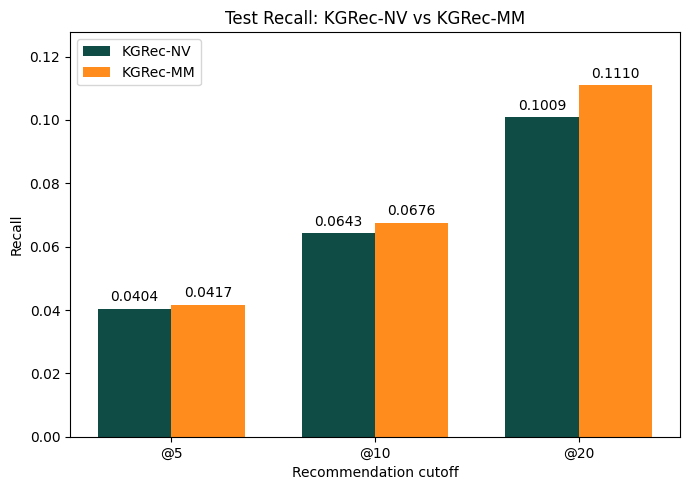

In [258]:
import matplotlib.pyplot as plt
import numpy as np


figure_dir = (
    final_model_dir
    /
    "figures"
)

figure_dir.mkdir(
    parents=True,
    exist_ok=True
)


ks = np.array(
    [5, 10, 20]
)


nv_recall = np.array([
    final_nv_test_metrics["Recall@5"],
    final_nv_test_metrics["Recall@10"],
    final_nv_test_metrics["Recall@20"]
])


mm_recall = np.array([
    final_mm_test_metrics["Recall@5"],
    final_mm_test_metrics["Recall@10"],
    final_mm_test_metrics["Recall@20"]
])


x = np.arange(
    len(ks)
)

width = 0.36


fig, ax = plt.subplots(
    figsize=(7, 5)
)


ax.bar(
    x - width / 2,
    nv_recall,
    width,
    label="KGRec-NV",
    color="#0F4C45"
)


ax.bar(
    x + width / 2,
    mm_recall,
    width,
    label="KGRec-MM",
    color="#FF8C1C"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        f"@{k}"
        for k in ks
    ]
)

ax.set_xlabel(
    "Recommendation cutoff"
)

ax.set_ylabel(
    "Recall"
)

ax.set_title(
    "Test Recall: KGRec-NV vs KGRec-MM"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

ax.margins(y=0.15)

ax.legend()

fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "test_recall_nv_vs_mm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

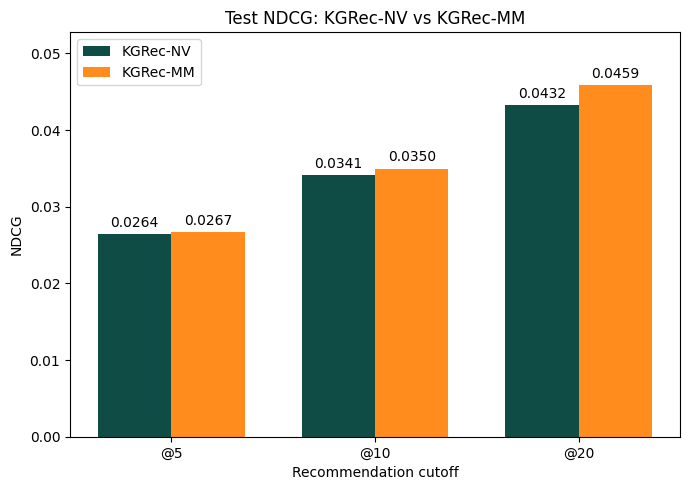

In [259]:
nv_ndcg = np.array([
    final_nv_test_metrics["NDCG@5"],
    final_nv_test_metrics["NDCG@10"],
    final_nv_test_metrics["NDCG@20"]
])


mm_ndcg = np.array([
    final_mm_test_metrics["NDCG@5"],
    final_mm_test_metrics["NDCG@10"],
    final_mm_test_metrics["NDCG@20"]
])


fig, ax = plt.subplots(
    figsize=(7, 5)
)


ax.bar(
    x - width / 2,
    nv_ndcg,
    width,
    label="KGRec-NV",
    color="#0F4C45"
)


ax.bar(
    x + width / 2,
    mm_ndcg,
    width,
    label="KGRec-MM",
    color="#FF8C1C"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        f"@{k}"
        for k in ks
    ]
)

ax.set_xlabel(
    "Recommendation cutoff"
)

ax.set_ylabel(
    "NDCG"
)

ax.set_title(
    "Test NDCG: KGRec-NV vs KGRec-MM"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

ax.margins(y=0.15)

ax.legend()

fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "test_ndcg_nv_vs_mm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

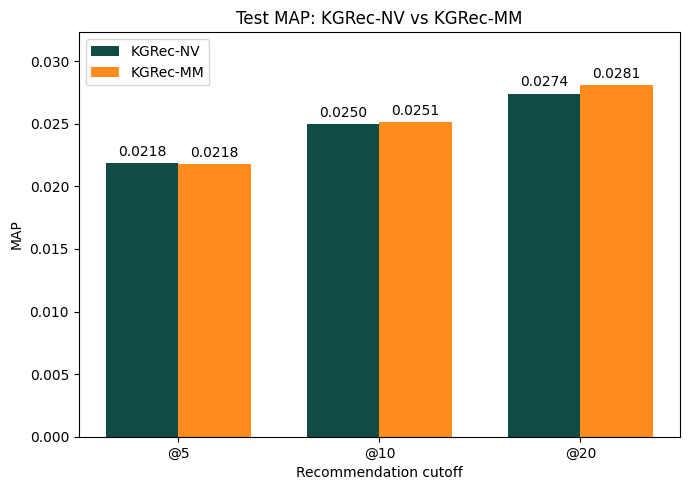

In [260]:
nv_map = np.array([
    final_nv_test_metrics["MAP@5"],
    final_nv_test_metrics["MAP@10"],
    final_nv_test_metrics["MAP@20"]
])


mm_map = np.array([
    final_mm_test_metrics["MAP@5"],
    final_mm_test_metrics["MAP@10"],
    final_mm_test_metrics["MAP@20"]
])


fig, ax = plt.subplots(
    figsize=(7, 5)
)


ax.bar(
    x - width / 2,
    nv_map,
    width,
    label="KGRec-NV",
    color="#0F4C45"
)


ax.bar(
    x + width / 2,
    mm_map,
    width,
    label="KGRec-MM",
    color="#FF8C1C"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    [
        f"@{k}"
        for k in ks
    ]
)

ax.set_xlabel(
    "Recommendation cutoff"
)

ax.set_ylabel(
    "MAP"
)

ax.set_title(
    "Test MAP: KGRec-NV vs KGRec-MM"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

ax.margins(y=0.15)

ax.legend()

fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "test_map_nv_vs_mm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Figure 2 — Paired MM−NV effects with 95% bootstrap intervals

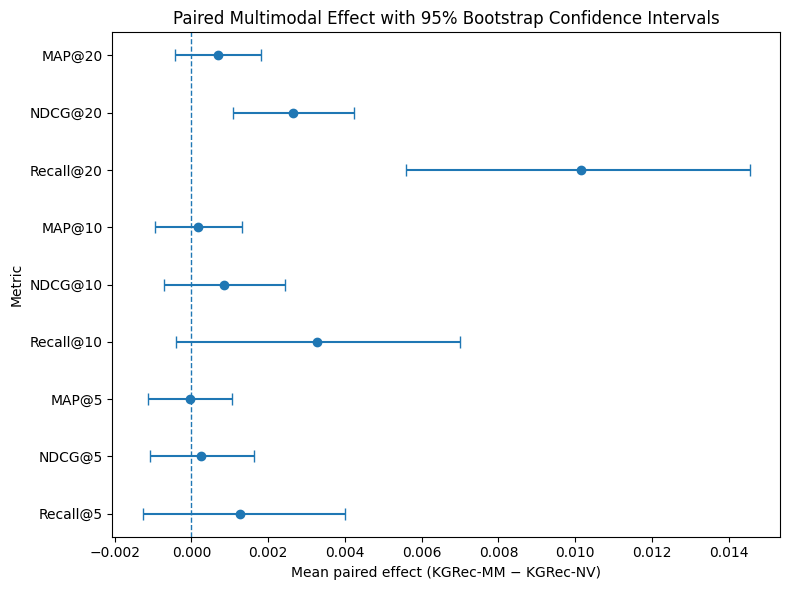

In [261]:
plot_bootstrap = (
    paired_bootstrap_summary
    .copy()
)


metric_order = [
    "Recall@5",
    "NDCG@5",
    "MAP@5",
    "Recall@10",
    "NDCG@10",
    "MAP@10",
    "Recall@20",
    "NDCG@20",
    "MAP@20"
]


plot_bootstrap[
    "metric"
] = pd.Categorical(
    plot_bootstrap[
        "metric"
    ],
    categories=metric_order,
    ordered=True
)


plot_bootstrap = (
    plot_bootstrap
    .sort_values(
        "metric"
    )
)


y = np.arange(
    len(
        plot_bootstrap
    )
)


effects = (
    plot_bootstrap[
        "MM_minus_NV"
    ]
    .to_numpy()
)


lower_errors = (
    effects
    -
    plot_bootstrap[
        "CI_95_lower"
    ].to_numpy()
)


upper_errors = (
    plot_bootstrap[
        "CI_95_upper"
    ].to_numpy()
    -
    effects
)


fig, ax = plt.subplots(
    figsize=(8, 6)
)


ax.errorbar(
    effects,
    y,
    xerr=[
        lower_errors,
        upper_errors
    ],
    fmt="o",
    capsize=4
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1
)


ax.set_yticks(
    y
)

ax.set_yticklabels(
    plot_bootstrap[
        "metric"
    ]
)


ax.set_xlabel(
    "Mean paired effect (KGRec-MM − KGRec-NV)"
)

ax.set_ylabel(
    "Metric"
)

ax.set_title(
    "Paired Multimodal Effect with 95% Bootstrap Confidence Intervals"
)


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "paired_mm_effect_bootstrap_ci.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Figure 3 — Frozen-MM visual ablation

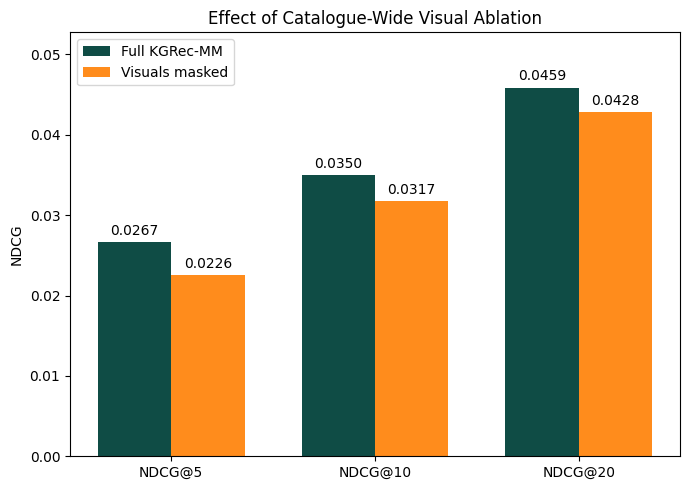

In [262]:
ablation_metrics = [
    "NDCG@5",
    "NDCG@10",
    "NDCG@20"
]


full_mm_values = (
    mm_visual_perturbation_metrics
    .loc[
        ablation_metrics,
        "Full MM"
    ]
    .to_numpy()
)


all_off_values = (
    mm_visual_perturbation_metrics
    .loc[
        ablation_metrics,
        "All visuals masked"
    ]
    .to_numpy()
)


x = np.arange(
    len(
        ablation_metrics
    )
)


fig, ax = plt.subplots(
    figsize=(7, 5)
)


ax.bar(
    x - width / 2,
    full_mm_values,
    width,
    label="Full KGRec-MM",
    color="#0F4C45"
)


ax.bar(
    x + width / 2,
    all_off_values,
    width,
    label="Visuals masked",
    color="#FF8C1C"
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    ablation_metrics
)


ax.set_ylabel(
    "NDCG"
)

ax.set_title(
    "Effect of Catalogue-Wide Visual Ablation"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

ax.margins(y=0.15)

ax.legend()


fig.tight_layout()


fig.savefig(
    figure_dir
    /
    "mm_visual_ablation_ndcg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()